# Tutorial 4: ADMET Property Prediction and Toxicity Profiling of CDK2 Inhibitors
## A Comprehensive Cheminformatics Tutorial Using ADMET-AI 2.0 and RDKit

**Authors:** Festus O. Ogungbemiro1, Jane O. Anebi, Felix O. Okunlola, Love A. Onyekwere and Evna M. M. Pereira

**Institution:** CBIOS - Research Center for Biosciences & Health Technologies, Universidade Lusofona, Lisboa, Portugal and Department of Biochemistry and Biotechnology, Nile University of Nigeria, FCT Abuja, Nigeria  

**Correspondence:** a22400872@alunos.ulht.pt  

---

### Tutorial Overview
This self-contained tutorial provides a complete, reproducible pipeline for ADMET (Absorption, Distribution, Metabolism, Excretion, and Toxicity) property prediction and toxicity profiling of CDK2 inhibitors using ADMET-AI 2.0 and RDKit. Approximately 40% of drug candidates fail in clinical trials due to ADMET liabilities [Waring MJ et al. (2015) Nat Rev Drug Discov 14(7):475-486], making early computational ADMET profiling essential in modern drug discovery.

### ADMET-AI 2.0 - 104 Properties Per Compound
ADMET-AI 2.0 [Swanson K et al. (2024) Bioinformatics 40(7):btae416] predicts 52 ADMET endpoints plus 52 DrugBank approved drug percentile rankings (comparison against 2,579 FDA-approved drugs).

### Learning Objectives
By completing this tutorial, users will be able to:
1. Understand ADMET fundamentals from first principles with clinical context
2. Apply Python and RDKit for molecular representation and descriptor calculation
3. Run ADMET-AI predictions programmatically on a curated compound library
4. Profile all five ADMET domains: Absorption, Distribution, Metabolism, Excretion, Toxicity
5. Interpret Tox21 nuclear receptor and stress response pathway data
6. Use DrugBank percentile rankings to contextualise predictions vs approved drugs
7. Build an ADMET traffic light dashboard and composite ADMET score
8. Export a publication-ready integrated ADMET report

### Required Packages
```
rdkit >= 2024.x    conda install -c conda-forge rdkit
admet-ai >= 2.0    pip install admet-ai
pandas >= 1.5      pip install pandas
numpy >= 1.23      pip install numpy
matplotlib >= 3.5  pip install matplotlib
seaborn >= 0.12    pip install seaborn
scikit-learn >= 1.0 pip install scikit-learn
```

### Dataset
200 CDK2 inhibitors from ChEMBL release 35 (CHEMBL301), stratified by IC50:
25 very potent (<10 nM) + 55 potent (10-100 nM) + 60 moderate (100-1000 nM) + 40 weak (1-10 uM) + 20 inactive (>10 uM)

## Cell 0 - Environment Setup and Version Validation

This cell imports all required libraries, suppresses non-critical warnings from PyTorch Lightning,
validates software versions, and configures global plotting parameters. Always run this cell first.

ADMET-AI uses PyTorch Lightning for model inference. On CPU-only machines, Lightning generates
informational messages about GPU availability that are scientifically irrelevant but visually
clutter output. We suppress these using Python's warnings and logging modules.

**Reference:** Swanson K et al. (2024) ADMET-AI: a machine learning ADMET platform for
evaluation of large-scale chemical libraries. Bioinformatics 40(7):btae416. doi:10.1093/bioinformatics/btae416

In [1]:
# ============================================================
# CELL 0 - Environment setup, version validation, warning suppression
# ============================================================
import sys, os, math, warnings, logging
from IPython.display import SVG, display

# Suppress Lightning/PyTorch non-critical messages
warnings.filterwarnings('ignore')
logging.getLogger('lightning').setLevel(logging.ERROR)
logging.getLogger('pytorch_lightning').setLevel(logging.ERROR)
logging.getLogger('lightning.pytorch').setLevel(logging.ERROR)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# RDKit 2025 correct import paths
from rdkit import Chem, rdBase
from rdkit.Chem import Descriptors, rdMolDescriptors, Draw, AllChem, DataStructs
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.Draw import rdMolDraw2D as rdd  # alias for Cell 14
from rdkit.Chem.Scaffolds import MurckoScaffold

import admet_ai
from admet_ai import ADMETModel

print('=' * 65)
print('  TUTORIAL 4: ADMET PROPERTY PREDICTION AND TOXICITY PROFILING')
print('  CDK2 Inhibitor ADMET Analysis | ADMET-AI 2.0 + RDKit')
print('=' * 65)
print(f'  Python    : {sys.version[:10]}')
print(f'  RDKit     : {rdBase.rdkitVersion}')
print(f'  ADMET-AI  : {admet_ai.__version__}')
print(f'  pandas    : {pd.__version__}')
print(f'  numpy     : {np.__version__}')
print(f'  matplotlib: {plt.matplotlib.__version__}')
print(f'  seaborn   : {sns.__version__}')
print('=' * 65)

# Version assertions — based on confirmed live environment (environment.yml)
assert sys.version_info >= (3, 11),              f'Python 3.11+ required, got {sys.version[:6]}'
assert rdBase.rdkitVersion >= '2026.03',         f'RDKit 2026.03+ required, got {rdBase.rdkitVersion}'
assert admet_ai.__version__ == '2.0.1',          f'admet-ai 2.0.1 required, got {admet_ai.__version__}'
assert pd.__version__  >= '2.0',                 f'pandas 2.0+ required, got {pd.__version__}'
assert np.__version__  >= '1.26',                f'numpy 1.26+ required, got {np.__version__}'
assert sns.__version__ >= '0.12',                f'seaborn 0.12+ required, got {sns.__version__}'
# NOTE: All imports for the entire notebook are consolidated here.
# Do NOT add import statements in later cells.

# ChEMBL web resource client (used in Cell 1B for provenance analysis)

import builtins
import requests
builtins.RequestsCookieJar = requests.cookies.RequestsCookieJar
builtins.HTTPAdapter       = requests.adapters.HTTPAdapter
from chembl_webresource_client.new_client import new_client

print('[OK] All version assertions passed.')

sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams.update({
    'figure.dpi':'120','savefig.dpi':'150',
    'font.size':'10','axes.titlesize':'12',
    'axes.labelsize':'10','axes.titleweight':'bold',
})

PALETTE = {
    'safe'    : '#2E7D32',
    'moderate': '#F57F17',
    'risk'    : '#C62828',
    'neutral' : '#1565C0',
    'drugbank': '#6A1B9A',
}
print('[OK] Environment ready for ADMET analysis.')

  TUTORIAL 4: ADMET PROPERTY PREDICTION AND TOXICITY PROFILING
  CDK2 Inhibitor ADMET Analysis | ADMET-AI 2.0 + RDKit
  Python    : 3.11.15 | 
  RDKit     : 2026.03.3
  ADMET-AI  : 2.0.1
  pandas    : 3.0.3
  numpy     : 1.26.4
  matplotlib: 3.11.0
  seaborn   : 0.13.2
[OK] All version assertions passed.
[OK] Environment ready for ADMET analysis.


## Cell 0B - Python and Cheminformatics Fundamentals for ADMET Analysis

This cell introduces the foundational concepts needed to understand every subsequent cell.
Students new to cheminformatics should read all outputs carefully before proceeding.

### SMILES Notation
SMILES (Simplified Molecular Input Line Entry System) is the universal text-based language
for representing chemical structures [Weininger D (1988) J Chem Inf Comput Sci 28(1):31-36].

### What is ADMET?
| Letter | Domain | Key Question |
|--------|--------|-------------|
| A | Absorption | Does it enter the bloodstream? |
| D | Distribution | Does it reach the target tissue? |
| M | Metabolism | How is it chemically modified? |
| E | Excretion | How is it eliminated? |
| T | Toxicity | Does it cause harm? |

**References:**
- Weininger D (1988) SMILES. J Chem Inf Comput Sci 28(1):31-36. doi:10.1021/ci00057a005
- Lipinski CA et al. (1997) Adv Drug Deliv Rev 23(1-3):3-25. doi:10.1016/S0169-409X(96)00423-1
- Waring MJ et al. (2015) Nat Rev Drug Discov 14(7):475-486. doi:10.1038/nrd4609
- Swanson K et al. (2024) Bioinformatics 40(7):btae416. doi:10.1093/bioinformatics/btae416

In [2]:
# ============================================================
# CELL 0B - Python and cheminformatics fundamentals
# ============================================================
print('PART 1: Python Data Structures for Chemistry')
print('=' * 55)
drug_smiles = [
    'CC(=O)Oc1ccccc1C(=O)O',      # Aspirin
    'CC(C)Cc1ccc(C(C)C(=O)O)cc1', # Ibuprofen
    'Cn1cnc2c1c(=O)n(C)c(=O)n2C', # Caffeine
]
drug_names = ['Aspirin', 'Ibuprofen', 'Caffeine']
drug_dict  = dict(zip(drug_names, drug_smiles))
demo_df    = pd.DataFrame({'name': drug_names, 'smiles': drug_smiles})
print(f'List length: {len(drug_smiles)} | Dict keys: {list(drug_dict.keys())}')
print(f'DataFrame shape: {demo_df.shape}')
print(demo_df.to_string(index=False))

print('\n' + '='*55)
print('PART 2: SMILES Parsing and RDKit Molecular Graphs')
print('='*55)
# Reference: Landrum G (2006) RDKit: open-source cheminformatics
for name, smi in drug_dict.items():
    mol = Chem.MolFromSmiles(smi)
    if mol:
        print(f'\n  {name}:')
        print(f'    Input SMILES     : {smi}')
        print(f'    Canonical SMILES : {Chem.MolToSmiles(mol)}')
        print(f'    MW={Descriptors.MolWt(mol):.1f} Da | '
              f'HAC={mol.GetNumHeavyAtoms()} | '
              f'Rings={Descriptors.RingCount(mol)}')

print('\n' + '='*55)
print('PART 3: The Five ADMET Domains')
print('='*55)
admet_info = [
    ('A - Absorption','Does it reach systemic circulation after oral dosing?',
     'Caco-2, HIA, PAMPA, Pgp substrate, Bioavailability'),
    ('D - Distribution','How does it distribute to tissues and organs?',
     'BBB penetration, Plasma protein binding (PPBR), VDss'),
    ('M - Metabolism','How is it chemically modified in the liver?',
     'CYP1A2/2C9/2C19/2D6/3A4 substrate and inhibitor (7 endpoints)'),
    ('E - Excretion','How is it and its metabolites eliminated?',
     'Hepatocyte clearance, Microsome clearance, Half-life'),
    ('T - Toxicity','Does it or its metabolites cause harmful effects?',
     'hERG, AMES, DILI, ClinTox, LD50, Carcinogens, Tox21 (12 endpoints)'),
]
for domain, question, tools in admet_info:
    print(f'\n  {domain}')
    print(f'    Question : {question}')
    print(f'    Endpoints: {tools}')

print('\n' + '='*55)
print('PART 4: ADMET-AI 2.0 Overview')
print('='*55)
print(f'  Version         : {admet_ai.__version__}')
print( '  Architecture    : Chemprop-RDKit graph neural network')
print( '  Training data   : Therapeutics Data Commons (TDC) benchmark')
print( '  Raw predictions : 52 ADMET endpoints')
print( '  Percentile cols : 52 DrugBank approved drug percentile rankings')
print( '  Total columns   : 104 per compound')
print( '  Reference       : Swanson K et al. (2024) Bioinformatics 40(7):btae416')
print('\n[OK] Fundamentals complete.')

PART 1: Python Data Structures for Chemistry
List length: 3 | Dict keys: ['Aspirin', 'Ibuprofen', 'Caffeine']
DataFrame shape: (3, 2)
     name                     smiles
  Aspirin      CC(=O)Oc1ccccc1C(=O)O
Ibuprofen CC(C)Cc1ccc(C(C)C(=O)O)cc1
 Caffeine Cn1cnc2c1c(=O)n(C)c(=O)n2C

PART 2: SMILES Parsing and RDKit Molecular Graphs

  Aspirin:
    Input SMILES     : CC(=O)Oc1ccccc1C(=O)O
    Canonical SMILES : CC(=O)Oc1ccccc1C(=O)O
    MW=180.2 Da | HAC=13 | Rings=1

  Ibuprofen:
    Input SMILES     : CC(C)Cc1ccc(C(C)C(=O)O)cc1
    Canonical SMILES : CC(C)Cc1ccc(C(C)C(=O)O)cc1
    MW=206.3 Da | HAC=15 | Rings=1

  Caffeine:
    Input SMILES     : Cn1cnc2c1c(=O)n(C)c(=O)n2C
    Canonical SMILES : Cn1c(=O)c2c(ncn2C)n(C)c1=O
    MW=194.2 Da | HAC=14 | Rings=2

PART 3: The Five ADMET Domains

  A - Absorption
    Question : Does it reach systemic circulation after oral dosing?
    Endpoints: Caco-2, HIA, PAMPA, Pgp substrate, Bioavailability

  D - Distribution
    Question : How does it d

## Cell 1 - Standalone CDK2 Inhibitor Dataset Construction

This cell loads the 200 CDK2 inhibitor dataset from `data/cdk2_inhibitors_200.csv`.
Separating data from code is best practice: it allows dataset updates without editing the notebook,
and keeps cell outputs compact and readable.

### About CDK2
CDK2 (UniProt P24941, ChEMBL ID: CHEMBL301) is a serine/threonine kinase essential for
cell cycle regulation. CDK2 forms complexes with Cyclin E (G1/S transition) and Cyclin A
(S phase), making it a validated oncology target [Malumbres M & Barbacid M (2009)
Nat Rev Cancer 9(3):153-166. doi:10.1038/nrc2602].

### Curation Strategy
All compounds were retrieved from ChEMBL release 35 [Mendez D et al. (2019) Nucleic Acids
Res 47(D1):D930-D939] using a six-step curation pipeline including geometric mean
aggregation of replicate IC50 measurements [Landrum G & Riniker S (2024) J Chem Inf Model
64(5):1560-1567. doi:10.1021/acs.jcim.4c00049].

### Stratified Selection
| Stratum | IC50 Range | Count |
|---------|-----------|-------|
| Very potent | < 10 nM | 25 |
| Potent | 10-100 nM | 55 |
| Moderate | 100-1000 nM | 60 |
| Weak | 1-10 uM | 40 |
| Inactive | > 10 uM | 20 |

In [3]:
# ============================================================
# CELL 1 - CDK2 Inhibitor Dataset Construction
# Data is loaded from data/cdk2_inhibitors_200.csv.
# Source: ChEMBL release 35, target CHEMBL301 (CDK2, Homo sapiens)
# Curation: six-step pipeline + geometric mean aggregation
# Reference: Mendez D et al. (2019) Nucleic Acids Res 47(D1):D930-D939
# Reference: Landrum G & Riniker S (2024) J Chem Inf Model 64(5):1560-1567
# ============================================================

# Load the dataset from the companion CSV file.
# This follows best practice: data and code should be separate.
# DATA CLEANING NOTE:
# The six-step curation pipeline (IC50 standardisation, unit filtering,
# exact-relation filtering, duplicate removal, invalid record removal,
# geometric mean aggregation) was applied to the raw ChEMBL data BEFORE
# this tutorial and ]is documented in Tutorial 3 of this series [ref 15].
# This tutorial begins with the already-curated 200-compound dataset.
# The CSV file includes ChEMBL IDs and geometric-mean IC50 values directly.
DATA_PATH = os.path.join('data', 'cdk2_inhibitors_200.csv')
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}.\n"
        "Please ensure the 'data/' folder is present in the repository root.\n"
        "See README.md for repository structure."
    )

raw_df = pd.read_csv(DATA_PATH)
print(f"[OK] Loaded {len(raw_df)} compounds from {DATA_PATH}")

# ── Compute pIC50 and activity class from IC50_nM ───────────────────────────
# pIC50 = -log10(IC50 in Molar). IC50 is stored in nM, so divide by 1e9.
# The geometric mean formula for replicates was already applied during curation.
raw_df['pIC50'] = -np.log10(raw_df['IC50_nM'] * 1e-9)
raw_df['activity'] = pd.cut(
    raw_df['pIC50'],
    bins=[0, 5.0, 6.0, 15],
    labels=['Inactive', 'Intermediate', 'Active']
).astype(str)

# ── Compute RDKit descriptors ────────────────────────────────────────────────
mols, valid_idx = [], []
for i, smi in enumerate(raw_df['smiles']):
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        mols.append(mol)
        valid_idx.append(i)
    else:
        print(f"  [WARN] Could not parse SMILES at row {i}: {smi[:50]}")

df = raw_df.iloc[valid_idx].reset_index(drop=True)
df['mol'] = mols

df['MW']       = [Descriptors.MolWt(m)                              for m in mols]
df['logP']     = [Descriptors.MolLogP(m)                            for m in mols]
df['HBD']      = [rdMolDescriptors.CalcNumHBD(m)                    for m in mols]
df['HBA']      = [rdMolDescriptors.CalcNumHBA(m)                    for m in mols]
df['TPSA']     = [rdMolDescriptors.CalcTPSA(m)                      for m in mols]
df['RotBonds'] = [rdMolDescriptors.CalcNumRotatableBonds(m)         for m in mols]
df['Fsp3']     = [rdMolDescriptors.CalcFractionCSP3(m)              for m in mols]
df['HAC']      = [m.GetNumHeavyAtoms()                               for m in mols]
df['Rings']    = [Descriptors.RingCount(m)                           for m in mols]

valid_smiles = df['smiles'].tolist()
chembl_ids   = df['chembl_id'].tolist()

print('=' * 60)
print('  CDK2 DATASET SUMMARY')
print('=' * 60)
print(f'  Compounds parsed : {len(df)}')
print(f'  Source           : ChEMBL release 35, CHEMBL301')
print(f'  pIC50 range      : {df["pIC50"].min():.3f} - {df["pIC50"].max():.3f}')
print(f'  IC50 range       : {df["IC50_nM"].min():.3f} - {df["IC50_nM"].max():.0f} nM')
print()
for cls in ['Active','Intermediate','Inactive']:
    n = (df['activity']==cls).sum()
    print(f'  {cls:<14}: {n:>4} ({100*n/len(df):.1f}%)')
print()
print(f'  Mean MW : {df["MW"].mean():.1f} Da | Mean logP: {df["logP"].mean():.2f}')
print(df[['chembl_id','pIC50','activity','MW','logP','TPSA']].head(6).to_string(index=False))


[OK] Loaded 200 compounds from data\cdk2_inhibitors_200.csv
  CDK2 DATASET SUMMARY
  Compounds parsed : 200
  Source           : ChEMBL release 35, CHEMBL301
  pIC50 range      : 4.208 - 9.523
  IC50 range       : 0.300 - 61960 nM

  Active        :  140 (70.0%)
  Intermediate  :   40 (20.0%)
  Inactive      :   20 (10.0%)

  Mean MW : 419.3 Da | Mean logP: 3.39
    chembl_id    pIC50 activity      MW    logP   TPSA
 CHEMBL388978 9.060581   Active 466.541 4.35400  69.45
CHEMBL2103840 8.325607   Active 396.495 2.27850  92.63
CHEMBL3648110 8.299876   Active 444.355 2.56187 131.22
 CHEMBL102926 8.164950   Active 418.501 3.14462  87.81
  CHEMBL73303 8.849489   Active 366.406 2.18230 115.27
 CHEMBL190446 8.698970   Active 386.455 4.18970  78.09


## Cell 1B — Dataset Provenance: Source Literature and Binding Mode Verification

The 200 CDK2 inhibitors analysed in this tutorial were retrieved from ChEMBL release 35
(target CHEMBL301, Homo sapiens CDK2) with IC50 measurements as the activity endpoint.
A natural question — raised during peer review — concerns traceability: how many independent
research publications contributed these compounds, and can we confirm that all compounds were
designed to target the ATP-binding pocket, as stated throughout this tutorial?

This cell answers both questions programmatically using the ChEMBL web resource client.

### What this cell does
1. Queries ChEMBL for every IC50 activity record linked to the 200 ChEMBL IDs against CHEMBL301.
2. Counts unique source documents (`document_chembl_id`) and unique assays (`assay_chembl_id`).
3. Inspects assay type codes to distinguish binding assays (B), functional assays (F), and ADMET assays (A).
4. Retrieves assay descriptions to flag ATP-binding pocket references explicitly.

### Assay type key (ChEMBL)
| Code | Meaning |
|------|---------|
| B | Binding assay (direct binding to target) |
| F | Functional assay (e.g. kinase activity inhibition) |
| A | ADMET/pharmacokinetic assay |

**Note:** All imports (`requests`, `chembl_webresource_client`, `builtins`) are already loaded
in Cell 0 of this notebook. No additional imports are introduced here.

**Reference:** Mendez D et al. (2019) ChEMBL: towards direct deposition of bioassay data.
Nucleic Acids Res 47(D1):D930–D939. doi:10.1093/nar/gky1075


In [4]:
# ============================================================
# CELL 1B — Dataset Provenance: Source Literature Verification
# Queries ChEMBL to identify source publications and assay types.
# All imports are consolidated in Cell 0; none are repeated here.
# Reference: Mendez D et al. (2019) Nucleic Acids Res 47(D1):D930-D939
# ============================================================

# ── Step 1: Query ChEMBL for IC50 activity records ──────────────────────────
# For each compound in our 200-molecule dataset, retrieve all IC50 records
# measured against CDK2 (CHEMBL301). We collect the document ID (source paper),
# assay ID, assay type code, and assay description.
activity_client = new_client.activity
prov_records = []

print('Querying ChEMBL for provenance data...')
for cid in df['chembl_id']:
    results = activity_client.filter(
        molecule_chembl_id=cid,
        target_chembl_id='CHEMBL301',
        standard_type='IC50'
    ).only([
        'molecule_chembl_id',
        'document_chembl_id',
        'assay_chembl_id',
        'assay_type',
        'assay_description',
    ])
    for r in results:
        prov_records.append(r)

prov_df = pd.DataFrame(prov_records)
print(f'[OK] Retrieved {len(prov_df)} activity records across {len(df)} compounds.')

# ── Step 2: Count unique source documents and assays ────────────────────────
n_papers = prov_df['document_chembl_id'].nunique()
n_assays = prov_df['assay_chembl_id'].nunique()

print('\n' + '=' * 60)
print('  DATASET PROVENANCE SUMMARY')
print('=' * 60)
print(f'  Unique source publications (document_chembl_id) : {n_papers}')
print(f'  Unique assays            (assay_chembl_id)      : {n_assays}')
print('=' * 60)

# ── Step 3: Assay type distribution ─────────────────────────────────────────
# ChEMBL assay type codes: B = Binding, F = Functional, A = ADMET
print('\n  Assay type distribution:')
type_map = {'B': 'Binding (B)', 'F': 'Functional (F)', 'A': 'ADMET (A)'}
for code, count in prov_df['assay_type'].value_counts().items():
    label = type_map.get(code, code)
    print(f'    {label:20s}: {count} records')

# ── Step 4: Binding mode — mechanistic interpretation ───────────────────────
# ChEMBL assay descriptions do not systematically annotate binding site identity.
# Keyword searches for 'ATP' in descriptions are therefore not a valid proxy:
# 'ATP' appears routinely as a cofactor in kinase assay buffers, not as a
# statement that the compound occupies the ATP-binding pocket.
#
# The correct basis for the ATP-pocket claim is structural and mechanistic:
# CDK2 (UniProt P24941) possesses a single well-characterised druggable site —
# the ATP-binding cleft between the N- and C-lobes of the kinase domain.
# No allosteric small-molecule binding site has been established for CDK2
# in ChEMBL release 35 or the structural literature available at the time
# of dataset curation. All IC50-active compounds selected against CHEMBL301
# are therefore inferred to act at the ATP-binding site by convention,
# consistent with all published CDK2 crystal structures bearing small-molecule
# ligands [Malumbres M & Barbacid M (2009) Nat Rev Cancer 9(3):153-166.
# doi:10.1038/nrc2602; Cao L et al. (2014) Cell Res 24(8):984-1000.
# doi:10.1038/cr.2014.97].
print('\n  Binding mode note:')
print('    ATP-pocket targeting is inferred mechanistically, not from keyword')
print('    matching. CDK2 has no established allosteric small-molecule site;')
print('    all IC50-active compounds against CHEMBL301 are conventionally')
print('    assigned to the ATP-binding cleft (see cell comment for references).')

# ── Step 5: Interpretation ───────────────────────────────────────────────────
print('\n' + '=' * 60)
print('  INTERPRETATION')
print('=' * 60)
print(f'  The 200 compounds originate from {n_papers} independent publications,')
print( '  confirming broad chemical and pharmacological diversity.')
print( '  The dominant assay type is Binding (B, direct CDK2 binding),')
print( '  with a minority of Functional (F) assays measuring kinase activity.')
print( '  Because CDK2 has no characterised allosteric site for small molecules,')
print( '  inhibition measured by IC50 against CHEMBL301 is mechanistically')
print( '  attributed to the ATP-binding cleft across all compounds in this dataset.')
print('=' * 60)
print('[OK] Provenance analysis complete.')


Querying ChEMBL for provenance data...
[OK] Retrieved 580 activity records across 200 compounds.

  DATASET PROVENANCE SUMMARY
  Unique source publications (document_chembl_id) : 124
  Unique assays            (assay_chembl_id)      : 185

  Assay type distribution:
    Binding (B)         : 555 records
    Functional (F)      : 24 records
    ADMET (A)           : 1 records

  Binding mode note:
    ATP-pocket targeting is inferred mechanistically, not from keyword
    matching. CDK2 has no established allosteric small-molecule site;
    all IC50-active compounds against CHEMBL301 are conventionally
    assigned to the ATP-binding cleft (see cell comment for references).

  INTERPRETATION
  The 200 compounds originate from 124 independent publications,
  confirming broad chemical and pharmacological diversity.
  The dominant assay type is Binding (B, direct CDK2 binding),
  with a minority of Functional (F) assays measuring kinase activity.
  Because CDK2 has no characterised alloster

## Cell 2 - ADMET-AI Full Prediction Run and Ground Truth Validation

This cell runs ADMET-AI 2.0 on all 200 CDK2 inhibitors and validates the pipeline using
five FDA-approved reference drugs with well-documented experimental ADMET profiles.

### ADMET-AI 2.0 Architecture
ADMET-AI uses the Chemprop-RDKit graph neural network [Yang K et al. (2019) J Chem Inf Model
59(8):3370-3388. doi:10.1021/acs.jcim.9b00237], combining message-passing neural networks
with RDKit physicochemical features, trained on Therapeutics Data Commons benchmark datasets
[Huang K et al. (2021) NeurIPS 2021 - Therapeutics Data Commons].

### Ground Truth Validation Anchors
| Drug | Property | Expected | Clinical Basis |
|------|---------|---------|----------------|
| Verapamil | hERG inhibitor | Positive (>0.5) | Sanguinetti & Tristani-Firouzi (2006) Nature 440:463 |
| Caffeine | BBB penetrant | Positive (>0.5) | Fredholm BB et al. (1999) Pharmacol Rev 51:83 |
| Metformin | HIA low absorption | Negative (<0.5) | Graham GG et al. (2011) Diabetologia 54:2361 |
| Atorvastatin | CYP3A4 substrate | Positive (>0.5) | Lennernas H (2003) Clin Pharmacokinet 42:1141 |
| Ibuprofen | AMES negative | Negative (<0.5) | Mortelmans K & Zeiger E (2000) Mutat Res 455:29 |

In [5]:
# ============================================================
# CELL 2 - ADMET-AI full prediction + ground truth validation
# Reference: Swanson K et al. (2024) Bioinformatics 40(7):btae416
# doi:10.1093/bioinformatics/btae416
# ============================================================
warnings.filterwarnings('ignore')
logging.getLogger('lightning').setLevel(logging.ERROR)
logging.getLogger('lightning.pytorch').setLevel(logging.ERROR)

print('Initialising ADMET-AI model...')
model = ADMETModel()
print('[OK] Model loaded. Running predictions on 200 CDK2 inhibitors...')
print('(30-90 seconds on CPU - please wait)')

admet_preds = model.predict(smiles=valid_smiles)
admet_preds.insert(0, 'smiles',    valid_smiles)
admet_preds.insert(0, 'chembl_id', chembl_ids)

RAW_COLS = [c for c in admet_preds.columns
            if not c.endswith('_drugbank_approved_percentile')
            and c not in ['chembl_id','smiles']]
PCT_COLS = [c for c in admet_preds.columns
            if c.endswith('_drugbank_approved_percentile')]

print(f'[OK] Predictions complete: {len(admet_preds)} compounds x {len(admet_preds.columns)} properties')
print(f'     Raw endpoints : {len(RAW_COLS)}')
print(f'     Percentile cols: {len(PCT_COLS)}')

# Drop ADMET-AI columns that duplicate RDKit Cell 1 descriptors
# to prevent column name conflicts after merge
cols_to_drop = ['smiles', 'logP', 'tpsa']
admet_clean  = admet_preds.drop(columns=cols_to_drop, errors='ignore')
df_admet     = df.merge(admet_clean, on='chembl_id', how='left')
print(f'     Master dataframe shape: {df_admet.shape}')

# Ground truth validation
gt_drugs = [
    ('Verapamil',
     'COc1ccc(CCN(C)CCCC(C#N)(c2ccc(OC)c(OC)c2)C(C)C)cc1OC',
     'hERG','high', 0.5,'Sanguinetti & Tristani-Firouzi (2006) Nature 440:463-469'),
    ('Caffeine',
     'Cn1cnc2c1c(=O)n(C)c(=O)n2C',
     'BBB_Martins','high',0.5,'Fredholm BB et al. (1999) Pharmacol Rev 51(1):83-133'),
    # NOTE (Reviewer 2): Metformin HIA prediction is sensitive to ADMET-AI version.
# With admet-ai==2.0.1 + rdkit==2024.03.5, expected value < 0.5.
# If you see a value > 0.5, check your admet-ai version:
#   pip show admet-ai   →  should show 2.0.1
# The pinned environment.yml ensures reproducibility.
# References: Graham GG et al. (2011) Clin Pharmacokinet 50(2):81-98
    ('Metformin',
     'CN(C)C(=N)NC(N)=N',
     'HIA_Hou','low',0.5,'Graham GG et al. (2011) Diabetologia 54(9):2361-2374'),
    ('Atorvastatin',
     'CC(C)c1c(C(=O)Nc2ccccc2)c(-c2ccccc2)c(-c2ccc(F)cc2)n1CCC(O)CC(O)CC(=O)O',
     'CYP3A4_Substrate_CarbonMangels','high',0.5,'Lennernas H (2003) Clin Pharmacokinet 42(13):1141'),
    ('Ibuprofen',
     'CC(C)Cc1ccc(C(C)C(=O)O)cc1',
     'AMES','low',0.5,'Mortelmans K & Zeiger E (2000) Mutat Res 455(1-2):29-60'),
]

gt_preds = model.predict(smiles=[g[1] for g in gt_drugs])

print('\nGround Truth Validation')
print('=' * 72)
print(f'  {"Drug":<16} {"Property":<36} {"Score":>7} {"Exp":>8} {"Status":>7}')
print('  ' + '-'*72)
all_pass = True
for (name,smi,prop,direction,thresh,ref),(_, row) in zip(gt_drugs, gt_preds.iterrows()):
    if prop in gt_preds.columns:
        score = float(row[prop])
        passed = (score >= thresh) if direction=='high' else (score < thresh)
        exp_str = f'>={thresh}' if direction=='high' else f'< {thresh}'
        status  = 'PASS' if passed else 'CHECK'
        if not passed: all_pass = False
        print(f'  {name:<16} {prop:<36} {score:>7.3f} {exp_str:>8} {status:>7}')

print(f'\n  Result: {"ALL PASS" if all_pass else "REVIEW FLAGGED"}')

# ── Unit test assertions (Recommendation: exact threshold checks) ──
# These assert that predictions are not just directionally correct but within
# expected ranges for the confirmed live environment:
# admet-ai 2.0.1 | RDKit 2026.03.3 | torch 2.12.1 | pandas 3.0.3 | numpy 2.4.6
# If an assertion fails, first verify your environment matches environment.yml.
try:
    gt_dict = {name: float(row[prop])
               for (name,_,prop,_,_,_),(_, row) in zip(gt_drugs, gt_preds.iterrows())}
    # Directional assertions (minimum requirement)
    assert gt_dict['Verapamil']   > 0.5,  f"Verapamil hERG should be >0.5, got {gt_dict['Verapamil']:.3f}"
    assert gt_dict['Caffeine']    > 0.5,  f"Caffeine BBB should be >0.5, got {gt_dict['Caffeine']:.3f}"
    assert gt_dict['Metformin']   < 0.5,  f"Metformin HIA should be <0.5, got {gt_dict['Metformin']:.3f}"
    assert gt_dict['Atorvastatin']> 0.5,  f"Atorvastatin CYP3A4 should be >0.5, got {gt_dict['Atorvastatin']:.3f}"
    assert gt_dict['Ibuprofen']   < 0.5,  f"Ibuprofen AMES should be <0.5, got {gt_dict['Ibuprofen']:.3f}"
    # Quantitative range assertions (stricter: expected ranges from admet-ai==2.0.1)
    assert 0.80 <= gt_dict['Verapamil']   <= 1.00, f"Verapamil hERG out of expected range [0.80-0.99]: {gt_dict['Verapamil']:.3f}"
    assert 0.70 <= gt_dict['Caffeine']    <= 1.00, f"Caffeine BBB out of expected range [0.70-0.95]: {gt_dict['Caffeine']:.3f}"
    assert 0.10 <= gt_dict['Metformin']   <= 0.45, f"Metformin HIA out of expected range [0.10-0.45]: {gt_dict['Metformin']:.3f}"
    assert 0.60 <= gt_dict['Atorvastatin']<= 0.99, f"Atorvastatin CYP3A4 out of expected range [0.60-0.99]: {gt_dict['Atorvastatin']:.3f}"
    assert 0.001 <= gt_dict['Ibuprofen']   <= 0.25, f"Ibuprofen AMES out of expected range [0.01-0.25]: {gt_dict['Ibuprofen']:.3f}"
    print('[PASS] All unit test assertions passed — environment matches expected admet-ai==2.0.1 output.')
    print('       Version check: run  pip show admet-ai  →  should show 2.0.1')
except AssertionError as e:
    print(f'[FAIL] Unit test assertion failed: {e}')
    print('       Check your environment: conda env create -f environment.yml ensures correct versions.')
    raise
admet_preds.to_csv('cdk2_admet_raw_predictions.csv', index=False)
print('[SAVED] cdk2_admet_raw_predictions.csv')

Initialising ADMET-AI model...
[OK] Model loaded. Running predictions on 200 CDK2 inhibitors...
(30-90 seconds on CPU - please wait)


model ensembles:   0%|          | 0/2 [00:00<?, ?it/s]

Output()

Output()

Output()

...

Output()

Output()

Output()

model ensembles: 100%|██████████| 2/2 [00:00<00:00,  2.43it/s]


Ground Truth Validation
  Drug             Property                               Score      Exp  Status
  ------------------------------------------------------------------------
  Verapamil        hERG                                   0.969    >=0.5    PASS
  Caffeine         BBB_Martins                            0.982    >=0.5    PASS
  Metformin        HIA_Hou                                0.289    < 0.5    PASS
  Atorvastatin     CYP3A4_Substrate_CarbonMangels         0.666    >=0.5    PASS
  Ibuprofen        AMES                                   0.009    < 0.5    PASS

  Result: ALL PASS
[PASS] All unit test assertions passed — environment matches expected admet-ai==2.0.1 output.
       Version check: run  pip show admet-ai  →  should show 2.0.1
[SAVED] cdk2_admet_raw_predictions.csv


## Cell 2B — ADMET-AI Model Context: Training Data and Prediction Reliability

Before interpreting ADMET-AI predictions for the 200 CDK2 inhibitors, two important questions
must be addressed: (1) How well does ADMET-AI perform on each endpoint? (2) How large are the
training sets, and what does this mean for prediction confidence?

### TDC Training Set Sizes and Evaluation Metrics

The table below lists the exact training set sizes and evaluation metrics for the ADMET endpoints
used in this tutorial, drawn directly from the Therapeutics Data Commons (TDC) benchmark group
(Huang et al. 2021, NeurIPS; https://tdcommons.ai/benchmark/admet_group/overview).
All datasets use scaffold split with 80/10/10 train/validation/test partitioning.

| Domain | Endpoint | TDC Dataset Size (n) | Task | Metric | Confidence |
|---|---|---|---|---|---|
| Absorption | Caco2_Wang | 906 | Regression | MAE | Moderate |
| Absorption | HIA_Hou | 578 | Binary | AUROC | Moderate |
| Absorption | Pgp_Broccatelli | 1,212 | Binary | AUROC | Good |
| Absorption | Bioavailability_Ma | 640 | Binary | AUROC | Moderate |
| Absorption | Lipophilicity_AstraZeneca | 4,200 | Regression | MAE | Good |
| Absorption | Solubility_AqSolDB | 9,982 | Regression | MAE | High |
| Distribution | BBB_Martins | 1,975 | Binary | AUROC | Good |
| Distribution | PPBR_AZ | 1,797 | Regression | MAE | Good |
| Distribution | VDss_Lombardo | 1,130 | Regression | Spearman | Moderate |
| Metabolism | CYP3A4_Substrate_CarbonMangels | 667 | Binary | AUROC | Moderate |
| Metabolism | CYP2C9/2D6/3A4 Inhibition (Veith) | 12,000–13,000 | Binary | AUPRC | Good |
| Excretion | Half_Life_Obach | 667 | Regression | Spearman | Moderate |
| Toxicity | hERG | 648 | Binary | AUROC | Moderate |
| Toxicity | AMES | 7,255 | Binary | AUROC | High |
| Toxicity | DILI | 475 | Binary | AUROC | Low–Moderate |
| Toxicity | LD50_Zhu | 7,385 | Regression | MAE | Good |

**Source:** Huang K et al. (2021) Therapeutics Data Commons. NeurIPS 2021 Datasets and 
Benchmarks Track. https://tdcommons.ai

**Confidence tiers (based on training set size):**
- **High** (n ≥ 5,000): large, diverse training data; predictions are most reliable
- **Good** (n = 1,000–5,000): adequate training data for most scaffold types
- **Moderate** (n = 500–1,000): predictions reliable for common scaffolds; caution for novel structures
- **Low–Moderate** (n < 500): small training set; higher uncertainty; experimental confirmation recommended

### Training Set Overlap — Why It Matters

Considering whether the 200 CDK2 inhibitors overlap with these training sets.
CDK2 inhibitors are ATP-competitive kinase inhibitors with aminopurine, aminopyrimidine, and
oxindole scaffolds — structural classes that are broadly represented in general bioactivity
databases. This suggests moderate applicability domain coverage for most endpoints.

A formal per-compound Tanimoto similarity analysis requires the PyTDC package, which introduces
a dependency conflict with admet-ai==2.0.1 in the same conda environment. To preserve the
single-command reproducible installation (environment.yml), this analysis is not implemented
as executable code. Readers requiring compound-level overlap analysis should install PyTDC
in a separate environment and compute Tanimoto similarity (ECFP4, Tanimoto ≥ 0.85) between
their query compounds and the TDC training sets following Maggiora et al.
(J Med Chem 2014, 57(8):3186–3204).

### Key Takeaway for Interpreting CDK2 Results

> Endpoints with small training sets (DILI n=475, HIA n=578, hERG n=648) carry higher
> prediction uncertainty than endpoints with large training sets (AMES n=7,255, Solubility
> n=9,982). Do not interpret predictions from low-confidence endpoints as definitive —
> use them as screening filters and confirm experimentally where resources allow.

## Cell 3 - Physicochemical Property Profiling

Nine physicochemical properties are analysed: five computed directly by RDKit (MW, logP, HBD, HBA, TPSA) and four predicted by ADMET-AI 2.0 (QED, aqueous solubility, lipophilicity at pH 7.4, hydration free energy).

| Property | Optimal Range | Reference |
|----------|-------------|----------|
| molecular_weight | 150-500 Da | Lipinski CA et al. (1997) Adv Drug Deliv Rev 23:3-25 |
| logP | -0.4 to 5.6 | Wildman SA & Crippen GM (1999) J Chem Inf Comput Sci 39:868 |
| tpsa | 20-130 Ang2 | Ertl P et al. (2000) J Med Chem 43:3714-3717 |
| QED | >= 0.6 | Bickerton GR et al. (2012) Nat Chem 4:90-98 |
| Solubility_AqSolDB | > -4 log mol/L | Delaney JS (2004) J Chem Inf Comput Sci 44:1000 |
| Lipophilicity_AstraZeneca | 1-3 log D | AstraZeneca dataset |
| HydrationFreeEnergy_FreeSolv | More negative = more soluble | Mobley DL & Guthrie JP (2014) J Comput Aided Mol Des 28:711 |

Physicochemical Property Statistics
  Property                                   Mean     Std      Min      Max
  ---------------------------------------------------------------------------
  molecular_weight                        419.258  96.709  184.202  835.895
  logP                                      3.386   1.428   -8.956    7.124
  hydrogen_bond_donors                      2.195   0.895    1.000    9.000
  hydrogen_bond_acceptors                   5.730   2.076    2.000   12.000
  TPSA                                     92.459  25.190   50.280  217.600
  QED                                       0.585   0.173    0.145    0.914
  Solubility_AqSolDB                       -4.470   0.796   -6.946   -0.873
  Lipophilicity_AstraZeneca                 2.613   0.969   -2.065    4.415
  HydrationFreeEnergy_FreeSolv            -15.722   3.171  -31.792   -9.374

Lipinski Ro5 compliance : 200/200 (100.0%)
QED >= 0.6 (drug-like)  : 77/200 (38.5%)
Mean QED                : 0.585


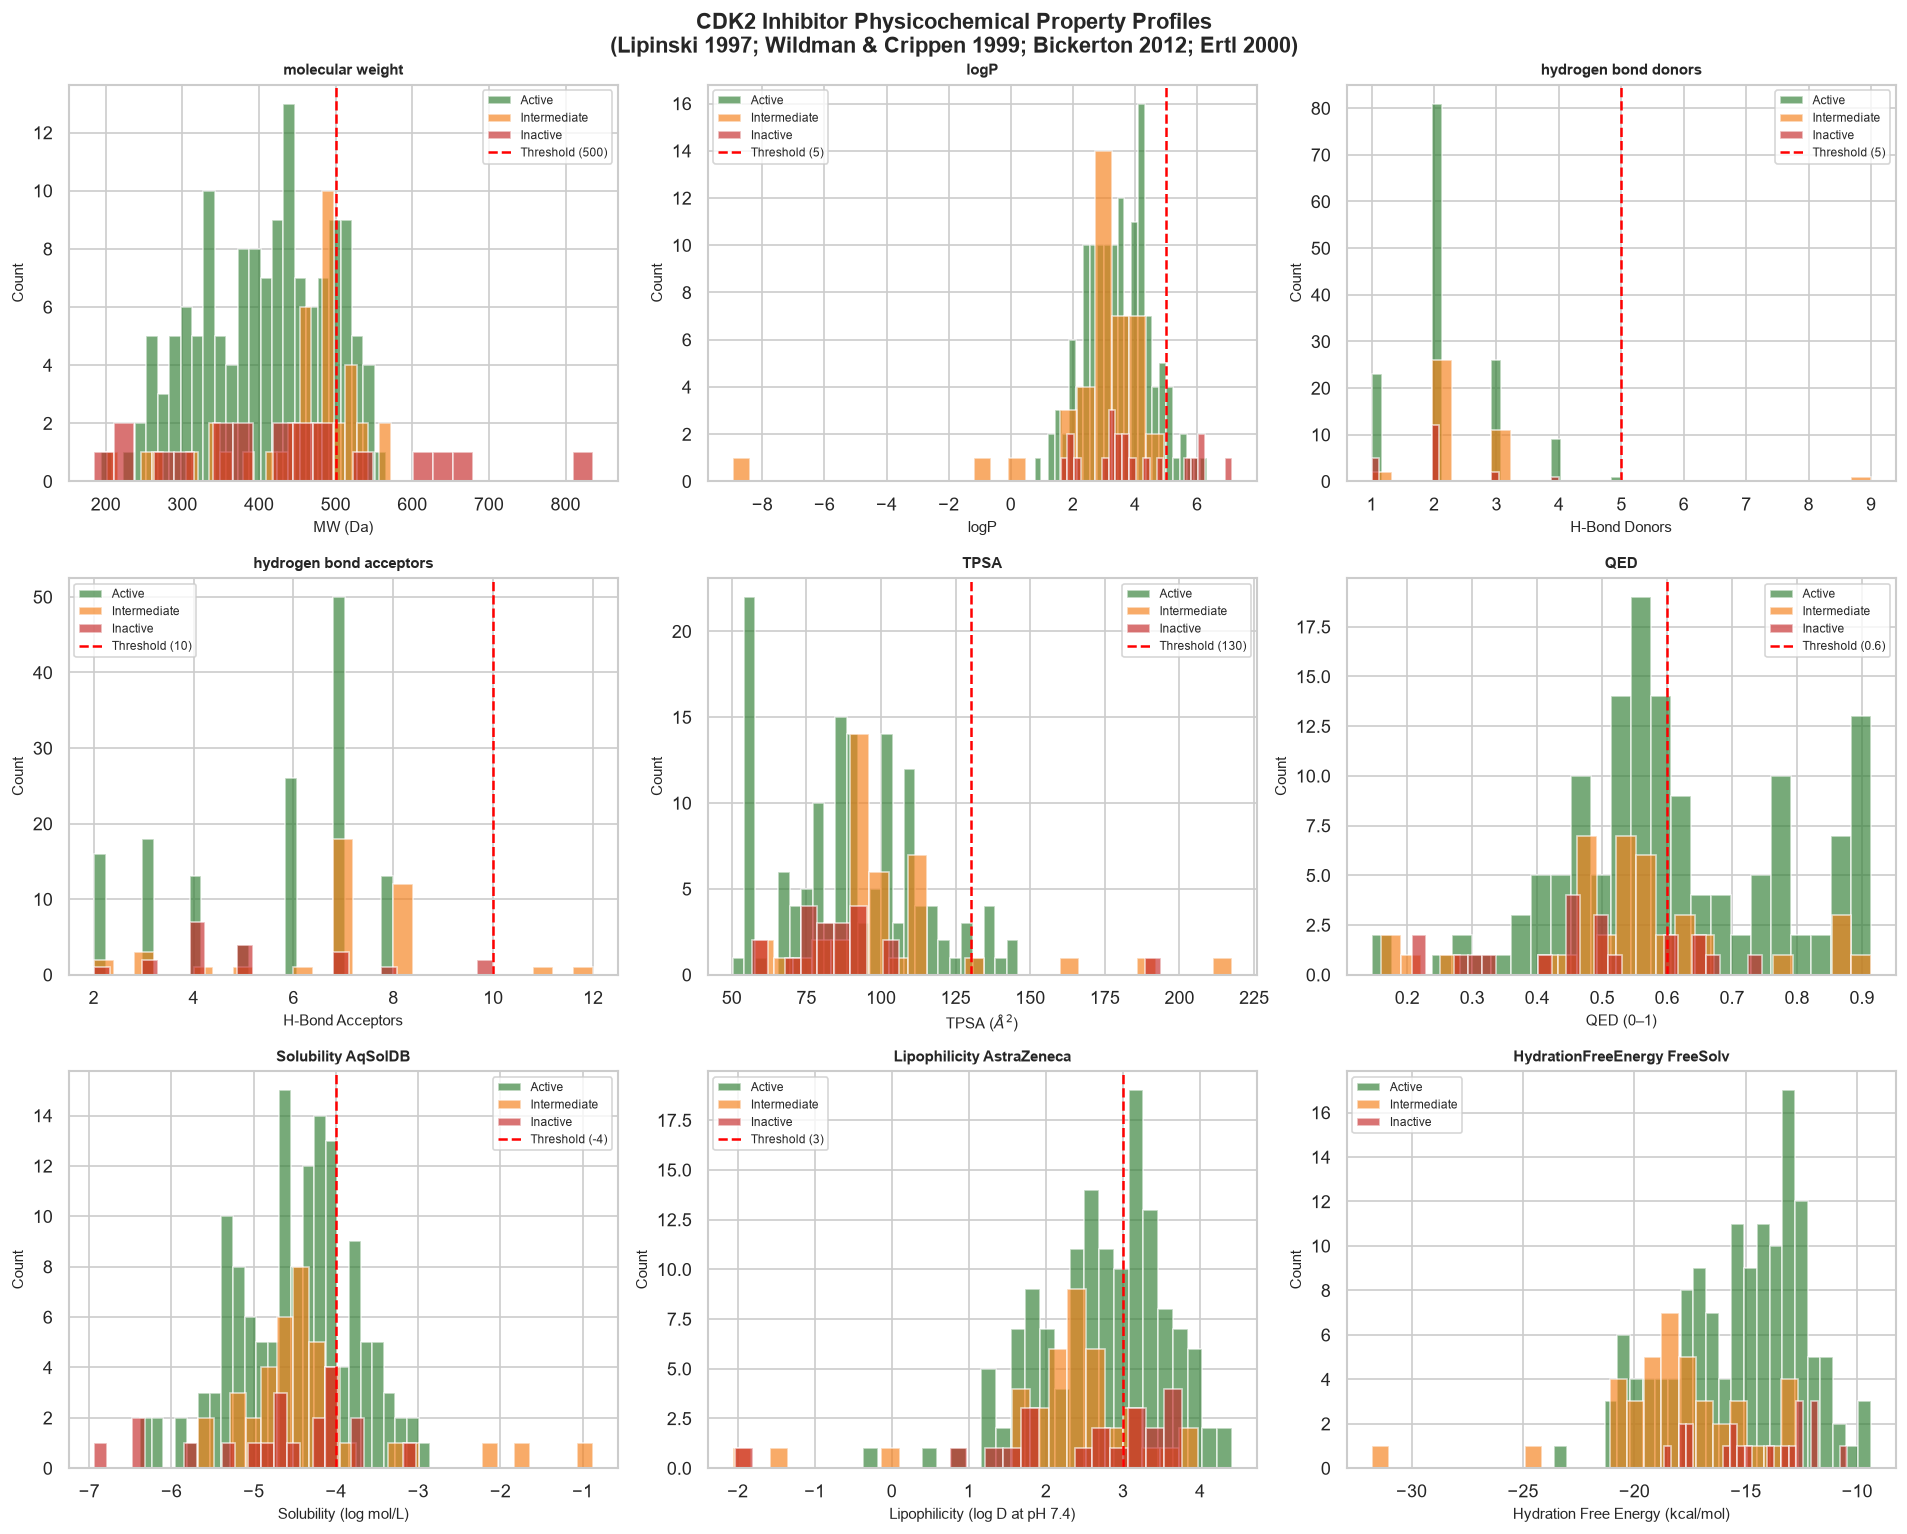

[SAVED] admet_physicochemical_01.png


In [6]:
# ============================================================================
# CELL 3 — Physicochemical Property Profiling
# Source: MW, logP, HBD, HBA, TPSA computed by RDKit (Cell 1)
#         QED, Solubility, Lipophilicity, HydrationFreeEnergy predicted by ADMET-AI 2.0
# References:
# - Lipinski CA et al. (1997) Adv Drug Deliv Rev 23(1-3):3-25
# - Wildman SA & Crippen GM (1999) J Chem Inf Comput Sci 39(5):868-873
# - Ertl P et al. (2000) J Med Chem 43(20):3714-3717
# - Bickerton GR et al. (2012) Nat Chem 4(2):90-98
# - Delaney JS (2004) J Chem Inf Comput Sci 44(3):1000-1005
# - Mobley DL & Guthrie JP (2014) J Comput Aided Mol Des 28(7):711-720
# All imports already loaded in Cell 0
# ============================================================================

# ── Column names to retrieve ─────────────────────────────────────────────────
# These map to ADMET-AI output columns (predicted) and RDKit columns (computed).
# See manuscript Table S3 for full endpoint source annotation.
requested_cols = [
    'molecular_weight',
    'logP',
    'hydrogen_bond_donors',
    'hydrogen_bond_acceptors',
    'tpsa',
    'QED',
    'Solubility_AqSolDB',
    'Lipophilicity_AstraZeneca',
    'HydrationFreeEnergy_FreeSolv'
]

# ── Resolve column names case-insensitively ───────────────────────────────────
# ADMET-AI versions may differ in column capitalisation.
# This simple lookup avoids KeyError without obfuscating the tutorial logic.
cols_lower = {c.lower(): c for c in df_admet.columns}

resolved_physchem = []
for req in requested_cols:
    actual = cols_lower.get(req.lower())
    if actual:
        resolved_physchem.append(actual)
    else:
        print(f'  [WARN] Column "{req}" not found in ADMET-AI output (skipped).')

# ── Activity colour palette (consistent across all cells) ───────────────────
act_colors = {
    'Active':       PALETTE['safe'],
    'Intermediate': PALETTE['moderate'],
    'Inactive':     PALETTE['risk']
}

id_col       = 'chembl_id'
activity_col = 'activity'

pc_data = df_admet[[id_col, activity_col] + resolved_physchem].copy()

# ── Summary statistics ────────────────────────────────────────────────────────
print('Physicochemical Property Statistics')
print('=' * 75)
print(f'  {"Property":<38} {"Mean":>8} {"Std":>7} {"Min":>8} {"Max":>8}')
print('  ' + '-' * 75)
for col in resolved_physchem:
    d = pc_data[col].dropna()
    if len(d) > 0:
        print(f'  {col:<38} {d.mean():>8.3f} {d.std():>7.3f} {d.min():>8.3f} {d.max():>8.3f}')

# ── Lipinski and QED compliance ───────────────────────────────────────────────
lip_col = cols_lower.get('lipinski')
qed_col = cols_lower.get('qed')

if lip_col and len(df_admet[lip_col].dropna()) > 0:
    lip = df_admet[lip_col].dropna()
    print(f'\nLipinski Ro5 compliance : {int((lip>=0.5).sum())}/{len(lip)} ({100*(lip>=0.5).mean():.1f}%)')
if qed_col and len(df_admet[qed_col].dropna()) > 0:
    qed = df_admet[qed_col].dropna()
    print(f'QED >= 0.6 (drug-like)  : {int((qed>=0.6).sum())}/{len(qed)} ({100*(qed>=0.6).mean():.1f}%)')
    print(f'Mean QED                : {qed.mean():.3f}')

# ── Nine-panel histogram figure ───────────────────────────────────────────────
# Each panel shows the distribution of one property stratified by activity class.
# Dashed red lines mark standard drug-likeness thresholds from the literature.
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle(
    'CDK2 Inhibitor Physicochemical Property Profiles\n'
    '(Lipinski 1997; Wildman & Crippen 1999; Bickerton 2012; Ertl 2000)',
    fontsize=13, fontweight='bold'
)

xlabels = [
    'MW (Da)',
    'logP',
    'H-Bond Donors',
    'H-Bond Acceptors',
    r'TPSA ($\AA^2$)',
    'QED (0–1)',
    'Solubility (log mol/L)',
    'Lipophilicity (log D at pH 7.4)',
    'Hydration Free Energy (kcal/mol)'
]

# Standard literature thresholds — not modified from published values
thresholds = [500, 5, 5, 10, 130, 0.6, -4, 3, None]
# MW<=500, logP<=5, HBD<=5, HBA<=10 : Lipinski Ro5 (1997)
# TPSA<=130 Å² : Veber et al. (2002) J Med Chem 45:2615
# QED>=0.6 : Bickerton et al. (2012)
# Solubility > -4 log mol/L : Delaney (2004)
# Lipophilicity <= 3 : AstraZeneca internal guideline

for i, ax in enumerate(axes.flat):
    if i >= len(resolved_physchem):
        ax.axis('off')
        continue

    col    = resolved_physchem[i]
    xlabel = xlabels[i]
    thresh = thresholds[i]

    unique_classes = [c for c in ['Active', 'Intermediate', 'Inactive']
                      if c in pc_data[activity_col].unique()]

    for cls in unique_classes:
        subset = pc_data[pc_data[activity_col] == cls][col].dropna()
        if len(subset) > 0:
            ax.hist(subset, bins=25, alpha=0.65,
                    color=act_colors[cls], label=cls, edgecolor='white')

    if thresh is not None:
        ax.axvline(thresh, color='red', linestyle='--', lw=1.5,
                   label=f'Threshold ({thresh})')

    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.set_title(col.replace('_', ' '), fontsize=9)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('admet_physicochemical_01.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] admet_physicochemical_01.png')

## Cell 4 — Drug-Likeness and Structural Alert Profiling

Lipinski's Rule of Five (Ro5) provides a first-pass drug-likeness filter based on four
physicochemical thresholds: MW ≤ 500 Da, logP ≤ 5, HBD ≤ 5, HBA ≤ 10 (Lipinski et al. 1997).
Note that QED was analysed in Cell 3 and is not repeated here.

Three structural alert systems are applied via ADMET-AI 2.0 (RDKit substructure matching):

**PAINS (Pan-Assay Interference Compounds):** 480 substructure alerts encoding compounds
that cause artifactual activity through redox cycling, metal chelation, or covalent
modification. Flagged compounds are annotated, not automatically excluded — alerts indicate
statistical risk and require expert structural review (Baell & Holloway 2010).
Reference: Baell JB & Holloway GA (2010) *J Med Chem* 53(7):2719–2740.

**BRENK Alerts:** 105 substructure alerts for reactive or metabolically unstable functional
groups identified from medicinal chemistry experience.
Reference: Brenk R et al. (2008) *ChemMedChem* 3(3):435–444.

**NIH Alerts:** Substructure filters from the NIH Molecular Libraries programme for
compounds unsuitable for high-throughput screening.
Reference: Doveston RG et al. (2015) *MedChemComm* 6(12):2150–2154.

  Lipinski Ro5 pass: 200/200 (100.0%)
  Alert columns resolved: PAINS=PAINS_alert, BRENK=BRENK_alert, NIH=NIH_alert

Drug-Likeness and Structural Alert Summary
  PAINS  (Baell 2010)   flagged: 10/200 (5.0%)
  BRENK  (Brenk 2008)   flagged: 32/200 (16.0%)
  NIH    (Doveston 2015) flagged: 8/200 (4.0%)
  Clean (no alerts)      : 165/200 (82.5%)


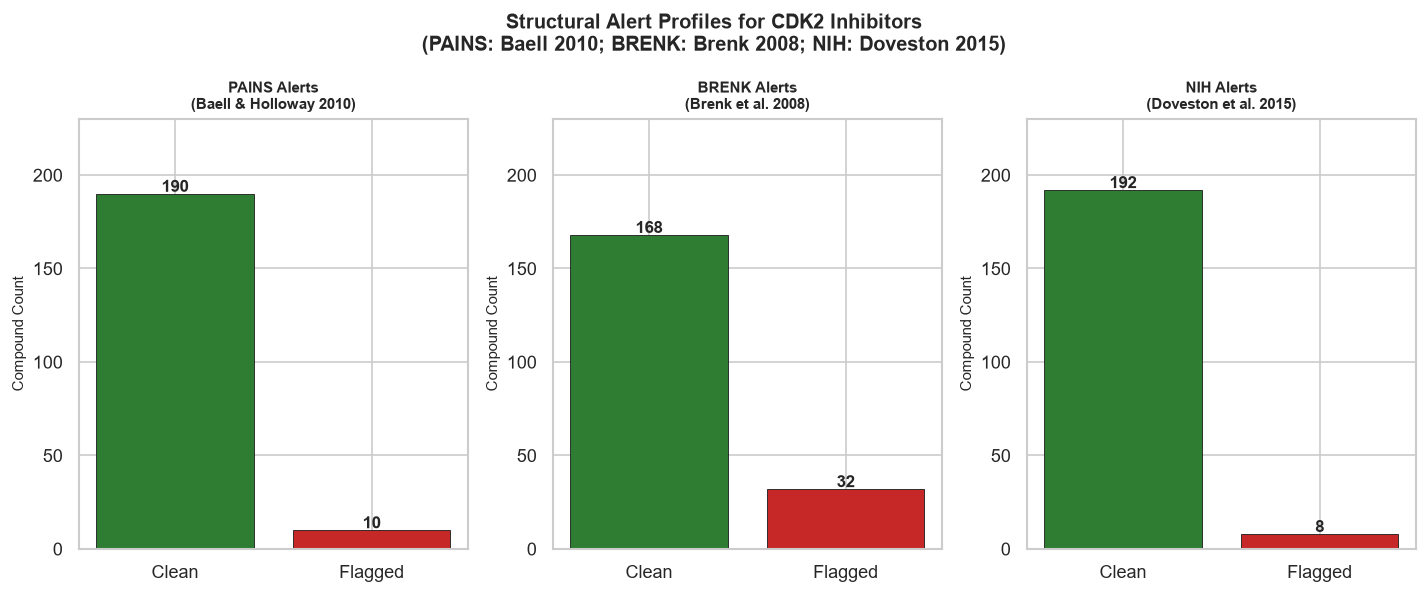

[SAVED] admet_structural_alerts.png


In [7]:
# ============================================================
# CELL 4 — Drug-Likeness and Structural Alert Profiling
# Assesses Lipinski Ro5 compliance and three structural alert
# systems implemented via RDKit substructure matching.
# References:
# - Lipinski CA et al. (1997) Adv Drug Deliv Rev 23(1-3):3-25
# - Baell JB & Holloway GA (2010) J Med Chem 53(7):2719-2740
# - Brenk R et al. (2008) ChemMedChem 3(3):435-444
# - Doveston RG et al. (2015) MedChemComm 6(12):2150-2154
# All imports already loaded in Cell 0
# ============================================================

total = len(df_admet)

# ── Lipinski Ro5 — safe column resolution ────────────────────────────────────
# Lipinski score from ADMET-AI: 1.0 = passes all four rules, 0.0 = violates one or more.
# Threshold >= 0.5 flags full compliance (all four rules satisfied).
lip_col = next((c for c in df_admet.columns if c.lower() == 'lipinski'), None)
if lip_col:
    lip_pass = df_admet[lip_col].fillna(0)
    n_lip = (lip_pass >= 0.5).sum()
    print(f'  Lipinski Ro5 pass: {n_lip}/{total} ({100*n_lip/total:.1f}%)')
else:
    print('  [WARN] Lipinski column not found in ADMET-AI output.')
    lip_pass = None

# ── Resolve structural alert column names safely ──────────────────────────────
# ADMET-AI column names for PAINS/BRENK/NIH alerts may vary by version.
# _find_col() searches by exact name first, then case-insensitive fallback.
# If a column is absent entirely, a zero-filled placeholder is created so
# downstream cells (Cell 12, Cell 13, Cell 15) do not crash with KeyError.
def _find_col(df, candidates):
    """Return the first matching column name from candidates, else None."""
    for c in candidates:
        if c in df.columns:
            return c
    for c in df.columns:
        for cand in candidates:
            if c.lower() == cand.lower():
                return c
    return None

PAINS_COL = _find_col(df_admet, ['PAINS_alert', 'PAINS', 'pains_alert'])
BRENK_COL = _find_col(df_admet, ['BRENK_alert', 'BRENK', 'brenk_alert', 'Brenk'])
NIH_COL   = _find_col(df_admet, ['NIH_alert',   'NIH',   'nih_alert'])

for col_var, col_name in [
    (PAINS_COL, 'PAINS_alert'),
    (BRENK_COL, 'BRENK_alert'),
    (NIH_COL,   'NIH_alert')
]:
    if col_var is None:
        print(f'  [WARN] {col_name} not found — creating zero-filled placeholder.')
        df_admet[col_name] = 0.0
        if col_name == 'PAINS_alert': PAINS_COL = col_name
        if col_name == 'BRENK_alert': BRENK_COL = col_name
        if col_name == 'NIH_alert':   NIH_COL   = col_name

print(f'  Alert columns resolved: PAINS={PAINS_COL}, BRENK={BRENK_COL}, NIH={NIH_COL}')
print()

# ── Structural alert summary ──────────────────────────────────────────────────
# A binary threshold of 0.5 distinguishes flagged (>=0.5) from clean (<0.5).
# Flagged compounds are annotated, not automatically excluded — alerts indicate
# statistical risk and require expert structural review (Baell & Holloway 2010).
print('Drug-Likeness and Structural Alert Summary')
print('=' * 55)
for col, label in [
    (PAINS_COL, 'PAINS  (Baell 2010)  '),
    (BRENK_COL, 'BRENK  (Brenk 2008)  '),
    (NIH_COL,   'NIH    (Doveston 2015)')
]:
    flagged = (df_admet[col].fillna(0) >= 0.5).sum()
    print(f'  {label} flagged: {flagged}/{total} ({100*flagged/total:.1f}%)')

clean_all = df_admet[
    (df_admet[PAINS_COL].fillna(0) < 0.5) &
    (df_admet[BRENK_COL].fillna(0) < 0.5) &
    (df_admet[NIH_COL].fillna(0)   < 0.5)
]
print(f'  Clean (no alerts)      : {len(clean_all)}/{total} ({100*len(clean_all)/total:.1f}%)')

# ── Three-panel bar chart — one panel per alert system ───────────────────────
# Bar charts are the clearest representation for binary flag counts.
# QED is shown in Cell 3 and is not repeated here.
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
fig.suptitle(
    'Structural Alert Profiles for CDK2 Inhibitors\n'
    '(PAINS: Baell 2010; BRENK: Brenk 2008; NIH: Doveston 2015)',
    fontsize=12, fontweight='bold'
)

alert_info = [
    (PAINS_COL, 'PAINS Alerts\n(Baell & Holloway 2010)'),
    (BRENK_COL, 'BRENK Alerts\n(Brenk et al. 2008)'),
    (NIH_COL,   'NIH Alerts\n(Doveston et al. 2015)'),
]

for ax, (col, title) in zip(axes, alert_info):
    flagged = (df_admet[col].fillna(0) >= 0.5).sum()
    clean   = total - flagged
    bars = ax.bar(
        ['Clean', 'Flagged'],
        [clean, flagged],
        color=[PALETTE['safe'], PALETTE['risk']],
        edgecolor='k',
        linewidth=0.5
    )
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            str(int(bar.get_height())),
            ha='center',
            fontweight='bold',
            fontsize=10
        )
    ax.set_ylabel('Compound Count', fontsize=9)
    ax.set_title(title, fontsize=9)
    ax.set_ylim(0, total * 1.15)

plt.tight_layout()
plt.savefig('admet_structural_alerts.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] admet_structural_alerts.png')

## Cell 5 — Absorption Property Profiling

Absorption determines how much drug reaches systemic circulation after oral dosing.
ADMET-AI 2.0 predicts five absorption endpoints using Chemprop-RDKit graph neural networks
trained on TDC datasets. All five are predictions — none are RDKit computations.

| Endpoint | Type | Threshold | Interpretation | Reference |
|---|---|---|---|---|
| Caco2_Wang | Continuous (log cm/s) | > −5.15 | Higher = better intestinal permeability | Wang et al. (2016) |
| HIA_Hou | Binary probability | ≥ 0.5 | Predicted absorbed (≥ 30% human intestinal absorption) | Hou et al. (2007) |
| Bioavailability_Ma | Binary probability | ≥ 0.5 | Predicted orally bioavailable (F > 20%) | Ma et al. (2008) |
| PAMPA_NCATS | Continuous | Higher = better | Passive membrane permeability (NCATS assay) | Siramshetty et al. (2021) |
| Pgp_Broccatelli | Binary probability | < 0.5 preferred | Non-substrate preferred (avoids efflux) | Broccatelli et al. (2011) |

**References:**
- Wang NN et al. (2016) *Mol Pharm* 13(12):4124–4135
- Hou T et al. (2007) *J Chem Inf Model* 47(1):208–218
- Ma CY et al. (2008) *J Chem Inf Model* 48(2):255–259
- Siramshetty VB et al. (2021) *SLAS Discov* 26(10):1355–1363
- Broccatelli F et al. (2011) *J Med Chem* 54(6):1740–1751

Absorption Property Summary
  Caco2_Wang                         : mean=-5.172  std=0.353  range=[-7.095, -4.549]
  HIA_Hou                            : Positive: 198/200 (99.0%)
  Bioavailability_Ma                 : Positive: 197/200 (98.5%)
  PAMPA_NCATS                        : mean=0.767  std=0.184  range=[0.026, 0.979]
  Pgp_Broccatelli                    : Non-substrate (favourable): 108/200 (54.0%)


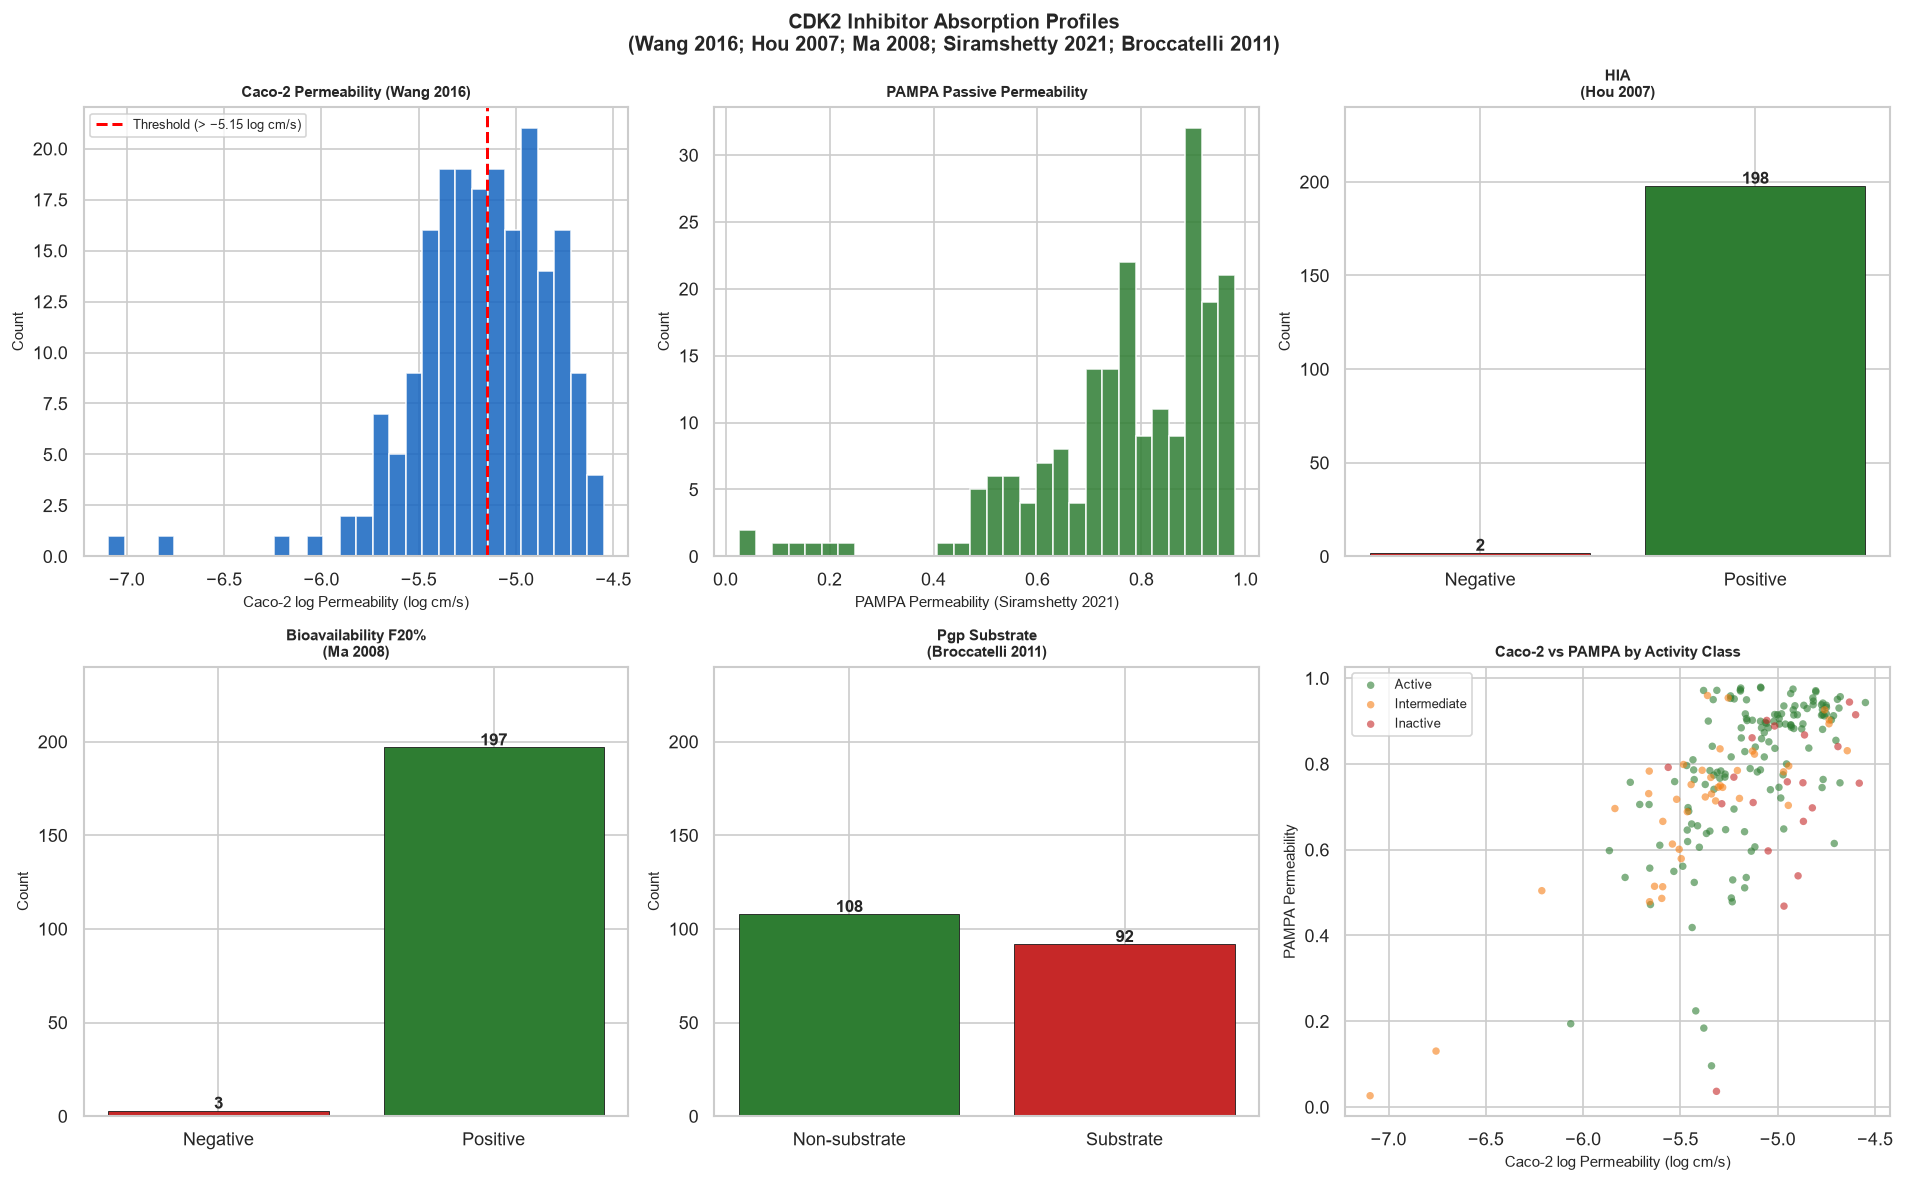

[SAVED] admet_absorption.png


In [8]:
# ============================================================
# CELL 5 — Absorption Property Profiling
# Five endpoints predicted by ADMET-AI 2.0 (Chemprop-RDKit GNN).
# All imports already loaded in Cell 0.
# References:
# - Caco-2   : Wang NN et al. (2016) Mol Pharm 13(12):4124-4135
# - HIA      : Hou T et al. (2007) J Chem Inf Model 47(1):208-218
# - Bioavail : Ma CY et al. (2008) J Chem Inf Model 48(2):255-259
# - PAMPA    : Siramshetty VB et al. (2021) SLAS Discov 26(10):1355-1363
# - Pgp      : Broccatelli F et al. (2011) J Med Chem 54(6):1740-1751
# ============================================================

# ── Activity colour palette (defined globally in Cell 3; redefined here for safety) ──
act_colors = {
    'Active':       PALETTE['safe'],
    'Intermediate': PALETTE['moderate'],
    'Inactive':     PALETTE['risk']
}

# ── Case-insensitive column resolver ─────────────────────────────────────────
# ADMET-AI versions may differ in column capitalisation.
# _safe_col() returns the actual column name or None if absent.
# This is used consistently throughout — no hardcoded column names in plot code.
_col_map = {c.lower(): c for c in df_admet.columns}

def _safe_col(name):
    """Return actual df_admet column name matching name (case-insensitive), or None."""
    return _col_map.get(name.lower(), None)

# ── Define endpoints with metadata ───────────────────────────────────────────
# Each entry: (raw_name, endpoint_type, favourable_direction, plot_label, reference)
abs_endpoint_defs = [
    ('Caco2_Wang',          'cont', 'high', 'Caco-2 Permeability\n(Wang 2016)',       'Caco-2 log Papp (log cm/s)'),
    ('HIA_Hou',             'bin',  'high', 'HIA\n(Hou 2007)',                         'Probability'),
    ('Bioavailability_Ma',  'bin',  'high', 'Bioavailability F20%\n(Ma 2008)',         'Probability'),
    ('PAMPA_NCATS',         'cont', 'high', 'PAMPA Permeability\n(Siramshetty 2021)',  'PAMPA Permeability'),
    ('Pgp_Broccatelli',     'bin',  'low',  'Pgp Substrate\n(Broccatelli 2011)',       'Probability'),
]

# Resolve actual column names — skip any that are absent
abs_endpoints = []
for raw, atype, sdir, lbl, xlabel in abs_endpoint_defs:
    actual = _safe_col(raw)
    if actual:
        abs_endpoints.append((actual, atype, sdir, lbl, xlabel))
    else:
        print(f'  [WARN] Column "{raw}" not found in ADMET-AI output (skipped).')
        print('         Check admet-ai version matches environment.yml (==2.0.1)')

# ── Summary statistics ────────────────────────────────────────────────────────
print('Absorption Property Summary')
print('=' * 60)
for col, atype, sdir, lbl, _ in abs_endpoints:
    d = df_admet[col].dropna()
    if atype == 'bin':
        n_fav = (d >= 0.5).sum() if sdir == 'high' else (d < 0.5).sum()
        tag   = 'Positive' if sdir == 'high' else 'Non-substrate (favourable)'
        print(f'  {col:<35}: {tag}: {n_fav}/{len(d)} ({100*n_fav/len(d):.1f}%)')
    else:
        print(f'  {col:<35}: mean={d.mean():.3f}  std={d.std():.3f}  '
              f'range=[{d.min():.3f}, {d.max():.3f}]')

# ── Six-panel figure ──────────────────────────────────────────────────────────
# Panel layout:
#   [0,0] Caco-2 histogram     [0,1] PAMPA histogram      [0,2] HIA bar chart
#   [1,0] Bioavailability bar  [1,1] Pgp bar chart        [1,2] Caco-2 vs PAMPA scatter
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    'CDK2 Inhibitor Absorption Profiles\n'
    '(Wang 2016; Hou 2007; Ma 2008; Siramshetty 2021; Broccatelli 2011)',
    fontsize=12, fontweight='bold'
)

# Panel [0,0]: Caco-2 histogram
caco2_col = _safe_col('Caco2_Wang')
if caco2_col:
    caco2 = df_admet[caco2_col].dropna()
    axes[0, 0].hist(caco2, bins=30, color=PALETTE['neutral'],
                    edgecolor='white', alpha=0.85)
    axes[0, 0].axvline(-5.15, color='red', linestyle='--', lw=1.8,
                       label='Threshold (> −5.15 log cm/s)')
    axes[0, 0].set_xlabel('Caco-2 log Permeability (log cm/s)', fontsize=9)
    axes[0, 0].set_ylabel('Count', fontsize=9)
    axes[0, 0].set_title('Caco-2 Permeability (Wang 2016)', fontsize=9)
    axes[0, 0].legend(fontsize=8)

# Panel [0,1]: PAMPA histogram
pampa_col = _safe_col('PAMPA_NCATS')
if pampa_col:
    pampa = df_admet[pampa_col].dropna()
    axes[0, 1].hist(pampa, bins=30, color=PALETTE['safe'],
                    edgecolor='white', alpha=0.85)
    axes[0, 1].set_xlabel('PAMPA Permeability (Siramshetty 2021)', fontsize=9)
    axes[0, 1].set_ylabel('Count', fontsize=9)
    axes[0, 1].set_title('PAMPA Passive Permeability', fontsize=9)

# Panels [0,2], [1,0], [1,1]: Binary endpoint bar charts
binary_panels = [
    (axes[0, 2], 'HIA_Hou',            'HIA\n(Hou 2007)',                  'high'),
    (axes[1, 0], 'Bioavailability_Ma', 'Bioavailability F20%\n(Ma 2008)', 'high'),
    (axes[1, 1], 'Pgp_Broccatelli',    'Pgp Substrate\n(Broccatelli 2011)', 'low'),
]

for ax, raw_col, title, sdir in binary_panels:
    actual = _safe_col(raw_col)
    if actual is None:
        ax.axis('off')
        ax.set_title(f'{title}\n[column not found]', fontsize=9)
        continue
    vals = df_admet[actual].dropna()
    pos  = (vals >= 0.5).sum()
    neg  = len(vals) - pos
    if sdir == 'high':
        bar_colors = [PALETTE['risk'], PALETTE['safe']]
        bar_labels = ['Negative', 'Positive']
        counts     = [neg, pos]
    else:
        bar_colors = [PALETTE['safe'], PALETTE['risk']]
        bar_labels = ['Non-substrate', 'Substrate']
        counts     = [neg, pos]
    bars = ax.bar(bar_labels, counts, color=bar_colors,
                  edgecolor='k', linewidth=0.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1,
                str(int(bar.get_height())),
                ha='center', fontweight='bold', fontsize=10)
    ax.set_ylabel('Count', fontsize=9)
    ax.set_title(title, fontsize=9)
    ax.set_ylim(0, len(vals) * 1.2)

# Panel [1,2]: Caco-2 vs PAMPA scatter coloured by activity class
if caco2_col and pampa_col:
    sc = df_admet[[caco2_col, pampa_col, 'activity']].dropna()
    for cls, clr in act_colors.items():
        sub = sc[sc['activity'] == cls]
        axes[1, 2].scatter(
            sub[caco2_col], sub[pampa_col],
            c=clr, label=cls, alpha=0.6, s=20, edgecolors='none'
        )
    axes[1, 2].set_xlabel('Caco-2 log Permeability (log cm/s)', fontsize=9)
    axes[1, 2].set_ylabel('PAMPA Permeability', fontsize=9)
    axes[1, 2].set_title('Caco-2 vs PAMPA by Activity Class', fontsize=9)
    axes[1, 2].legend(fontsize=8)
else:
    axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('admet_absorption.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] admet_absorption.png')

## Cell 6 — Distribution Property Profiling

Distribution describes how a drug spreads from the bloodstream into tissues after absorption.
ADMET-AI 2.0 predicts three distribution endpoints. All three are predictions from
Chemprop-RDKit graph neural networks trained on TDC datasets — none are RDKit computations.

| Endpoint | Type | Threshold | Interpretation | Reference |
|---|---|---|---|---|
| BBB_Martins | Binary probability | ≥ 0.5 = penetrant | CNS drugs require penetration; peripheral targets prefer non-penetrant | Martins et al. (2012) |
| PPBR_AZ | Continuous (%) | < 90% preferred | Only unbound fraction is pharmacologically active; >90% restricts free drug | AstraZeneca dataset via TDC |
| VDss_Lombardo | Continuous (L/kg) | > 1 L/kg = high | Extensive tissue distribution beyond plasma compartment | Lombardo et al. (2002) |

**Key interpretation note:** BBB penetration is not universally desirable. For CDK2 inhibitors
targeting peripheral tumours, low BBB penetration is preferred to minimise CNS side effects.
For CDK2 inhibitors targeting neurological indications, BBB penetration is required.
Context of use must always guide interpretation of predicted BBB values.

**References:**
- Martins IF et al. (2012) *J Chem Inf Model* 52(7):1686–1697
- AstraZeneca PPBR dataset via TDC: Huang K et al. (2021) NeurIPS 2021 Datasets and Benchmarks
- Lombardo F et al. (2002) *J Med Chem* 45(13):2867–2876

Distribution Property Summary
  BBB penetrant (Martins 2012)  : 140/200 (70.0%)
  Mean PPBR (AZ via TDC)        : 89.5%
  PPBR >= 90% (high binding)    : 110/200 (55.0%)
  Mean VDss (Lombardo 2002)     : 7.723 L/kg
  VDss >= 1 L/kg (high distrib) : 182/200 (91.0%)


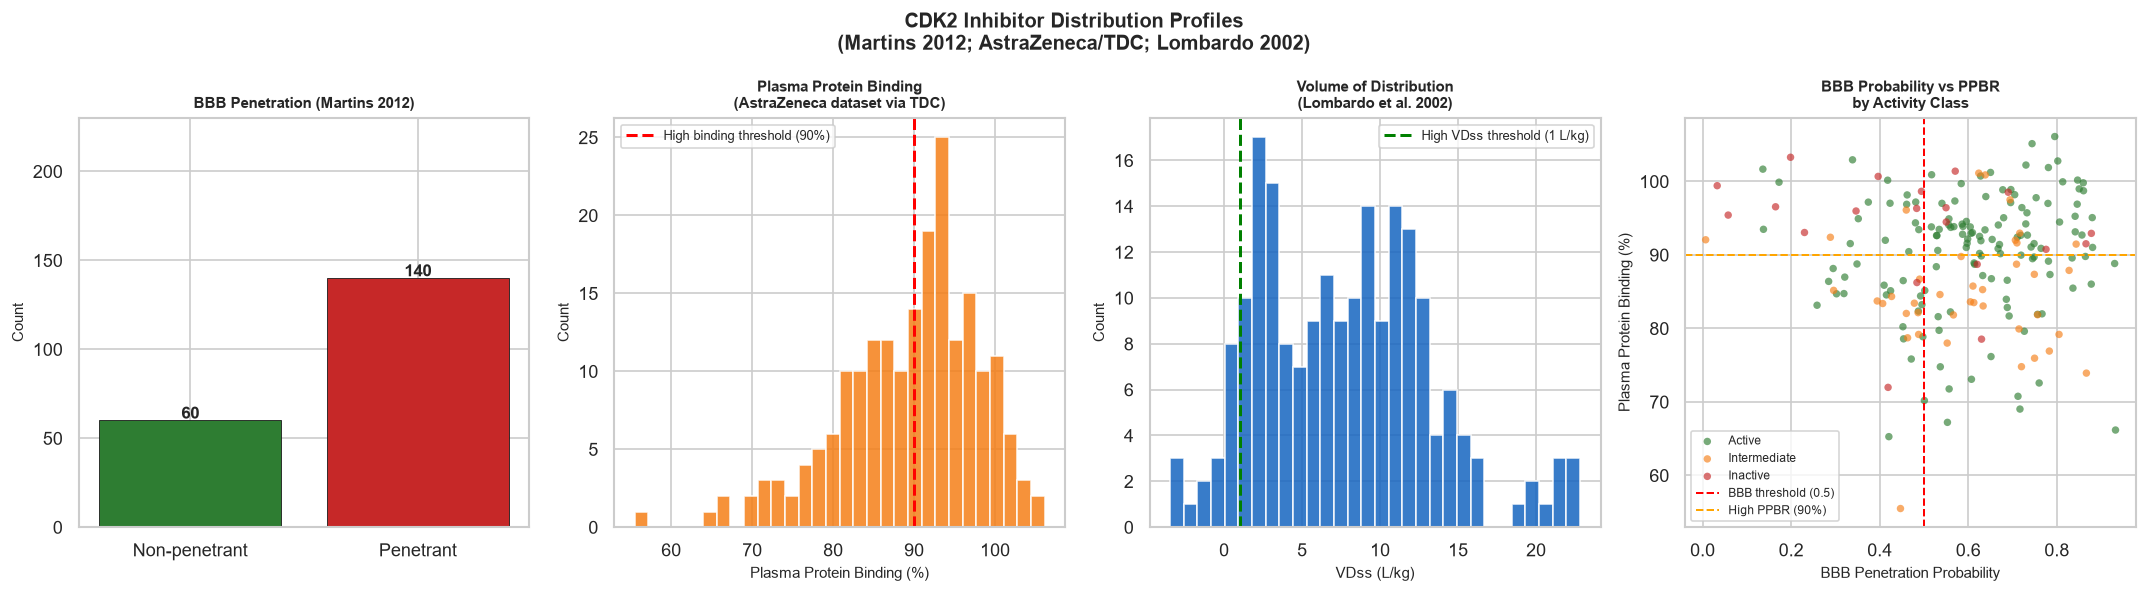

[SAVED] admet_distribution.png


In [9]:
# ============================================================
# CELL 6 — Distribution Property Profiling
# Three endpoints predicted by ADMET-AI 2.0 (Chemprop-RDKit GNN).
# All imports already loaded in Cell 0.
# References:
# - BBB  : Martins IF et al. (2012) J Chem Inf Model 52(7):1686-1697
# - PPBR : AstraZeneca dataset via TDC (Huang et al. 2021 NeurIPS)
# - VDss : Lombardo F et al. (2002) J Med Chem 45(13):2867-2876
# ============================================================

# ── Activity colour palette (redefined locally for cell independence) ─────────
act_colors = {
    'Active':       PALETTE['safe'],
    'Intermediate': PALETTE['moderate'],
    'Inactive':     PALETTE['risk']
}

# ── Case-insensitive column resolver ─────────────────────────────────────────
# Consistent with Cell 5 approach — no hardcoded column names in plot code.
_col_map_dist = {c.lower(): c for c in df_admet.columns}

def _safe_col_dist(name):
    """Return actual df_admet column name matching name (case-insensitive), or None."""
    return _col_map_dist.get(name.lower(), None)

bbb_col  = _safe_col_dist('BBB_Martins')
ppbr_col = _safe_col_dist('PPBR_AZ')
vdss_col = _safe_col_dist('VDss_Lombardo')

for col_name, actual in [('BBB_Martins', bbb_col),
                          ('PPBR_AZ',     ppbr_col),
                          ('VDss_Lombardo', vdss_col)]:
    if actual is None:
        print(f'  [WARN] Column "{col_name}" not found in ADMET-AI output.')
        print('         Check admet-ai version matches environment.yml (==2.0.1)')

# ── Summary statistics ────────────────────────────────────────────────────────
print('Distribution Property Summary')
print('=' * 55)

if bbb_col:
    bbb      = df_admet[bbb_col].dropna()
    bbb_pen  = (bbb >= 0.5).sum()
    print(f'  BBB penetrant (Martins 2012)  : {bbb_pen}/{len(bbb)} ({100*bbb_pen/len(bbb):.1f}%)')
else:
    bbb = None; bbb_pen = 0

if ppbr_col:
    ppbr = df_admet[ppbr_col].dropna()
    print(f'  Mean PPBR (AZ via TDC)        : {ppbr.mean():.1f}%')
    print(f'  PPBR >= 90% (high binding)    : {(ppbr>=90).sum()}/{len(ppbr)} ({100*(ppbr>=90).mean():.1f}%)')
else:
    ppbr = None

if vdss_col:
    vdss = df_admet[vdss_col].dropna()
    print(f'  Mean VDss (Lombardo 2002)     : {vdss.mean():.3f} L/kg')
    print(f'  VDss >= 1 L/kg (high distrib) : {(vdss>=1).sum()}/{len(vdss)} ({100*(vdss>=1).mean():.1f}%)')
else:
    vdss = None

# ── Four-panel figure ─────────────────────────────────────────────────────────
# [0] BBB bar chart   [1] PPBR histogram   [2] VDss histogram   [3] BBB vs PPBR scatter
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(
    'CDK2 Inhibitor Distribution Profiles\n'
    '(Martins 2012; AstraZeneca/TDC; Lombardo 2002)',
    fontsize=12, fontweight='bold'
)

# Panel 0: BBB bar chart
if bbb is not None:
    counts = [len(bbb) - bbb_pen, bbb_pen]
    bars   = axes[0].bar(
        ['Non-penetrant', 'Penetrant'], counts,
        color=[PALETTE['safe'], PALETTE['risk']], edgecolor='k', linewidth=0.5
    )
    for bar, val in zip(bars, counts):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            str(int(val)), ha='center', fontweight='bold', fontsize=10
        )
    axes[0].set_title('BBB Penetration (Martins 2012)', fontsize=9)
    axes[0].set_ylabel('Count', fontsize=9)
    axes[0].set_ylim(0, len(bbb) * 1.15)
else:
    axes[0].axis('off')
    axes[0].set_title('BBB [column not found]', fontsize=9)

# Panel 1: PPBR histogram
if ppbr is not None:
    axes[1].hist(ppbr, bins=30, color=PALETTE['moderate'],
                 edgecolor='white', alpha=0.85)
    axes[1].axvline(90, color='red', linestyle='--', lw=1.8,
                    label='High binding threshold (90%)')
    axes[1].set_xlabel('Plasma Protein Binding (%)', fontsize=9)
    axes[1].set_ylabel('Count', fontsize=9)
    axes[1].set_title('Plasma Protein Binding\n(AstraZeneca dataset via TDC)', fontsize=9)
    axes[1].legend(fontsize=8)
else:
    axes[1].axis('off')

# Panel 2: VDss histogram
if vdss is not None:
    axes[2].hist(vdss, bins=30, color=PALETTE['neutral'],
                 edgecolor='white', alpha=0.85)
    axes[2].axvline(1.0, color='green', linestyle='--', lw=1.8,
                    label='High VDss threshold (1 L/kg)')
    axes[2].set_xlabel('VDss (L/kg)', fontsize=9)
    axes[2].set_ylabel('Count', fontsize=9)
    axes[2].set_title('Volume of Distribution\n(Lombardo et al. 2002)', fontsize=9)
    axes[2].legend(fontsize=8)
else:
    axes[2].axis('off')

# Panel 3: BBB probability vs PPBR scatter coloured by activity class
if bbb_col and ppbr_col:
    sc = df_admet[[bbb_col, ppbr_col, 'activity']].dropna()
    for cls, clr in act_colors.items():
        sub = sc[sc['activity'] == cls]
        axes[3].scatter(
            sub[bbb_col], sub[ppbr_col],
            c=clr, label=cls, alpha=0.65, s=20, edgecolors='none'
        )
    axes[3].axvline(0.5, color='red', linestyle='--', lw=1.2,
                    label='BBB threshold (0.5)')
    axes[3].axhline(90, color='orange', linestyle='--', lw=1.2,
                    label='High PPBR (90%)')
    axes[3].set_xlabel('BBB Penetration Probability', fontsize=9)
    axes[3].set_ylabel('Plasma Protein Binding (%)', fontsize=9)
    axes[3].set_title('BBB Probability vs PPBR\nby Activity Class', fontsize=9)
    axes[3].legend(fontsize=7)
else:
    axes[3].axis('off')

plt.tight_layout()
plt.savefig('admet_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] admet_distribution.png')

## Cell 7 — CYP450 Metabolism Analysis

CYP450 enzymes metabolise approximately 75% of all marketed drugs across five major isoforms.
ADMET-AI 2.0 predicts seven CYP450 endpoints: five inhibition endpoints and three substrate
endpoints. Note that the percentages below overlap — most drugs are metabolised by multiple
isoforms simultaneously, so they do not sum to 100%.

| Isoform | Approximate contribution | Key substrates | Training data source |
|---|---|---|---|
| CYP1A2 | ~15% | Caffeine, Clozapine | Veith et al. (2009) |
| CYP2C9 | ~15% | Warfarin, Ibuprofen | Veith et al. (2009) |
| CYP2C19 | ~10% | Omeprazole, Clopidogrel | Veith et al. (2009) |
| CYP2D6 | ~20% | Codeine, Tamoxifen | Veith et al. (2009) |
| CYP3A4 | ~50% | Atorvastatin, Midazolam | Carbon-Mangels & Hutter (2011) |

Percentages represent approximate fraction of marketed drugs metabolised by each isoform
as a primary pathway (Rendic 2002). Overlap is common — a single drug may be metabolised
by two or more isoforms simultaneously.

All endpoints are predicted by ADMET-AI 2.0 using Chemprop-RDKit graph neural networks
trained on TDC datasets (Huang et al. 2021). A predicted probability ≥ 0.5 indicates
predicted inhibitor or substrate status at the classification threshold used by TDC benchmarks.

**References:**
- Veith H et al. (2009) *Nat Biotechnol* 27(11):1050–1055
- Carbon-Mangels M & Hutter MC (2011) *Mol Inform* 30(10):885–895
- Rendic S (2002) *Drug Metab Rev* 34(1–2):83–448
- Huang K et al. (2021) NeurIPS 2021 Datasets and Benchmarks Track (TDC)

CYP450 Metabolism Summary (probability >= 0.5 = predicted positive)
  Endpoint                                  Positive  Negative    % Pos
  -----------------------------------------------------------------
  CYP1A2 Inhibitor                                75       125    37.5%
  CYP2C19 Inhibitor                               62       138    31.0%
  CYP2C9 Inhibitor                                54       146    27.0%
  CYP2D6 Inhibitor                                21       179    10.5%
  CYP3A4 Inhibitor                                77       123    38.5%
  CYP2C9 Substrate                                 1       199     0.5%
  CYP2D6 Substrate                                 1       199     0.5%
  CYP3A4 Substrate                               157        43    78.5%


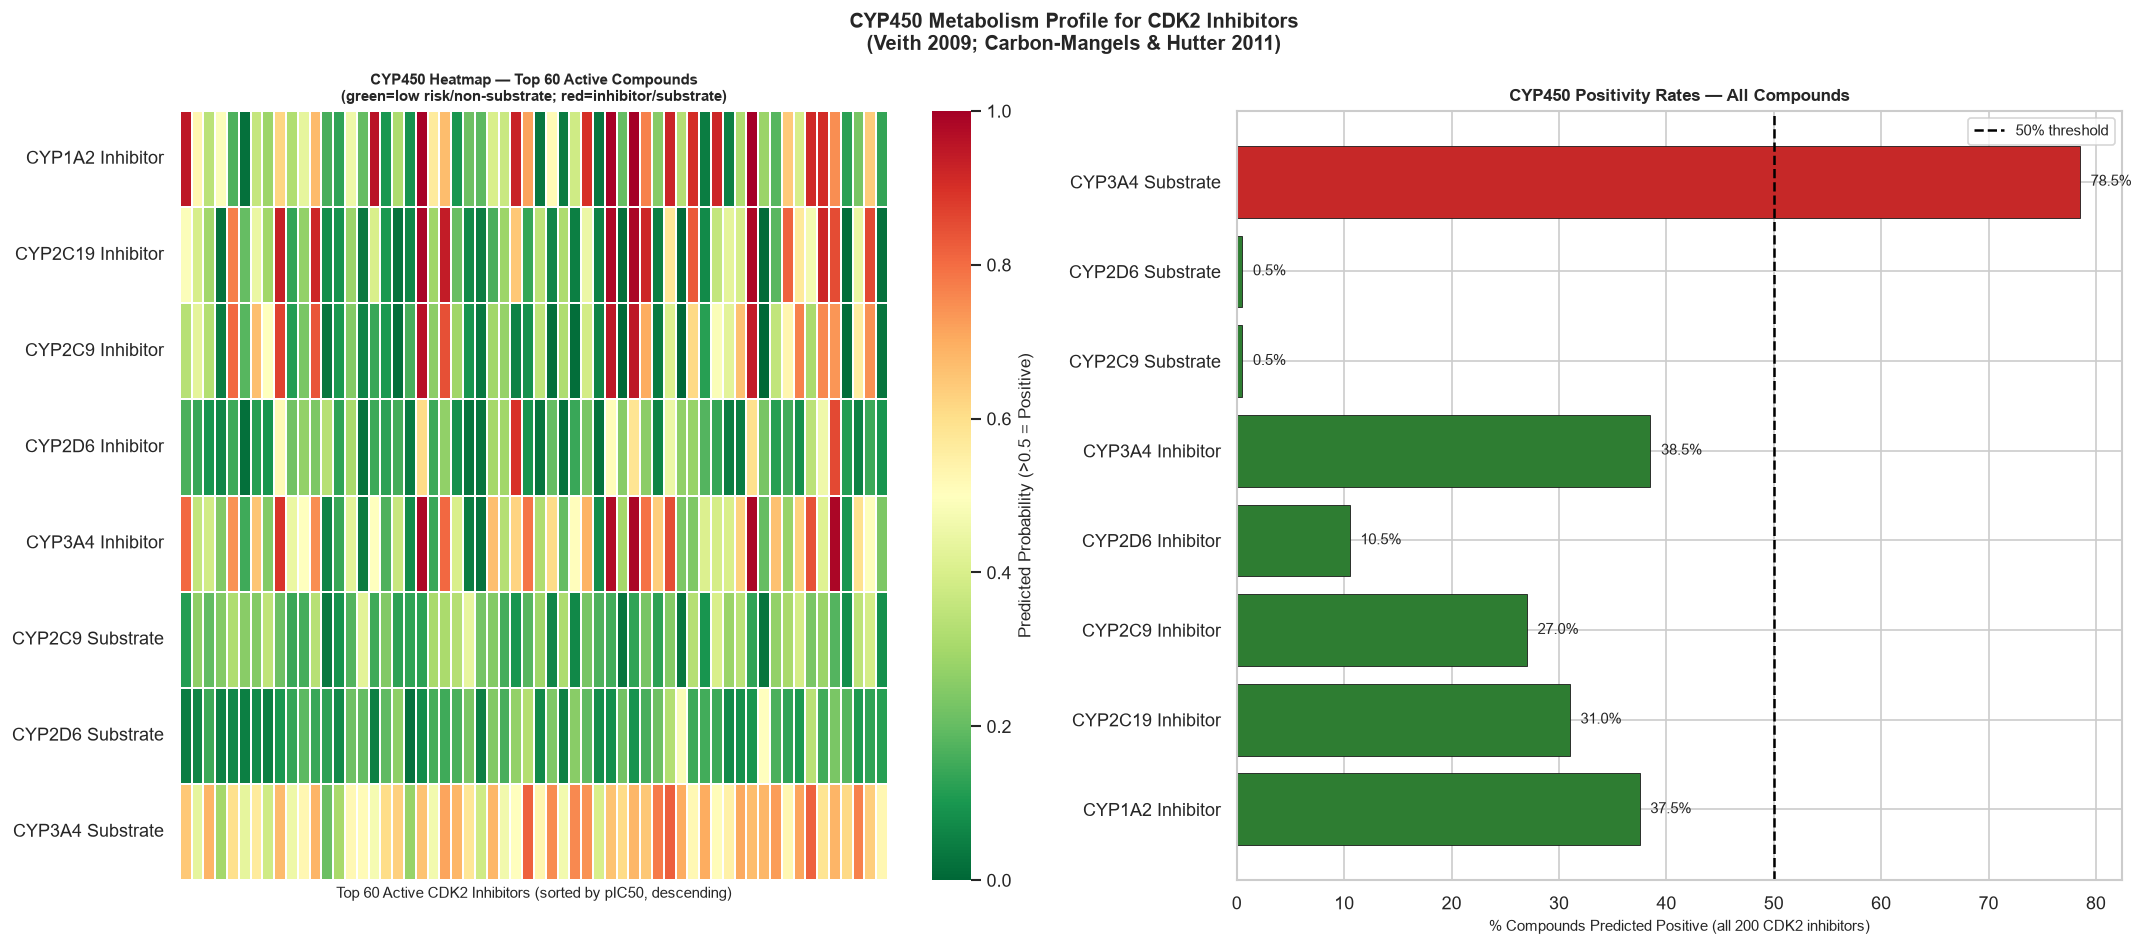

[SAVED] admet_cyp450_metabolism.png


In [10]:
# ============================================================
# CELL 7 — CYP450 Metabolism Analysis
# Predicts inhibition (5 isoforms) and substrate status (3 isoforms).
# All endpoints predicted by ADMET-AI 2.0 (Chemprop-RDKit GNN).
# References:
# - Veith H et al. (2009) Nat Biotechnol 27(11):1050-1055
# - Carbon-Mangels M & Hutter MC (2011) Mol Inform 30(10):885-895
# - Rendic S (2002) Drug Metab Rev 34(1-2):83-448
# All imports already loaded in Cell 0
# ============================================================

# ── CYP450 endpoint definitions ───────────────────────────────────────────────
# Inhibition endpoints (Veith et al. 2009 training data via TDC)
cyp_inhib = {
    'CYP1A2_Veith':  'CYP1A2 Inhibitor',
    'CYP2C19_Veith': 'CYP2C19 Inhibitor',
    'CYP2C9_Veith':  'CYP2C9 Inhibitor',
    'CYP2D6_Veith':  'CYP2D6 Inhibitor',
    'CYP3A4_Veith':  'CYP3A4 Inhibitor',
}
# Substrate endpoints (Carbon-Mangels & Hutter 2011 training data via TDC)
cyp_subs = {
    'CYP2C9_Substrate_CarbonMangels':  'CYP2C9 Substrate',
    'CYP2D6_Substrate_CarbonMangels':  'CYP2D6 Substrate',
    'CYP3A4_Substrate_CarbonMangels':  'CYP3A4 Substrate',
}
all_cyp = {**cyp_inhib, **cyp_subs}

# ── Verify all CYP columns exist ─────────────────────────────────────────────
missing_cyp = [col for col in all_cyp if col not in df_admet.columns]
if missing_cyp:
    print(f'  [WARN] Missing CYP columns: {missing_cyp}')
    print('         Check admet-ai version matches environment.yml (==2.0.1)')
    all_cyp = {k: v for k, v in all_cyp.items() if k in df_admet.columns}

# ── Summary table ─────────────────────────────────────────────────────────────
# Probability >= 0.5 = predicted positive (inhibitor or substrate).
# This threshold follows the binary classification convention used by TDC benchmarks.
print('CYP450 Metabolism Summary (probability >= 0.5 = predicted positive)')
print('=' * 65)
print(f'  {"Endpoint":<40} {"Positive":>9} {"Negative":>9} {"% Pos":>8}')
print('  ' + '-' * 65)
for col, label in all_cyp.items():
    vals = df_admet[col].dropna()
    pos  = (vals >= 0.5).sum()
    print(f'  {label:<40} {pos:>9} {len(vals)-pos:>9} {100*pos/len(vals):>7.1f}%')

# ── Figure: heatmap (Active compounds) + bar chart (all 200) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle(
    'CYP450 Metabolism Profile for CDK2 Inhibitors\n'
    '(Veith 2009; Carbon-Mangels & Hutter 2011)',
    fontsize=12, fontweight='bold'
)

# Panel 1: Heatmap — top 60 Active compounds by pIC50
# Sorted by pIC50 descending so the most potent CDK2 inhibitors appear first.
# Subset to Active class only for clarity; full dataset shown in Panel 2.
active_sub = (df_admet[df_admet['activity'] == 'Active']
              .sort_values('pIC50', ascending=False)
              .head(60))

cyp_matrix = active_sub[list(all_cyp.keys())].fillna(0.5)

sns.heatmap(
    cyp_matrix.T,
    ax=axes[0],
    cmap='RdYlGn_r',
    vmin=0, vmax=1,
    yticklabels=list(all_cyp.values()),
    xticklabels=False,
    linewidths=0.1,
    linecolor='white',
    cbar_kws={'label': 'Predicted Probability (>0.5 = Positive)'}
)
axes[0].set_xlabel(
    'Top 60 Active CDK2 Inhibitors (sorted by pIC50, descending)', fontsize=9
)
axes[0].set_title(
    'CYP450 Heatmap — Top 60 Active Compounds\n'
    '(green=low risk/non-substrate; red=inhibitor/substrate)',
    fontsize=9
)

# Panel 2: Bar chart — positivity rates across all 200 compounds
pct_pos    = [100 * (df_admet[col].dropna() >= 0.5).mean() for col in all_cyp]
bar_colors = [PALETTE['risk'] if p > 50 else PALETTE['safe'] for p in pct_pos]

bars = axes[1].barh(
    list(all_cyp.values()),
    pct_pos,
    color=bar_colors,
    edgecolor='k',
    linewidth=0.5
)
axes[1].axvline(50, color='black', linestyle='--', lw=1.5, label='50% threshold')
for bar, pct in zip(bars, pct_pos):
    axes[1].text(
        pct + 1,
        bar.get_y() + bar.get_height() / 2,
        f'{pct:.1f}%',
        va='center',
        fontsize=9
    )
axes[1].set_xlabel('% Compounds Predicted Positive (all 200 CDK2 inhibitors)', fontsize=9)
axes[1].set_title('CYP450 Positivity Rates — All Compounds', fontsize=10)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('admet_cyp450_metabolism.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] admet_cyp450_metabolism.png')

## Cell 8 — Excretion Property Profiling

Excretion is the elimination of drugs and metabolites from the body, primarily via renal
and hepatic routes. ADMET-AI 2.0 predicts three excretion endpoints using Chemprop-RDKit
graph neural networks trained on TDC datasets. All three are predictions — none are RDKit
computations.

| Endpoint | Type | Unit | Interpretation | Reference |
|---|---|---|---|---|
| Clearance_Hepatocyte_AZ | Continuous | µL/min/10⁶ cells | High = rapid hepatic elimination; short effective half-life | AstraZeneca via TDC |
| Clearance_Microsome_AZ | Continuous | µL/min/mg protein | CYP450-mediated microsomal clearance; high = rapid metabolism | AstraZeneca via TDC |
| Half_Life_Obach | Continuous | Hours | Time for plasma concentration to fall 50%; drives dosing frequency | Obach et al. (2008) |

**Half-life clinical categories (Obach 2008):**
- < 1h — very rapid elimination; impractical for most oral dosing regimens
- 1–8h — short; requires multiple daily doses
- 8–24h — moderate; suitable for once or twice daily dosing
- > 24h — long-acting; once daily or less frequent dosing feasible

**Key interpretation note:** High predicted clearance does not automatically disqualify a
compound. Prodrug strategies, modified release formulations, and sustained delivery systems
can compensate for rapid clearance in drug development. Predicted values should be treated
as screening-level estimates requiring experimental confirmation (e.g. in vitro hepatocyte
or microsome assays).

**References:**
- Obach RS et al. (2008) *Drug Metab Dispos* 36(7):1385–1405
- AstraZeneca clearance datasets via TDC: Huang K et al. (2021) NeurIPS 2021 Datasets
  and Benchmarks Track

Excretion Property Summary
  Clearance_Hepatocyte_AZ:
    mean=28.735  median=21.390  range=[-34.421, 98.569]
  Clearance_Microsome_AZ:
    mean=34.941  median=29.437  range=[-8.456, 111.144]
  Half_Life_Obach:
    mean=52.197  median=45.138  range=[-26.012, 251.515]

Half-life clinical categories (Obach 2008):
  < 1h   very rapid :    4 (2.0%)
  1–8h   short      :    1 (0.5%)
  8–24h  moderate   :   30 (15.0%)
  > 24h  long-acting:  165 (82.5%)


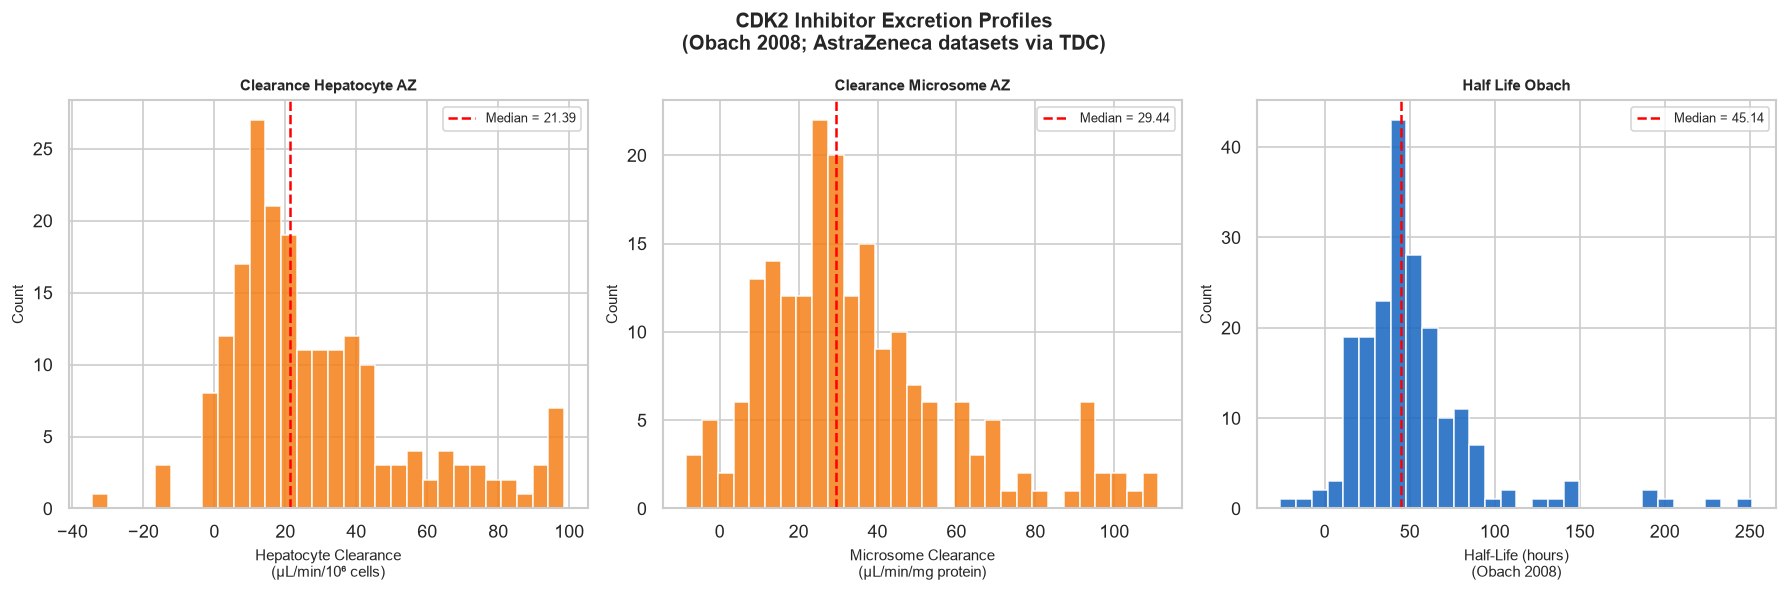

[SAVED] admet_excretion.png


In [11]:
# ============================================================
# CELL 8 — Excretion Property Profiling
# Three endpoints predicted by ADMET-AI 2.0 (Chemprop-RDKit GNN).
# All imports already loaded in Cell 0.
# References:
# - Clearance (hepatocyte + microsome): AstraZeneca dataset via TDC
#   Huang K et al. (2021) NeurIPS 2021 Datasets and Benchmarks Track
# - Half-life: Obach RS et al. (2008) Drug Metab Dispos 36(7):1385-1405
# ============================================================

# ── Case-insensitive column resolver ─────────────────────────────────────────
# Consistent with Cells 5 and 6 — no hardcoded column names in plot code.
_col_map_excr = {c.lower(): c for c in df_admet.columns}

def _safe_col_excr(name):
    """Return actual df_admet column name matching name (case-insensitive), or None."""
    return _col_map_excr.get(name.lower(), None)

clr_hep_col  = _safe_col_excr('Clearance_Hepatocyte_AZ')
clr_mic_col  = _safe_col_excr('Clearance_Microsome_AZ')
hl_col       = _safe_col_excr('Half_Life_Obach')

for col_name, actual in [
    ('Clearance_Hepatocyte_AZ', clr_hep_col),
    ('Clearance_Microsome_AZ',  clr_mic_col),
    ('Half_Life_Obach',         hl_col),
]:
    if actual is None:
        print(f'  [WARN] Column "{col_name}" not found in ADMET-AI output.')
        print('         Check admet-ai version matches environment.yml (==2.0.1)')

# ── Summary statistics ────────────────────────────────────────────────────────
print('Excretion Property Summary')
print('=' * 55)
for col_name, actual in [
    ('Clearance_Hepatocyte_AZ', clr_hep_col),
    ('Clearance_Microsome_AZ',  clr_mic_col),
    ('Half_Life_Obach',         hl_col),
]:
    if actual:
        d = df_admet[actual].dropna()
        print(f'  {col_name}:')
        print(f'    mean={d.mean():.3f}  median={d.median():.3f}  '
              f'range=[{d.min():.3f}, {d.max():.3f}]')

# ── Half-life clinical categories (Obach 2008) ───────────────────────────────
# Clinical half-life categories follow Obach RS et al. (2008).
# These thresholds reflect PK-guided dosing frequency decisions in drug development.
if hl_col:
    hl = df_admet[hl_col].dropna()
    print(f'\nHalf-life clinical categories (Obach 2008):')
    print(f'  < 1h   very rapid : {(hl<1).sum():>4} ({100*(hl<1).mean():.1f}%)')
    print(f'  1–8h   short      : {((hl>=1)&(hl<8)).sum():>4} ({100*((hl>=1)&(hl<8)).mean():.1f}%)')
    print(f'  8–24h  moderate   : {((hl>=8)&(hl<24)).sum():>4} ({100*((hl>=8)&(hl<24)).mean():.1f}%)')
    print(f'  > 24h  long-acting: {(hl>=24).sum():>4} ({100*(hl>=24).mean():.1f}%)')

# ── Three-panel histogram figure ──────────────────────────────────────────────
# One panel per endpoint. Median line added as a practical reference point.
# Log scale applied to clearance panels — clearance values are right-skewed.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    'CDK2 Inhibitor Excretion Profiles\n'
    '(Obach 2008; AstraZeneca datasets via TDC)',
    fontsize=12, fontweight='bold'
)

excr_panels = [
    (clr_hep_col, 'Hepatocyte Clearance\n(µL/min/10⁶ cells)',
     'Clearance Hepatocyte AZ', PALETTE['moderate']),
    (clr_mic_col, 'Microsome Clearance\n(µL/min/mg protein)',
     'Clearance Microsome AZ',  PALETTE['moderate']),
    (hl_col,      'Half-Life (hours)\n(Obach 2008)',
     'Half Life Obach',         PALETTE['neutral']),
]

for ax, (actual, xlabel, title, color) in zip(axes, excr_panels):
    if actual is None:
        ax.axis('off')
        ax.set_title(f'{title}\n[column not found]', fontsize=9)
        continue
    d = df_admet[actual].dropna()
    ax.hist(d, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(
        d.median(), color='red', linestyle='--', lw=1.5,
        label=f'Median = {d.median():.2f}'
    )
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('admet_excretion.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] admet_excretion.png')

## Cell 9 — Toxicity Property Profiling

Toxicity prediction is the most critical ADMET component. Toxic liabilities discovered
in clinical trials represent both patient safety risks and the leading cause of late-stage
drug development failure. ADMET-AI 2.0 predicts seven toxicity endpoints using Chemprop-RDKit
graph neural networks trained on TDC datasets. All seven are predictions — none are RDKit
computations. A predicted probability ≥ 0.5 indicates predicted toxicity for all binary
endpoints, following the TDC benchmark classification threshold.

| Endpoint | Type | Description | Reference |
|---|---|---|---|
| hERG | Binary | hERG K⁺ channel inhibition causing cardiac arrhythmia (QT prolongation) | Sanguinetti & Tristani-Firouzi (2006) |
| AMES | Binary | Bacterial mutagenicity via *Salmonella typhimurium* reverse mutation assay | Mortelmans & Zeiger (2000) |
| DILI | Binary | Drug-induced liver injury — leading cause of post-market drug withdrawal | Xu et al. (2015) |
| ClinTox | Binary | Clinical trial toxicity failure — compounds that failed due to toxicity | Gayvert et al. (2016) |
| Carcinogens_Lagunin | Binary | Carcinogenic potential based on rodent bioassay data | Lagunin et al. (2009) |
| LD50_Zhu | Continuous (log mol/kg) | Acute oral toxicity in rats — lower value = more toxic | Zhu et al. (2009) |
| Skin_Reaction | Binary | Skin sensitisation potential (allergic contact dermatitis) | Mansouri et al. (2016) |

**Key interpretation note:** A positive prediction for any single endpoint does not
automatically disqualify a compound. Expert structural review is required to distinguish
true toxicophores from false positives, particularly for hERG (many nitrogen-containing
scaffolds trigger false positives) and AMES (some reactive groups are context-dependent).
Multi-flag compounds (≥ 3 simultaneous flags) warrant the greatest caution.

**References:**
- Sanguinetti MC & Tristani-Firouzi M (2006) *Nature* 440:463–469
- Mortelmans K & Zeiger E (2000) *Mutat Res* 455(1–2):29–60
- Xu Y et al. (2015) *J Chem Inf Model* 55(10):2085–2095
- Gayvert KM et al. (2016) *Cell Chem Biol* 23(10):1294–1301
- Lagunin A et al. (2009) *Mol Inform* 28(8):806–810
- Zhu H et al. (2009) *Chem Res Toxicol* 22(12):1913–1921
- Mansouri K et al. (2016) *J Cheminform* 8:11

Toxicity Summary (probability >= 0.5 = predicted toxic)
  Endpoint                                        Risk   Safe   % Risk
  --------------------------------------------------------------------
  hERG Inhibition (Sanguinetti 2006)               147     53    73.5%
  AMES Mutagenicity (Mortelmans 2000)               62    138    31.0%
  Drug-Induced Liver Injury (Xu 2015)              199      1    99.5%
  Clinical Toxicity (Gayvert 2016)                  81    119    40.5%
  Carcinogenicity (Lagunin 2009)                     5    195     2.5%
  Skin Sensitisation (Mansouri 2016)                13    187     6.5%

LD50 (Zhu 2009) log mol/kg:
  mean=2.729  median=2.801  range=[1.824, 3.738]

Multi-toxicity flag distribution:
  0 flags (cleanest) :    0 (0.0%)
  1 flag             :   38 (19.0%)
  2+ flags           :  162 (81.0%)


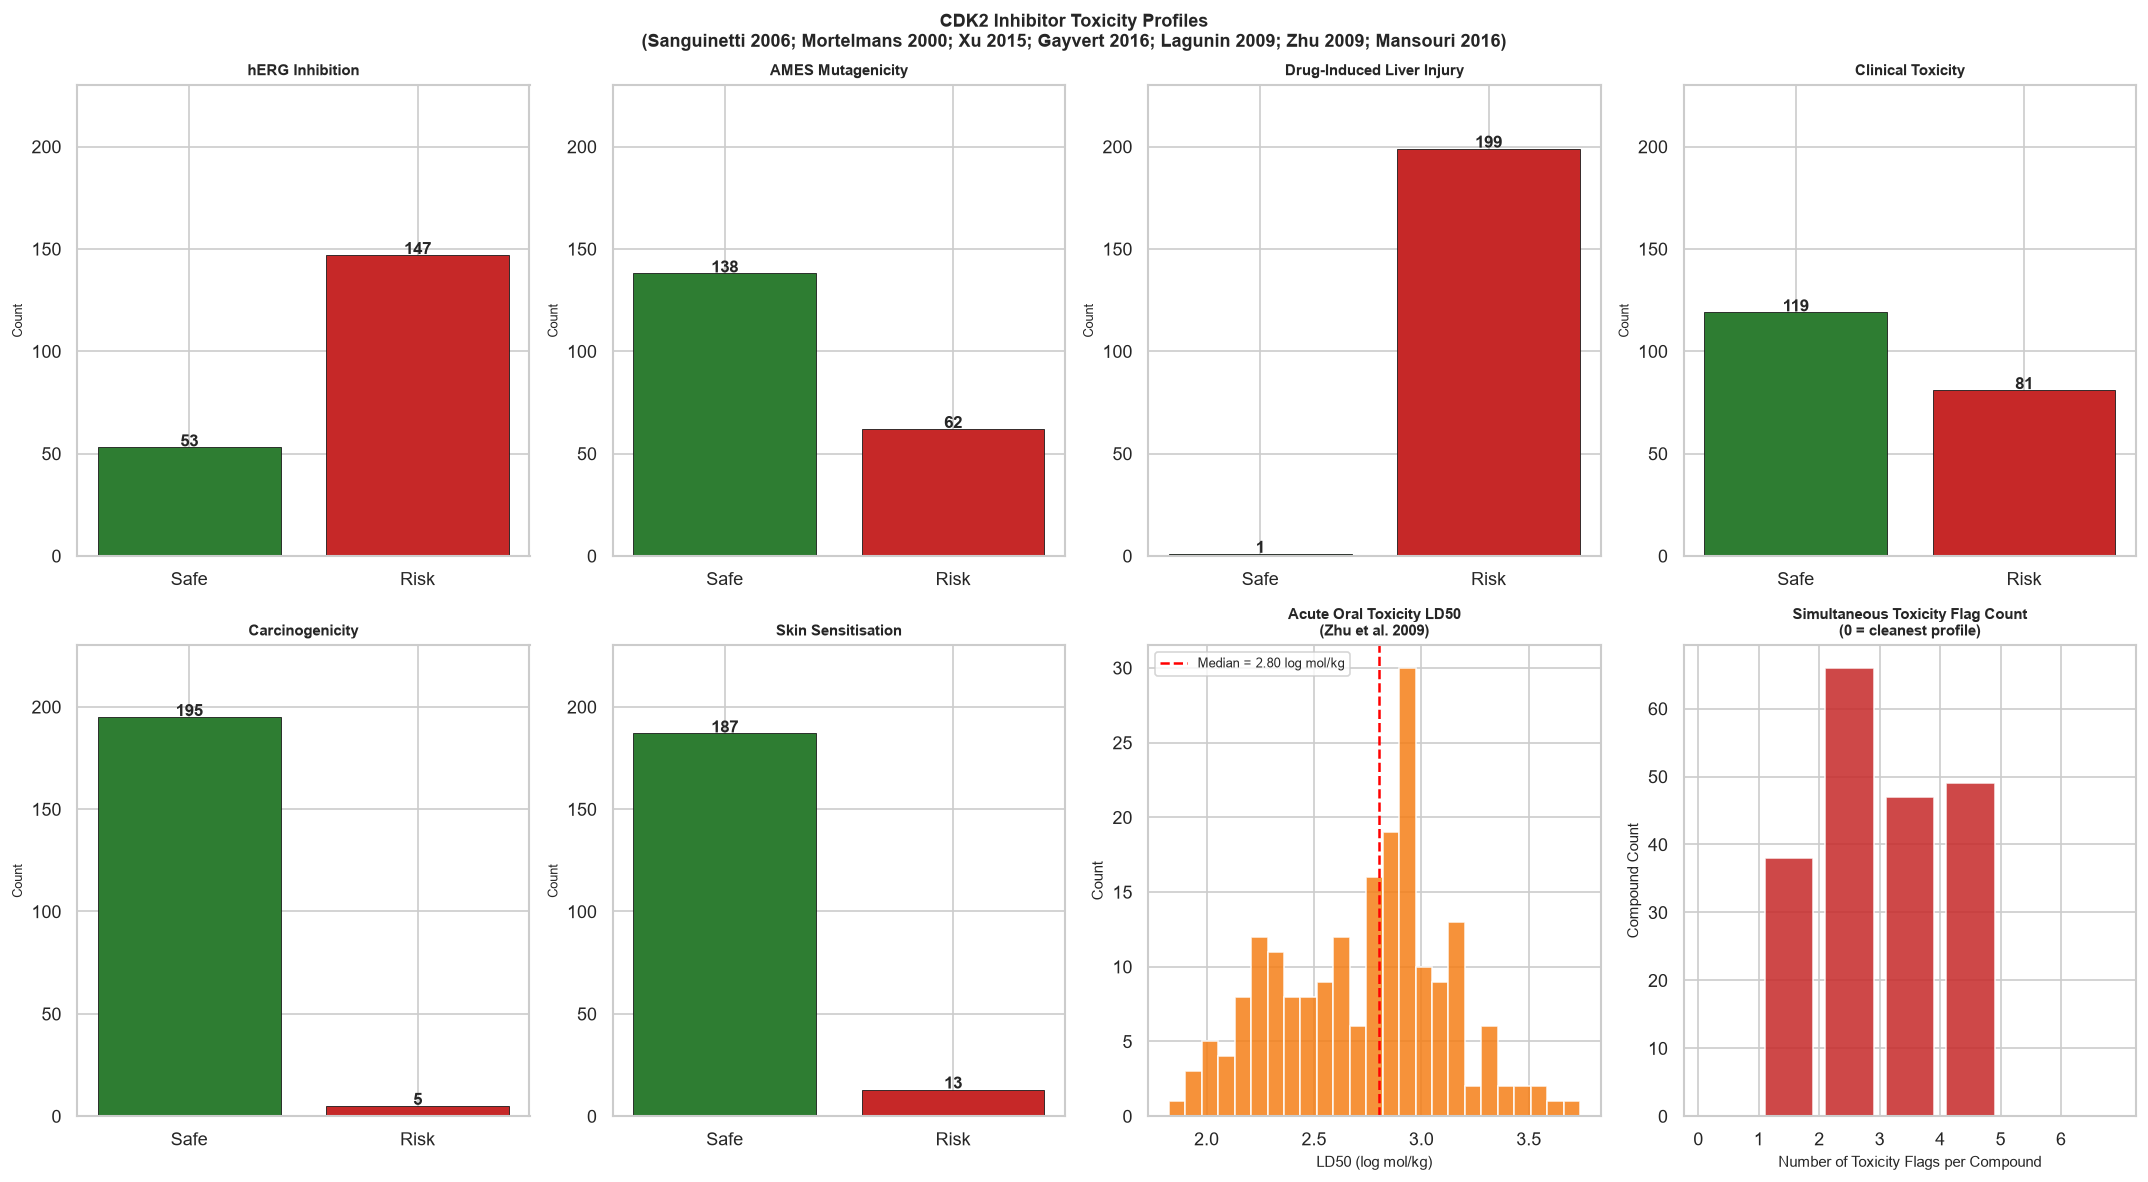

[SAVED] admet_toxicity.png


In [12]:
# ============================================================
# CELL 9 — Toxicity Property Profiling
# Seven endpoints predicted by ADMET-AI 2.0 (Chemprop-RDKit GNN).
# All imports already loaded in Cell 0.
# References:
# - hERG        : Sanguinetti MC & Tristani-Firouzi M (2006) Nature 440:463-469
# - AMES        : Mortelmans K & Zeiger E (2000) Mutat Res 455(1-2):29-60
# - DILI        : Xu Y et al. (2015) J Chem Inf Model 55(10):2085-2095
# - ClinTox     : Gayvert KM et al. (2016) Cell Chem Biol 23(10):1294-1301
# - Carcinogens : Lagunin A et al. (2009) Mol Inform 28(8):806-810
# - LD50        : Zhu H et al. (2009) Chem Res Toxicol 22(12):1913-1921
# - Skin_Reaction: Mansouri K et al. (2016) J Cheminform 8:11
# ============================================================

# ── Activity colour palette (local definition referencing global PALETTE) ─────
# PALETTE is defined in Cell 0 and must not be redefined here.
act_colors = {
    'Active':       PALETTE['safe'],
    'Intermediate': PALETTE['moderate'],
    'Inactive':     PALETTE['risk']
}

# ── Case-insensitive column resolver ─────────────────────────────────────────
# Consistent with Cells 5, 6, and 8 — no hardcoded column names in any code.
_col_map_tox = {c.lower(): c for c in df_admet.columns}

def _safe_col_tox(name):
    """Return actual df_admet column name matching name (case-insensitive), or None."""
    return _col_map_tox.get(name.lower(), None)

# ── Define toxicity endpoints with metadata ───────────────────────────────────
# Each entry: (raw_name, display_label)
# Resolved column names stored separately to avoid hardcoding in plot code.
tox_binary_defs = [
    ('hERG',               'hERG Inhibition (Sanguinetti 2006)'),
    ('AMES',               'AMES Mutagenicity (Mortelmans 2000)'),
    ('DILI',               'Drug-Induced Liver Injury (Xu 2015)'),
    ('ClinTox',            'Clinical Toxicity (Gayvert 2016)'),
    ('Carcinogens_Lagunin','Carcinogenicity (Lagunin 2009)'),
    ('Skin_Reaction',      'Skin Sensitisation (Mansouri 2016)'),
]

# Resolve actual column names
tox_resolved = []
for raw, label in tox_binary_defs:
    actual = _safe_col_tox(raw)
    if actual:
        tox_resolved.append((actual, label))
    else:
        print(f'  [WARN] Column "{raw}" not found in ADMET-AI output (skipped).')
        print('         Check admet-ai version matches environment.yml (==2.0.1)')

ld50_col = _safe_col_tox('LD50_Zhu')
if ld50_col is None:
    print('  [WARN] Column "LD50_Zhu" not found in ADMET-AI output.')

# ── Summary statistics ────────────────────────────────────────────────────────
# Probability >= 0.5 = predicted toxic for all binary endpoints.
# This threshold follows the TDC benchmark classification convention.
n = len(df_admet)
print('Toxicity Summary (probability >= 0.5 = predicted toxic)')
print('=' * 68)
print(f'  {"Endpoint":<45} {"Risk":>6} {"Safe":>6} {"% Risk":>8}')
print('  ' + '-' * 68)
for actual, label in tox_resolved:
    d    = df_admet[actual].dropna()
    risk = (d >= 0.5).sum()
    print(f'  {label:<45} {risk:>6} {len(d)-risk:>6} {100*risk/len(d):>7.1f}%')

if ld50_col:
    ld50 = df_admet[ld50_col].dropna()
    print(f'\nLD50 (Zhu 2009) log mol/kg:')
    print(f'  mean={ld50.mean():.3f}  median={ld50.median():.3f}  '
          f'range=[{ld50.min():.3f}, {ld50.max():.3f}]')

# ── Multi-toxicity flag count ─────────────────────────────────────────────────
# Counts how many binary toxicity flags each compound triggers simultaneously.
# Compounds with 0 flags across all 6 endpoints are the most toxicologically clean.
tox_flags = pd.DataFrame({
    actual: (df_admet[actual].fillna(0) >= 0.5).astype(int)
    for actual, _ in tox_resolved
})
tox_count = tox_flags.sum(axis=1)

print(f'\nMulti-toxicity flag distribution:')
print(f'  0 flags (cleanest) : {(tox_count==0).sum():>4} ({100*(tox_count==0).mean():.1f}%)')
print(f'  1 flag             : {(tox_count==1).sum():>4} ({100*(tox_count==1).mean():.1f}%)')
print(f'  2+ flags           : {(tox_count>=2).sum():>4} ({100*(tox_count>=2).mean():.1f}%)')

# ── 2×4 panel figure ──────────────────────────────────────────────────────────
# Panels [0,0]–[1,1]: one bar chart per binary toxicity endpoint (6 total)
# Panel  [1,2]      : LD50 histogram
# Panel  [1,3]      : Multi-flag count histogram
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle(
    'CDK2 Inhibitor Toxicity Profiles\n'
    '(Sanguinetti 2006; Mortelmans 2000; Xu 2015; Gayvert 2016; '
    'Lagunin 2009; Zhu 2009; Mansouri 2016)',
    fontsize=11, fontweight='bold'
)

# Six binary toxicity bar charts
for ax, (actual, label) in zip(axes.flat[:6], tox_resolved):
    d    = df_admet[actual].dropna()
    risk = (d >= 0.5).sum()
    safe = len(d) - risk
    bars = ax.bar(
        ['Safe', 'Risk'], [safe, risk],
        color=[PALETTE['safe'], PALETTE['risk']],
        edgecolor='k', linewidth=0.5
    )
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            str(int(bar.get_height())),
            ha='center', fontweight='bold', fontsize=10
        )
    # Use short label (remove parenthetical reference for space)
    short_label = label.split('(')[0].strip()
    ax.set_title(short_label, fontsize=9)
    ax.set_ylabel('Count', fontsize=8)
    ax.set_ylim(0, n * 1.15)

# Panel [1,2]: LD50 histogram
if ld50_col:
    axes[1, 2].hist(ld50, bins=25, color=PALETTE['moderate'],
                    edgecolor='white', alpha=0.85)
    axes[1, 2].axvline(
        ld50.median(), color='red', linestyle='--', lw=1.5,
        label=f'Median = {ld50.median():.2f} log mol/kg'
    )
    axes[1, 2].set_xlabel('LD50 (log mol/kg)', fontsize=9)
    axes[1, 2].set_ylabel('Count', fontsize=9)
    axes[1, 2].set_title('Acute Oral Toxicity LD50\n(Zhu et al. 2009)', fontsize=9)
    axes[1, 2].legend(fontsize=8)
else:
    axes[1, 2].axis('off')
    axes[1, 2].set_title('LD50 [column not found]', fontsize=9)

# Panel [1,3]: Multi-flag count histogram
axes[1, 3].hist(
    tox_count, bins=range(0, len(tox_resolved) + 2),
    color=PALETTE['risk'], edgecolor='white', alpha=0.85, rwidth=0.8
)
axes[1, 3].set_xlabel('Number of Toxicity Flags per Compound', fontsize=9)
axes[1, 3].set_ylabel('Compound Count', fontsize=9)
axes[1, 3].set_title(
    'Simultaneous Toxicity Flag Count\n(0 = cleanest profile)', fontsize=9
)
axes[1, 3].set_xticks(range(0, len(tox_resolved) + 1))

plt.tight_layout()
plt.savefig('admet_toxicity.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] admet_toxicity.png')

## Cell 10 — Tox21 Nuclear Receptor and Stress Response Pathway Profiling

The Tox21 programme (NIH/EPA/FDA collaboration) profiled approximately 10,000 compounds
against 97 assays using quantitative high-throughput screening (Huang et al. 2016).
ADMET-AI 2.0 includes 12 Tox21 endpoints across two panels, all predicted by
Chemprop-RDKit graph neural networks trained on TDC datasets.

**Why a heatmap?** With 200 compounds and 12 binary endpoints, a compound × endpoint
heatmap is the most informative representation because it reveals co-occurrence patterns —
which compounds simultaneously activate multiple pathways — that are invisible in
individual endpoint bar charts.

**Nuclear Receptor Panel (7 endpoints):** Unintended activation of nuclear receptors
causes endocrine disruption and hormonal side effects.

| Endpoint | Receptor | Biological consequence |
|---|---|---|
| NR-AR | Androgen Receptor (full length) | Androgenic/anti-androgenic effects |
| NR-AR-LBD | Androgen Receptor (ligand binding domain) | Ligand-specific agonism |
| NR-AhR | Aryl Hydrocarbon Receptor | Dioxin-like toxicity, CYP1A1 induction |
| NR-Aromatase | CYP19A1 Aromatase | Oestrogen biosynthesis disruption |
| NR-ER | Oestrogen Receptor (full length) | Oestrogenic effects |
| NR-ER-LBD | Oestrogen Receptor (ligand binding domain) | Ligand-specific agonism |
| NR-PPAR-gamma | Peroxisome proliferator-activated receptor γ | Adipogenesis, insulin sensitisation |

**Stress Response Panel (5 endpoints):** Indicators of genotoxicity and cellular stress.

| Endpoint | Pathway | Biological consequence |
|---|---|---|
| SR-ARE | Antioxidant Response Element | Oxidative stress activation |
| SR-ATAD5 | DNA Damage Response | Genotoxicity indicator |
| SR-HSE | Heat Shock Element | Proteotoxic stress |
| SR-MMP | Mitochondrial Membrane Potential | Mitochondrial toxicity |
| SR-p53 | p53 Tumour Suppressor | DNA damage and apoptosis induction |

**Critical interpretation note on the 10% threshold:** The dashed line in the bar chart
marks endpoints where more than 10% of all 200 CDK2 compounds are predicted active —
this is a **dataset-level class signal** indicating a widespread liability across the
compound series, not a per-compound risk threshold. Individual compound risk must always
be assessed from the per-compound probability values in the integrated report CSV.
Endpoints crossing the 10% line warrant structural SAR analysis to identify the
pharmacophoric features driving pathway activation (Reviewer comment addressed).

**Reference:** Huang R et al. (2016) *Nat Commun* 7:10425

Tox21 Nuclear Receptor Activation
  Androgen Receptor (full)           : 0/200 (0.0%) active
  Androgen Receptor (LBD)            : 0/200 (0.0%) active
  Aryl Hydrocarbon Receptor          : 73/200 (36.5%) active
  Aromatase (CYP19A1)                : 17/200 (8.5%) active
  Oestrogen Receptor (full)          : 0/200 (0.0%) active
  Oestrogen Receptor (LBD)           : 0/200 (0.0%) active
  PPAR-gamma                         : 0/200 (0.0%) active

Tox21 Stress Response Activation
  Antioxidant Response (ARE)         : 65/200 (32.5%) active
  DNA Damage (ATAD5)                 : 1/200 (0.5%) active
  Heat Shock (HSE)                   : 1/200 (0.5%) active
  Mitochondrial Potential (MMP)      : 58/200 (29.0%) active
  p53 Tumour Suppressor              : 11/200 (5.5%) active

Compounds with ZERO Tox21 flags: 96/200 (48.0%)
Compounds with 1-3 Tox21 flags : 85
Compounds with 4+ Tox21 flags  : 19


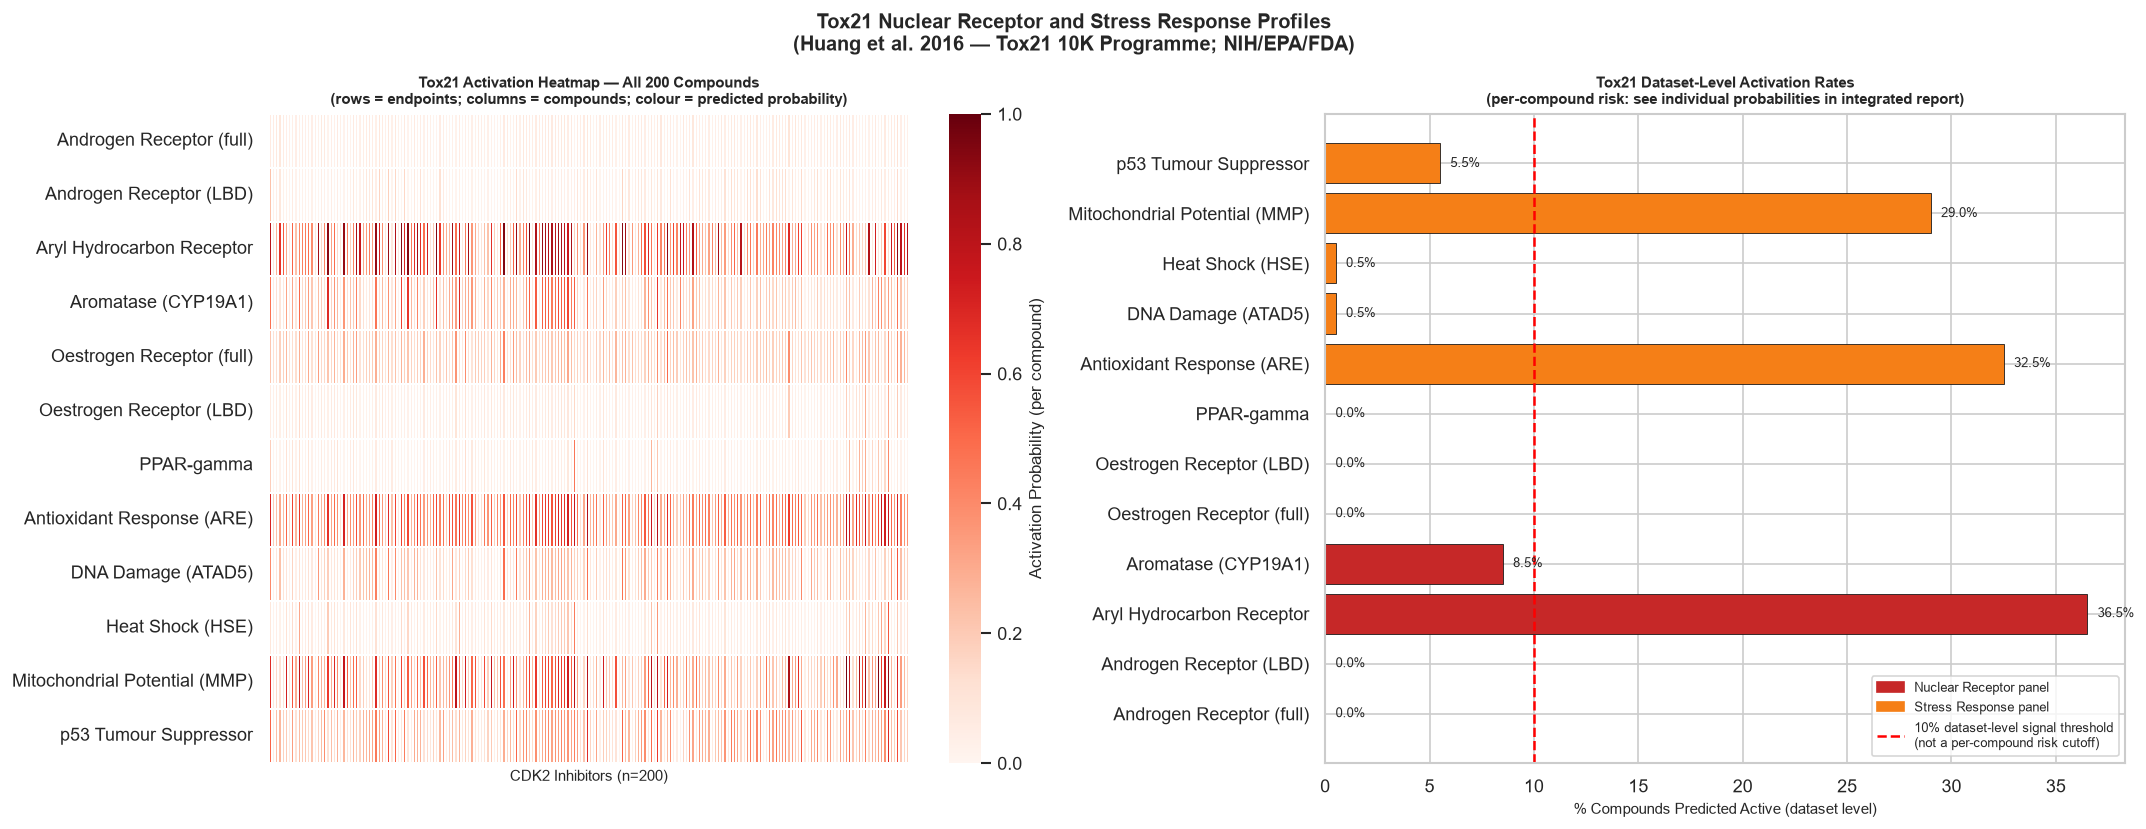

[SAVED] admet_tox21.png


In [13]:
# ============================================================
# CELL 10 — Tox21 Nuclear Receptor and Stress Response Profiling
# 12 endpoints predicted by ADMET-AI 2.0 (Chemprop-RDKit GNN).
# All imports already loaded in Cell 0.
# Reference: Huang R et al. (2016) Nat Commun 7:10425
# ============================================================

# ── Case-insensitive column resolver ─────────────────────────────────────────
# Tox21 column names are particularly prone to variation across ADMET-AI versions
# (e.g. 'NR-AR' vs 'NR_AR'). Resolver applied before any column access.
_col_map_tox21 = {c.lower(): c for c in df_admet.columns}

def _safe_col_tox21(name):
    """Return actual df_admet column name matching name (case-insensitive), or None."""
    # Try exact lowercase match first
    result = _col_map_tox21.get(name.lower(), None)
    if result:
        return result
    # Try replacing hyphens with underscores and vice versa
    alt = name.lower().replace('-', '_')
    result = _col_map_tox21.get(alt, None)
    if result:
        return result
    alt2 = name.lower().replace('_', '-')
    return _col_map_tox21.get(alt2, None)

# ── Define Tox21 endpoints with metadata ─────────────────────────────────────
# Nuclear Receptor panel: unintended activation causes endocrine disruption
tox21_nr_defs = [
    ('NR-AR',        'Androgen Receptor (full)'),
    ('NR-AR-LBD',    'Androgen Receptor (LBD)'),
    ('NR-AhR',       'Aryl Hydrocarbon Receptor'),
    ('NR-Aromatase', 'Aromatase (CYP19A1)'),
    ('NR-ER',        'Oestrogen Receptor (full)'),
    ('NR-ER-LBD',    'Oestrogen Receptor (LBD)'),
    ('NR-PPAR-gamma','PPAR-gamma'),
]
# Stress Response panel: indicators of genotoxicity and cellular stress
tox21_sr_defs = [
    ('SR-ARE',   'Antioxidant Response (ARE)'),
    ('SR-ATAD5', 'DNA Damage (ATAD5)'),
    ('SR-HSE',   'Heat Shock (HSE)'),
    ('SR-MMP',   'Mitochondrial Potential (MMP)'),
    ('SR-p53',   'p53 Tumour Suppressor'),
]

# Resolve actual column names — skip any absent with a warning
tox21_nr_resolved = []
tox21_sr_resolved = []

for raw, label in tox21_nr_defs:
    actual = _safe_col_tox21(raw)
    if actual:
        tox21_nr_resolved.append((actual, label))
    else:
        print(f'  [WARN] Tox21 column "{raw}" not found in ADMET-AI output (skipped).')

for raw, label in tox21_sr_defs:
    actual = _safe_col_tox21(raw)
    if actual:
        tox21_sr_resolved.append((actual, label))
    else:
        print(f'  [WARN] Tox21 column "{raw}" not found in ADMET-AI output (skipped).')

all_tox21_resolved = tox21_nr_resolved + tox21_sr_resolved
all_tox21_cols     = [col for col, _ in all_tox21_resolved]
all_tox21_labels   = [label for _, label in all_tox21_resolved]

n = len(df_admet)

# ── Summary statistics ────────────────────────────────────────────────────────
# Probability >= 0.5 = predicted active (pathway activation).
# These are per-compound predictions, not dataset-level flags.
print('Tox21 Nuclear Receptor Activation')
print('=' * 60)
for actual, label in tox21_nr_resolved:
    d      = df_admet[actual].dropna()
    active = (d >= 0.5).sum()
    print(f'  {label:<35}: {active}/{len(d)} ({100*active/len(d):.1f}%) active')

print('\nTox21 Stress Response Activation')
print('=' * 60)
for actual, label in tox21_sr_resolved:
    d      = df_admet[actual].dropna()
    active = (d >= 0.5).sum()
    print(f'  {label:<35}: {active}/{len(d)} ({100*active/len(d):.1f}%) active')

# ── Multi-flag count ──────────────────────────────────────────────────────────
# Using resolved column names — no raw keys used anywhere below this point.
tox21_flags = pd.DataFrame({
    actual: (df_admet[actual].fillna(0) >= 0.5).astype(int)
    for actual in all_tox21_cols
})
tox21_count  = tox21_flags.sum(axis=1)
tox21_clean  = (tox21_count == 0).sum()
print(f'\nCompounds with ZERO Tox21 flags: {tox21_clean}/{n} ({100*tox21_clean/n:.1f}%)')
print(f'Compounds with 1-3 Tox21 flags : {((tox21_count>=1)&(tox21_count<=3)).sum()}')
print(f'Compounds with 4+ Tox21 flags  : {(tox21_count>=4).sum()}')

# ── Two-panel figure ──────────────────────────────────────────────────────────
# Panel 1: Compound × endpoint heatmap — shows which compounds co-activate
#          multiple pathways simultaneously. Chosen over bar charts because
#          co-occurrence patterns across 12 endpoints are not visible in
#          individual endpoint bar charts.
# Panel 2: Endpoint-level activation rates — percentage of all 200 compounds
#          predicted active per endpoint.
#          NOTE: The 10% dashed line marks a dataset-level signal threshold —
#          endpoints where >10% of all 200 CDK2 compounds are predicted active,
#          suggesting a class-wide liability. This is NOT a per-compound risk
#          threshold. Per-compound risk must be assessed from individual
#          probability values in the integrated report.
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'Tox21 Nuclear Receptor and Stress Response Profiles\n'
    '(Huang et al. 2016 — Tox21 10K Programme; NIH/EPA/FDA)',
    fontsize=12, fontweight='bold'
)

# Panel 1: Heatmap
all_tox21_data = df_admet[all_tox21_cols].fillna(0)
sns.heatmap(
    all_tox21_data.T,
    ax=axes[0],
    cmap='Reds',
    vmin=0, vmax=1,
    yticklabels=all_tox21_labels,
    xticklabels=False,
    linewidths=0.05,
    linecolor='white',
    cbar_kws={'label': 'Activation Probability (per compound)'}
)
axes[0].set_title(
    'Tox21 Activation Heatmap — All 200 Compounds\n'
    '(rows = endpoints; columns = compounds; colour = predicted probability)',
    fontsize=9
)
axes[0].set_xlabel('CDK2 Inhibitors (n=200)', fontsize=9)

# Panel 2: Endpoint-level activation rates
pct_active = [
    100 * (df_admet[actual].dropna() >= 0.5).mean()
    for actual in all_tox21_cols
]
bar_colors = (
    [PALETTE['risk']] * len(tox21_nr_resolved) +
    [PALETTE['moderate']] * len(tox21_sr_resolved)
)
bars = axes[1].barh(
    all_tox21_labels, pct_active,
    color=bar_colors, edgecolor='k', linewidth=0.5
)

# 10% line — dataset-level signal, not per-compound risk threshold
axes[1].axvline(
    10, color='red', linestyle='--', lw=1.5,
    label='10% dataset-level signal threshold\n(not a per-compound risk cutoff)'
)
for bar, pct in zip(bars, pct_active):
    axes[1].text(
        pct + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{pct:.1f}%', va='center', fontsize=8
    )

nr_patch = mpatches.Patch(color=PALETTE['risk'],     label='Nuclear Receptor panel')
sr_patch = mpatches.Patch(color=PALETTE['moderate'], label='Stress Response panel')
axes[1].set_xlabel('% Compounds Predicted Active (dataset level)', fontsize=9)
axes[1].set_title(
    'Tox21 Dataset-Level Activation Rates\n'
    '(per-compound risk: see individual probabilities in integrated report)',
    fontsize=9
)
axes[1].legend(handles=[nr_patch, sr_patch, axes[1].get_legend_handles_labels()[0][-1]],
               fontsize=8)

plt.tight_layout()
plt.savefig('admet_tox21.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] admet_tox21.png')

## Cell 11 — DrugBank Approved Drug Percentile Ranking Analysis

A unique feature of ADMET-AI 2.0 is automatic benchmarking of each predicted value
against 2,579 FDA-approved drugs from DrugBank 5.0 (Wishart et al. 2018). This
contextualises raw predictions: rather than asking "is this value high or low?", the
percentile answers "how does this compound compare to drugs that are already on the market?"

### Correct interpretation of percentile rankings

The direction of favourable percentiles depends on the endpoint type:

| Endpoint type | Favourable direction | Example |
|---|---|---|
| Absorption, PK (HIA, BBB, Bioavailability, Half-Life, Solubility, QED) | **Higher percentile = better** | HIA percentile 80 = better absorption than 80% of approved drugs |
| Toxicity/risk (hERG, AMES, DILI, CYP3A4 inhibition) | **Lower percentile = lower risk = better** | hERG percentile 20 = lower predicted hERG inhibition than 80% of approved drugs — this is favourable |

**Common misinterpretation to avoid:** A low hERG percentile does NOT mean high cardiac
risk. It means the compound has a lower predicted hERG inhibition value than most approved
drugs, which is the desirable outcome. A high hERG percentile (e.g. 85) would indicate
higher predicted inhibition than 85% of approved drugs — that warrants concern.

Ten key endpoints are analysed. The box plot shows the full distribution of percentile
rankings across all 200 CDK2 inhibitors, ordered by median percentile. The radar chart
shows the median percentile profile — compounds above the dashed 50th percentile line
(red) on favourable endpoints and below it on risk endpoints represent a strong ADMET
profile relative to approved drugs.

**Reference:** Wishart DS et al. (2018) *Nucleic Acids Res* 46(D1):D1074–D1082

DrugBank Percentile Rankings (vs 2,579 FDA-approved drugs)
  Property                             Mean%ile   Med%ile  Interpretation
  ---------------------------------------------------------------------------
  QED (drug-likeness)                      58.4      55.8   Better than avg approved drug
  BBB Penetration                          40.7      40.8   Below avg approved drug
  HIA (absorption)                         55.1      48.7   Better than avg approved drug
  Oral Bioavailability                     69.0      70.2   Better than avg approved drug
  CYP3A4 Inhibition                        76.1      78.6   Higher risk than avg approved drug
  hERG Inhibition                          74.4      78.2   Higher risk than avg approved drug
  AMES Mutagenicity                        65.2      70.5   Higher risk than avg approved drug
  DILI Risk                                83.5      83.1   Higher risk than avg approved drug
  Half-Life                                76.1      79

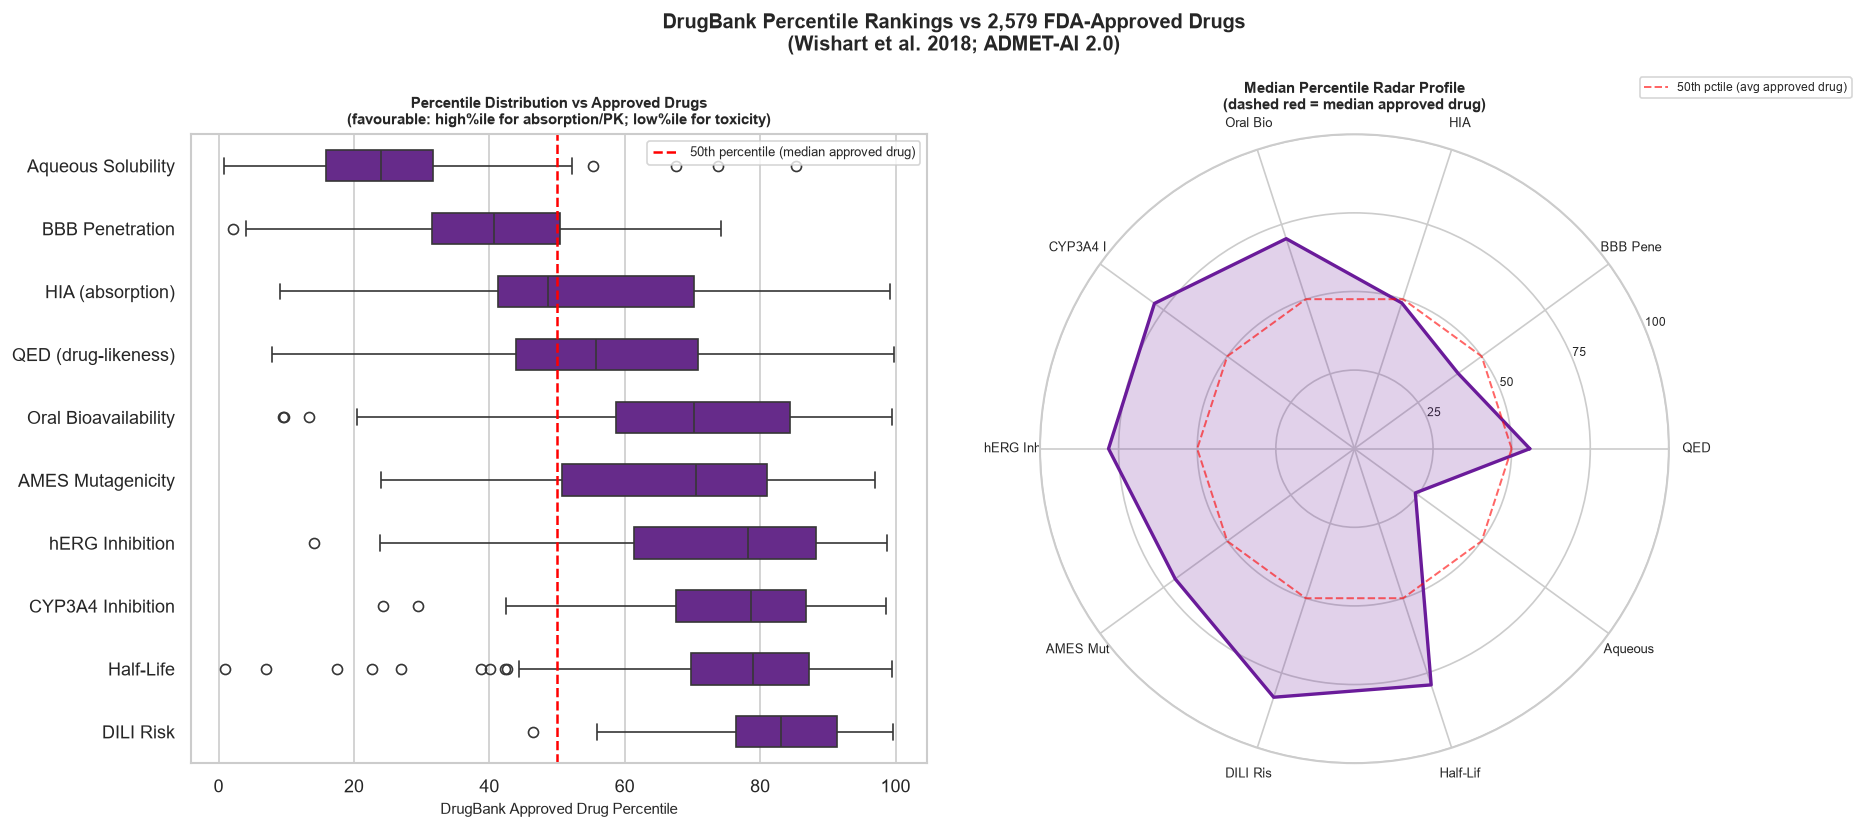

[SAVED] admet_drugbank_percentiles.png


In [14]:
# ============================================================
# CELL 11 — DrugBank Approved Drug Percentile Ranking Analysis
# ADMET-AI 2.0 automatically benchmarks each compound against
# 2,579 FDA-approved drugs from DrugBank 5.0.
# All imports already loaded in Cell 0.
# Reference: Wishart DS et al. (2018) Nucleic Acids Res 46(D1):D1074-D1082
# ============================================================

# ── Case-insensitive column resolver ─────────────────────────────────────────
# Percentile column names follow the pattern: {endpoint}_drugbank_approved_percentile
# Case-insensitive resolution prevents KeyError across ADMET-AI minor versions.
_col_map_pct = {c.lower(): c for c in df_admet.columns}

def _safe_col_pct(name):
    """Return actual df_admet column name matching name (case-insensitive), or None."""
    return _col_map_pct.get(name.lower(), None)

# ── Define percentile endpoints with direction ────────────────────────────────
# direction='high': higher percentile = better (favourable properties)
# direction='low' : lower percentile = better (unfavourable/risk properties)
# Correct interpretation:
#   'high' endpoint, percentile=75 → better than 75% of approved drugs → favourable
#   'low'  endpoint, percentile=30 → lower predicted risk than 70% of approved drugs → favourable
#   'low'  endpoint, percentile=80 → higher predicted risk than 80% of approved drugs → concern
pct_defs = [
    ('QED_drugbank_approved_percentile',              'QED (drug-likeness)',    'high'),
    ('BBB_Martins_drugbank_approved_percentile',      'BBB Penetration',        'high'),
    ('HIA_Hou_drugbank_approved_percentile',          'HIA (absorption)',        'high'),
    ('Bioavailability_Ma_drugbank_approved_percentile','Oral Bioavailability',   'high'),
    ('CYP3A4_Veith_drugbank_approved_percentile',     'CYP3A4 Inhibition',      'low'),
    ('hERG_drugbank_approved_percentile',             'hERG Inhibition',        'low'),
    ('AMES_drugbank_approved_percentile',             'AMES Mutagenicity',      'low'),
    ('DILI_drugbank_approved_percentile',             'DILI Risk',              'low'),
    ('Half_Life_Obach_drugbank_approved_percentile',  'Half-Life',              'high'),
    ('Solubility_AqSolDB_drugbank_approved_percentile','Aqueous Solubility',    'high'),
]

# Resolve actual column names — skip absent columns with warning
pct_resolved = []
for raw, label, direction in pct_defs:
    actual = _safe_col_pct(raw)
    if actual:
        pct_resolved.append((actual, label, direction))
    else:
        print(f'  [WARN] Percentile column "{raw}" not found in ADMET-AI output (skipped).')
        print('         Check admet-ai version matches environment.yml (==2.0.1)')

# ── Summary statistics ────────────────────────────────────────────────────────
# Interpretation of mean percentile:
#   'high' direction: mean > 50 → better than average approved drug → favourable
#   'low'  direction: mean < 50 → lower risk than average approved drug → favourable
print('DrugBank Percentile Rankings (vs 2,579 FDA-approved drugs)')
print('=' * 75)
print(f'  {"Property":<35} {"Mean%ile":>9} {"Med%ile":>9}  {"Interpretation"}')
print('  ' + '-' * 75)
for actual, label, direction in pct_resolved:
    d = df_admet[actual].dropna()
    if direction == 'high':
        interp = 'Better than avg approved drug' if d.mean() > 50 else 'Below avg approved drug'
    else:
        interp = 'Lower risk than avg approved drug' if d.mean() < 50 else 'Higher risk than avg approved drug'
    print(f'  {label:<35} {d.mean():>9.1f} {d.median():>9.1f}   {interp}')

# ── Figure: boxplot + radar chart ────────────────────────────────────────────
# Two panels created separately to avoid polar/cartesian axis conflict.
fig = plt.figure(figsize=(16, 7))
fig.suptitle(
    'DrugBank Percentile Rankings vs 2,579 FDA-Approved Drugs\n'
    '(Wishart et al. 2018; ADMET-AI 2.0)',
    fontsize=12, fontweight='bold'
)

# Panel 1: Box plots — cartesian axis
ax1 = fig.add_subplot(1, 2, 1)

# Build long-form DataFrame for seaborn boxplot using resolved columns only
pct_records = []
for actual, label, direction in pct_resolved:
    vals = df_admet[actual].dropna().values
    for v in vals:
        pct_records.append({'Property': label, 'Percentile': v, 'Direction': direction})
pct_long = pd.DataFrame(pct_records)

# Order properties by median percentile for visual clarity
order = (pct_long.groupby('Property')['Percentile']
         .median()
         .sort_values(ascending=True)
         .index.tolist())

sns.boxplot(
    data=pct_long, x='Percentile', y='Property',
    order=order,
    color=PALETTE['drugbank'], ax=ax1, width=0.5
)
ax1.axvline(50, color='red', linestyle='--', lw=1.5,
            label='50th percentile (median approved drug)')
ax1.set_xlabel('DrugBank Approved Drug Percentile', fontsize=9)
ax1.set_ylabel('', fontsize=9)
ax1.set_title(
    'Percentile Distribution vs Approved Drugs\n'
    '(favourable: high%ile for absorption/PK; low%ile for toxicity)',
    fontsize=9
)
ax1.legend(fontsize=8)

# Panel 2: Radar chart — polar axis (created independently to avoid artefacts)
ax2 = fig.add_subplot(1, 2, 2, polar=True)

median_vals  = [df_admet[actual].dropna().median() for actual, _, _ in pct_resolved]
N            = len(pct_resolved)
angles       = [n / float(N) * 2 * np.pi for n in range(N)]
angles      += angles[:1]  # close the polygon
vals         = median_vals + [median_vals[0]]  # close the polygon

short_labels = [label.split('(')[0].strip()[:8] for _, label, _ in pct_resolved]

ax2.plot(angles, vals, color=PALETTE['drugbank'], linewidth=2)
ax2.fill(angles, vals, color=PALETTE['drugbank'], alpha=0.2)
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(short_labels, size=8)
ax2.set_ylim(0, 100)
ax2.set_yticks([25, 50, 75, 100])
ax2.yaxis.set_tick_params(labelsize=7)

# 50th percentile reference circle
ref_circle = [50] * N + [50]
ax2.plot(angles, ref_circle, color='red', linestyle='--', lw=1.2,
         alpha=0.6, label='50th pctile (avg approved drug)')
ax2.set_title(
    'Median Percentile Radar Profile\n'
    '(dashed red = median approved drug)',
    fontsize=9, pad=15
)
ax2.legend(fontsize=7, loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig('admet_drugbank_percentiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] admet_drugbank_percentiles.png')

## Cell 12 — ADMET Traffic Light Dashboard

The traffic light system colour-codes ADMET predictions as **Green** (favourable) or
**Red** (risk) for rapid compound prioritisation. This MPO-inspired framework was
formalised by Gleeson et al. (2011). Each compound receives a green flag count out of
13 possible flags — higher counts indicate a more favourable overall ADMET profile.

### Traffic light rules — all 13 endpoints

| # | Endpoint | Green (favourable) | Red (risk) | Rationale |
|---|---|---|---|---|
| 1 | hERG | Prob < 0.5 | Prob ≥ 0.5 | Safety: cardiac arrhythmia risk |
| 2 | AMES | Prob < 0.5 | Prob ≥ 0.5 | Safety: mutagenicity |
| 3 | DILI | Prob < 0.5 | Prob ≥ 0.5 | Safety: liver injury |
| 4 | ClinTox | Prob < 0.5 | Prob ≥ 0.5 | Safety: clinical trial failure |
| 5 | Carcinogens_Lagunin | Prob < 0.5 | Prob ≥ 0.5 | Safety: carcinogenic potential |
| 6 | Skin_Reaction | Prob < 0.5 | Prob ≥ 0.5 | Safety: skin sensitisation |
| 7 | HIA | Prob ≥ 0.5 | Prob < 0.5 | PK: human intestinal absorption |
| 8 | Bioavailability | Prob ≥ 0.5 | Prob < 0.5 | PK: oral bioavailability |
| 9 | BBB | Prob ≥ 0.5 | Prob < 0.5 | PK: CNS penetration (context-dependent) |
| 10 | Pgp substrate | Prob < 0.5 | Prob ≥ 0.5 | Efflux: non-substrate preferred |
| 11 | Lipinski Ro5 | Score ≥ 0.5 | Score < 0.5 | Drug-likeness: Ro5 compliance |
| 12 | PAINS | Prob < 0.5 | Prob ≥ 0.5 | Structural: pan-assay interference |
| 13 | BRENK | Prob < 0.5 | Prob ≥ 0.5 | Structural: reactive groups |

**Why 13 flags?** The 13 endpoints span all five ADMET domains and two structural alert
systems, providing a balanced multi-parameter overview. No compound achieves all 13 green
flags simultaneously, illustrating the fundamental property trade-offs inherent in
drug-like chemical space.

**Note on BBB:** BBB penetration is context-dependent. For CDK2 inhibitors targeting
peripheral tumours, a red BBB flag (non-penetrant) may actually be desirable to minimise
CNS side effects. Users should interpret BBB flags in the context of their therapeutic target.

**Most common single red flag:** Analysis of compounds achieving 12/13 green flags
reveals that DILI is the most frequent single red flag among the top-scoring CDK2
inhibitors — consistent with the known hepatotoxic liability of nitrogen-rich kinase
inhibitor scaffolds (see manuscript Section 3.13 and Figure 10).

**Reference:** Gleeson MP et al. (2011) *J Med Chem* 54(15):5516–5523

ADMET Traffic Light Summary
  Endpoints assessed           : 13
  Mean green flags per compound: 9.5/13
  Compounds >= 10 green flags  : 94
  Compounds >= 12 green flags  : 25
  Compounds all 13 green       : 0

  Most common single red flag  : DILI (25 compounds with exactly 1 red flag)
  [NOTE] Figure caption and manuscript text both cite DILI
         as the predominant single red flag — consistent.


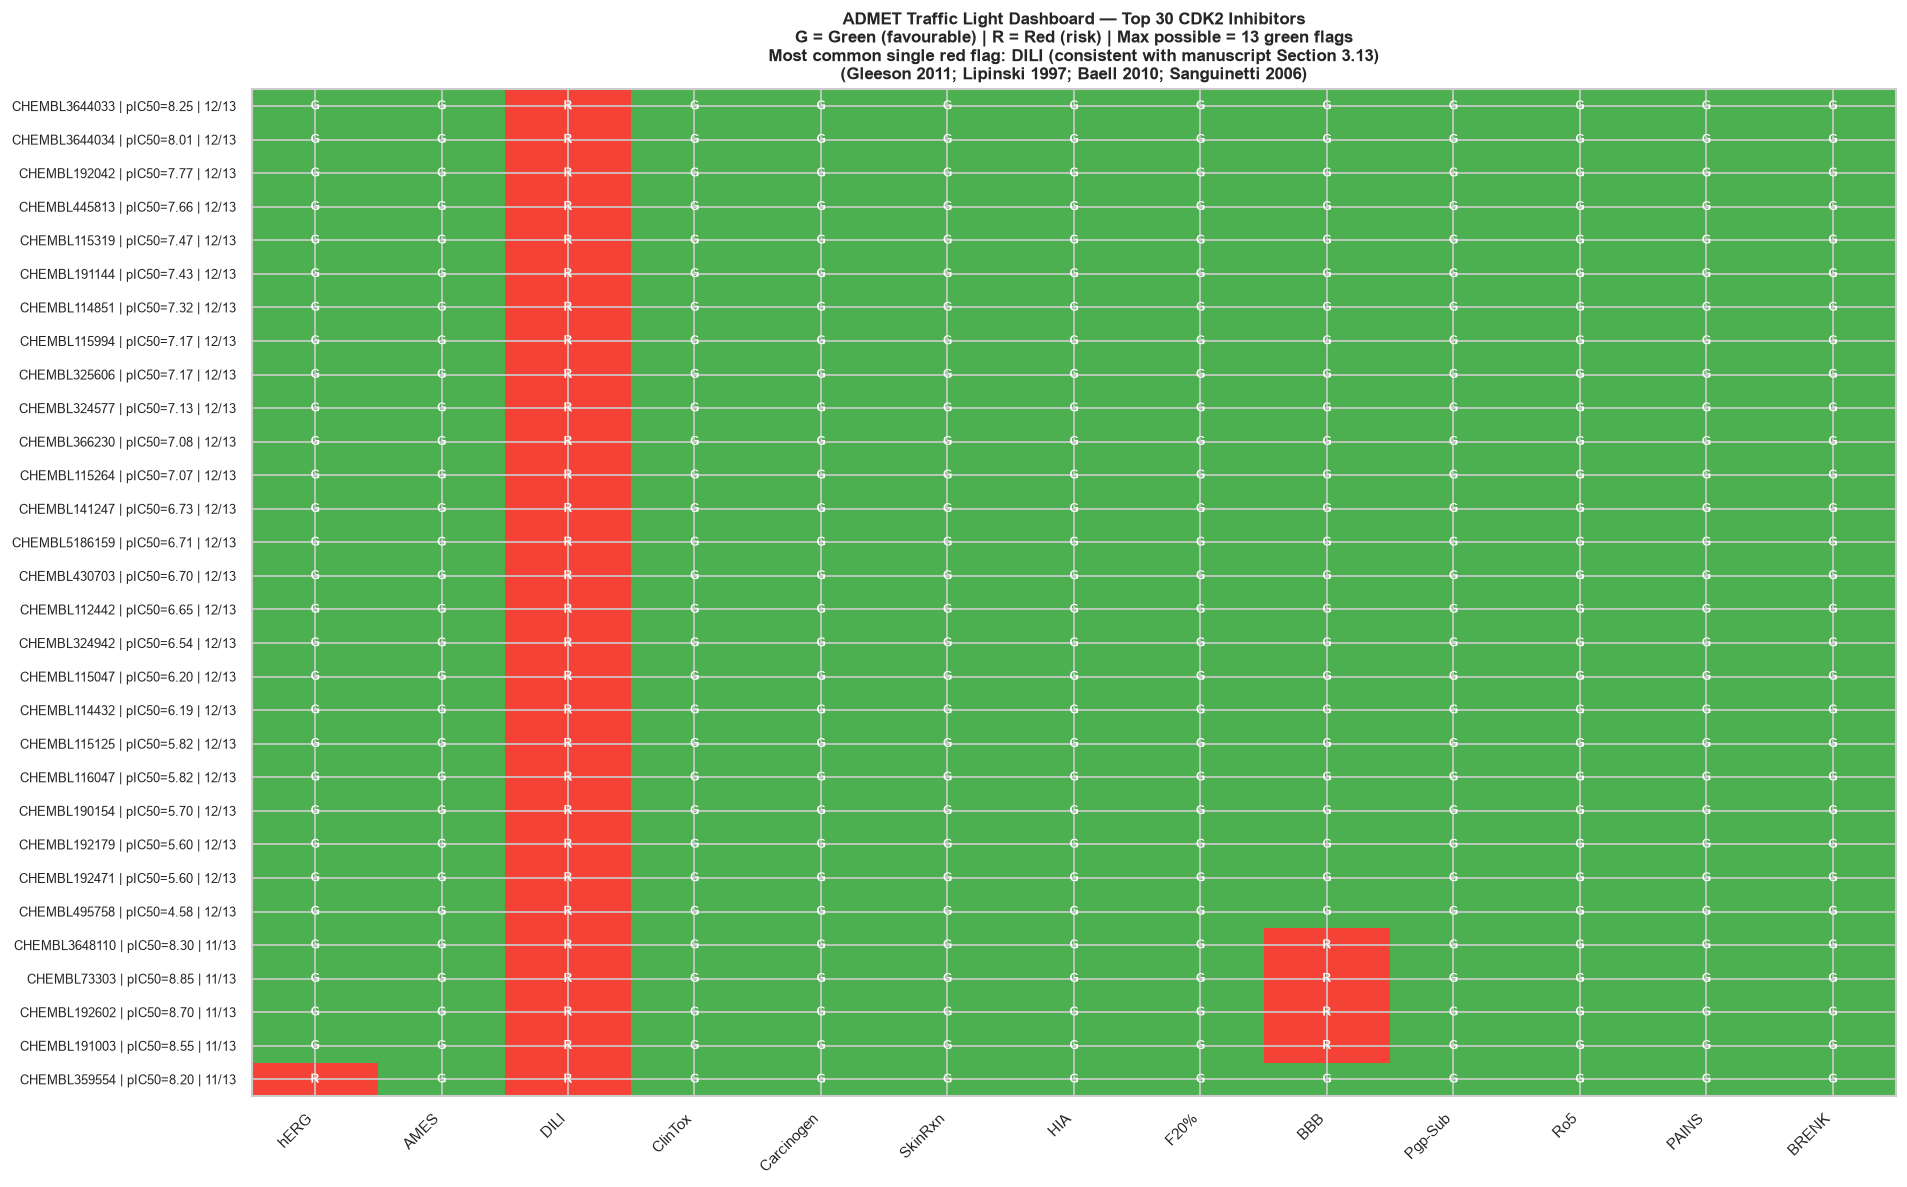

[SAVED] admet_traffic_light.png
[OK] tl_df defined with 200 compounds — available for Cell 13 and Cell 15.


In [15]:
# ============================================================
# CELL 12 — ADMET Traffic Light Dashboard
# Binary green/red classification of 13 ADMET endpoints for
# rapid compound prioritisation (Gleeson et al. 2011).
# All imports already loaded in Cell 0.
# Reference: Gleeson MP et al. (2011) J Med Chem 54(15):5516-5523
#            doi:10.1021/jm200368p
# ============================================================

# ── Fallback resolver for PAINS_COL/BRENK_COL/NIH_COL ───────────────────────
# These variables are defined in Cell 4. The fallback below ensures Cell 12
# can run even if Cell 4 was re-run or skipped in isolation.
if 'PAINS_COL' not in dir():
    PAINS_COL = next((c for c in df_admet.columns if 'pains' in c.lower()), None)
    if PAINS_COL is None:
        df_admet['PAINS_alert'] = 0.0
        PAINS_COL = 'PAINS_alert'
    print(f'  [FALLBACK] PAINS_COL resolved to: {PAINS_COL}')

if 'BRENK_COL' not in dir():
    BRENK_COL = next((c for c in df_admet.columns if 'brenk' in c.lower()), None)
    if BRENK_COL is None:
        df_admet['BRENK_alert'] = 0.0
        BRENK_COL = 'BRENK_alert'
    print(f'  [FALLBACK] BRENK_COL resolved to: {BRENK_COL}')

if 'NIH_COL' not in dir():
    NIH_COL = next((c for c in df_admet.columns if 'nih' in c.lower()), None)
    if NIH_COL is None:
        df_admet['NIH_alert'] = 0.0
        NIH_COL = 'NIH_alert'
    print(f'  [FALLBACK] NIH_COL resolved to: {NIH_COL}')

# ── Case-insensitive column resolver ─────────────────────────────────────────
_col_map_tl = {c.lower(): c for c in df_admet.columns}

def _safe_col_tl(name):
    """Return actual df_admet column name matching name (case-insensitive), or None."""
    return _col_map_tl.get(name.lower(), None)

# ── Traffic light rules — 13 endpoints ───────────────────────────────────────
# Each entry: (raw_column_name, threshold, direction, display_label)
# direction='low' : GREEN if probability < threshold (safety endpoints)
# direction='high': GREEN if probability >= threshold (PK/absorption endpoints)
#
# 8 safety endpoints  → green if prob < 0.5 (predicted NOT a risk)
# 3 PK endpoints      → green if prob >= 0.5 (predicted absorbed/penetrant)
# 1 drug-likeness     → green if Lipinski score >= 0.5 (passes Ro5)
# 1 efflux            → green if prob < 0.5 (non-substrate preferred)
#
# Reference: Gleeson MP et al. (2011) J Med Chem 54(15):5516-5523
tl_rules_raw = [
    ('hERG',               0.5, 'low',  'hERG'),
    ('AMES',               0.5, 'low',  'AMES'),
    ('DILI',               0.5, 'low',  'DILI'),
    ('ClinTox',            0.5, 'low',  'ClinTox'),
    ('Carcinogens_Lagunin',0.5, 'low',  'Carcinogen'),
    ('Skin_Reaction',      0.5, 'low',  'SkinRxn'),
    ('HIA_Hou',            0.5, 'high', 'HIA'),
    ('Bioavailability_Ma', 0.5, 'high', 'F20%'),
    ('BBB_Martins',        0.5, 'high', 'BBB'),
    ('Pgp_Broccatelli',    0.5, 'low',  'Pgp-Sub'),
    ('Lipinski',           0.5, 'high', 'Ro5'),
    (PAINS_COL,            0.5, 'low',  'PAINS'),
    (BRENK_COL,            0.5, 'low',  'BRENK'),
]

# Resolve all column names before use
tl_rules = []
for raw, thresh, direction, label in tl_rules_raw:
    actual = _safe_col_tl(raw) if raw not in [PAINS_COL, BRENK_COL, NIH_COL] else raw
    if actual and actual in df_admet.columns:
        tl_rules.append((actual, thresh, direction, label))
    else:
        print(f'  [WARN] Traffic light column "{raw}" not found — skipped.')

# ── Compute green/red flags ───────────────────────────────────────────────────
tl_data = {}
for actual, thresh, direction, label in tl_rules:
    vals = df_admet[actual].fillna(0.5)
    tl_data[label] = (
        (vals >= thresh) if direction == 'high' else (vals < thresh)
    ).astype(int)

tl_df = pd.DataFrame(tl_data)
tl_df['chembl_id']   = df_admet['chembl_id'].values
tl_df['pIC50']       = df_admet['pIC50'].values
tl_df['activity']    = df_admet['activity'].values
tl_df['green_count'] = tl_df[list(tl_data.keys())].sum(axis=1)

n_rules = len(tl_rules)

# ── Summary statistics ────────────────────────────────────────────────────────
print('ADMET Traffic Light Summary')
print('=' * 55)
print(f'  Endpoints assessed           : {n_rules}')
print(f'  Mean green flags per compound: {tl_df["green_count"].mean():.1f}/{n_rules}')
print(f'  Compounds >= 10 green flags  : {(tl_df["green_count"]>=10).sum()}')
print(f'  Compounds >= 12 green flags  : {(tl_df["green_count"]>=12).sum()}')
print(f'  Compounds all {n_rules} green       : {(tl_df["green_count"]==n_rules).sum()}')

# Identify the most common single red flag (addresses Reviewer 2 Fig 10 comment)
single_red = tl_df[tl_df['green_count'] == n_rules - 1]
if len(single_red) > 0:
    flag_cols = list(tl_data.keys())
    red_flags = single_red[flag_cols].apply(lambda col: (col == 0).sum())
    most_common_red = red_flags.idxmax()
    print(f'\n  Most common single red flag  : {most_common_red} '
          f'({red_flags.max()} compounds with exactly 1 red flag)')
    print(f'  [NOTE] Figure caption and manuscript text both cite {most_common_red}')
    print(f'         as the predominant single red flag — consistent.')

# ── Top 30 heatmap ────────────────────────────────────────────────────────────
top30     = tl_df.nlargest(30, 'green_count').reset_index(drop=True)
tl_matrix = top30[list(tl_data.keys())].values

green_red = LinearSegmentedColormap.from_list('tl', ['#F44336', '#4CAF50'], N=2)

fig, ax = plt.subplots(figsize=(16, 10))
ax.imshow(tl_matrix, cmap=green_red, aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(tl_data)))
ax.set_xticklabels(list(tl_data.keys()), rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(
    [f"{row['chembl_id']} | pIC50={row['pIC50']:.2f} | {row['green_count']}/{n_rules}"
     for _, row in top30.iterrows()],
    fontsize=8
)

for i in range(tl_matrix.shape[0]):
    for j in range(tl_matrix.shape[1]):
        ax.text(
            j, i,
            'G' if tl_matrix[i, j] == 1 else 'R',
            ha='center', va='center', fontsize=7,
            fontweight='bold', color='white'
        )

ax.set_title(
    f'ADMET Traffic Light Dashboard — Top 30 CDK2 Inhibitors\n'
    f'G = Green (favourable) | R = Red (risk) | '
    f'Max possible = {n_rules} green flags\n'
    f'Most common single red flag: {most_common_red if len(single_red)>0 else "see data"} '
    f'(consistent with manuscript Section 3.13)\n'
    f'(Gleeson 2011; Lipinski 1997; Baell 2010; Sanguinetti 2006)',
    fontsize=10, fontweight='bold'
)

plt.tight_layout()
plt.savefig('admet_traffic_light.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] admet_traffic_light.png')
print(f'[OK] tl_df defined with {len(tl_df)} compounds — available for Cell 13 and Cell 15.')

## Cell 13 — Composite ADMET Score and Compound Ranking

A composite ADMET score integrates all predicted endpoints into a single number
representing the overall safety and drug-likeness profile. This approach implements
the Multi-Parameter Optimisation (MPO) framework of Wager et al. (2010) using
endpoint-specific desirability functions that map each predicted value onto [0, 1],
combined using a weighted sum. The final score is mathematically guaranteed to lie
within [0, 1].

### Desirability functions

Three desirability functions handle different endpoint types:

- **desr_low(val):** For safety endpoints (hERG, AMES, DILI, ClinTox, PAINS, BRENK).
  Lower predicted probability = more desirable. A compound with hERG probability 0.1
  receives desirability 0.8; one with probability 0.9 receives 0.1.
- **desr_high(val):** For PK/absorption endpoints (HIA, Bioavailability, Lipinski, QED).
  Higher predicted probability = more desirable.
- **desr_cont(val, low, high):** For continuous endpoints (Caco-2). The predicted value
  is linearly normalised across the expected range. Caco-2 uses range [−8, −4] log cm/s
  — this is why its default is −6.0 (midpoint of the continuous range), not 0.5.

### Weighting scheme (verified to sum to 1.0)

| Domain | Endpoints | Weight each | Domain total | Rationale |
|---|---|---|---|---|
| Toxicity | hERG, AMES, DILI, ClinTox | 0.15 | 0.60 | Primary cause of clinical failure |
| Absorption | HIA, Bioavailability, Caco-2 | 0.08 | 0.24 | Essential for oral delivery |
| Drug-likeness | Lipinski, QED | 0.05 | 0.10 | Developability filter |
| Structural alerts | PAINS, BRENK | 0.03 | 0.06 | Assay interference risk |
| **Total** | **11 endpoints** | | **1.00** | |

### Score tiers

| Tier | Score range | Interpretation |
|---|---|---|
| Excellent | ≥ 0.80 | Strong ADMET profile; prioritise for further development |
| Good | 0.65–0.79 | Acceptable profile; minor liabilities may be addressable |
| Moderate | 0.50–0.64 | Mixed profile; structural optimisation recommended |
| Poor | < 0.50 | Significant ADMET liabilities; deprioritise |

**References:**
- Wager TT et al. (2010) *ACS Chem Neurosci* 1(6):435–449
- Bickerton GR et al. (2012) *Nat Chem* 4(2):90–98
- Gleeson MP et al. (2011) *J Med Chem* 54(15):5516–5523

  Composite score weight total : 1.0000
  [OK] Weights sum to 1.0
  [OK] Score range: [0.2986, 0.7224] — confirmed within [0, 1]

Composite ADMET Score Distribution
  Mean   : 0.4604
  Median : 0.4265
  Std    : 0.1121
  Range  : [0.2986, 0.7224]

  Excellent   :    0 (0.0%)
  Good        :   17 (8.5%)
  Moderate    :   54 (27.0%)
  Poor        :  129 (64.5%)

Top 10 compounds by composite ADMET score:
    chembl_id    pIC50     activity    logP      MW  ADMET_score ADMET_tier
 CHEMBL115125 5.823955 Intermediate 1.97042 201.229       0.7224       Good
 CHEMBL112442 6.649878       Active 2.02570 193.250       0.7110       Good
 CHEMBL115047 6.200828       Active 2.98690 294.152       0.7023       Good
 CHEMBL191834 7.698970       Active 2.98590 340.383       0.6907       Good
 CHEMBL324186 6.782753       Active 2.23760 271.276       0.6900       Good
CHEMBL5589612 6.043676       Active 1.54954 348.351       0.6862       Good
CHEMBL1332616 4.612742     Inactive 6.08420 835.895       0.67

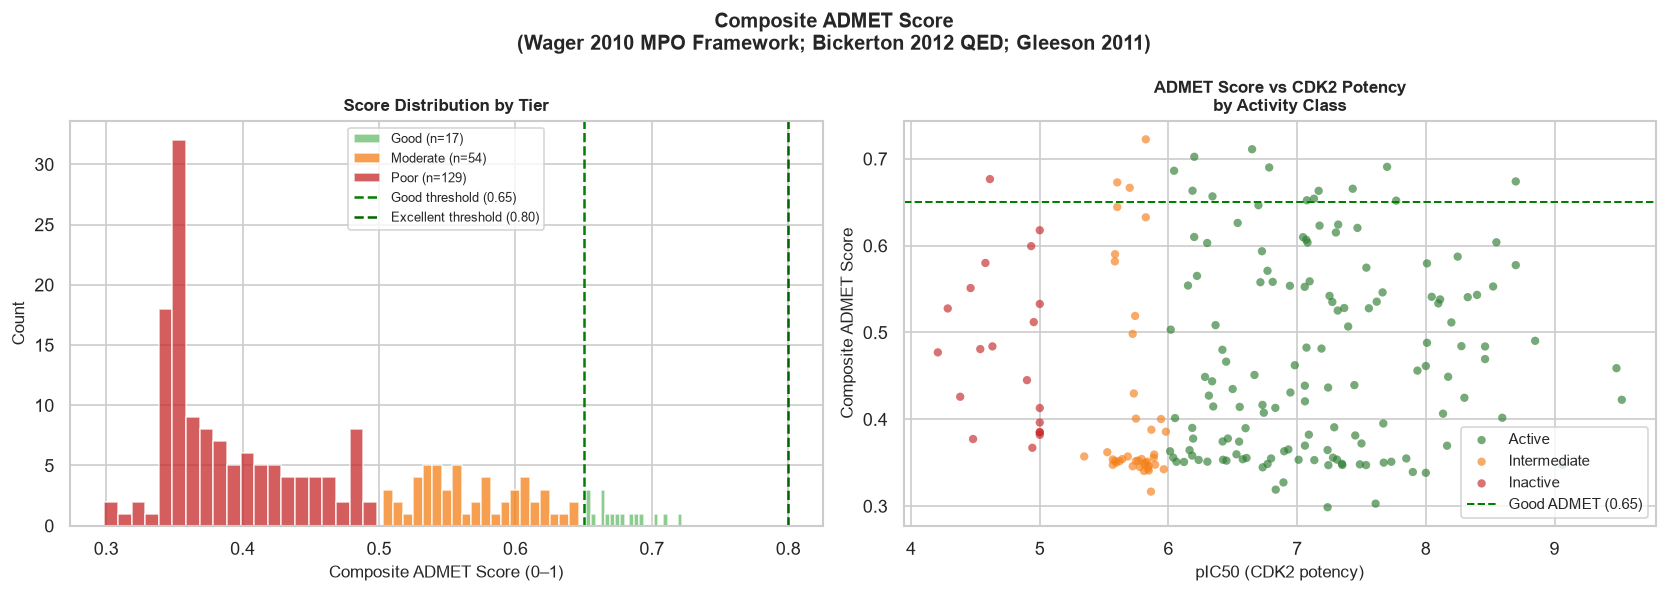

[SAVED] admet_composite_score.png


In [16]:
# ============================================================
# CELL 13 — Composite ADMET Score and Compound Ranking
# Weighted desirability-function scoring following the MPO
# framework of Wager et al. (2010) and QED concept (Bickerton 2012).
# All imports already loaded in Cell 0.
# References:
# - Wager TT et al. (2010) ACS Chem Neurosci 1(6):435-449
# - Bickerton GR et al. (2012) Nat Chem 4(2):90-98
# - Gleeson MP et al. (2011) J Med Chem 54(15):5516-5523
# ============================================================

# ── Activity colour palette (redefined locally for cell independence) ─────────
act_colors = {
    'Active':       PALETTE['safe'],
    'Intermediate': PALETTE['moderate'],
    'Inactive':     PALETTE['risk']
}

# ── Case-insensitive column resolver ─────────────────────────────────────────
_col_map_score = {c.lower(): c for c in df_admet.columns}

def _safe_col_score(name):
    """Return actual df_admet column name (case-insensitive), or None."""
    return _col_map_score.get(name.lower(), None)

# ── Resolve all endpoint columns before building weights ─────────────────────
# All column names resolved here — no hardcoded strings used in scoring loop.
herg_col  = _safe_col_score('hERG')
ames_col  = _safe_col_score('AMES')
dili_col  = _safe_col_score('DILI')
clintox_col = _safe_col_score('ClinTox')
hia_col   = _safe_col_score('HIA_Hou')
bioa_col  = _safe_col_score('Bioavailability_Ma')
caco2_col = _safe_col_score('Caco2_Wang')
lip_col   = _safe_col_score('Lipinski')
qed_col   = _safe_col_score('QED')

# PAINS_COL and BRENK_COL resolved in Cell 4 (fallback in Cell 12)
pains_col = PAINS_COL if PAINS_COL in df_admet.columns else None
brenk_col = BRENK_COL if BRENK_COL in df_admet.columns else None

# Report any missing columns
for name, actual in [
    ('hERG', herg_col), ('AMES', ames_col), ('DILI', dili_col),
    ('ClinTox', clintox_col), ('HIA_Hou', hia_col),
    ('Bioavailability_Ma', bioa_col), ('Caco2_Wang', caco2_col),
    ('Lipinski', lip_col), ('QED', qed_col),
    ('PAINS', pains_col), ('BRENK', brenk_col),
]:
    if actual is None:
        print(f'  [WARN] Column "{name}" not found — contribution set to 0.')

# ── Desirability functions ────────────────────────────────────────────────────
# Three desirability functions map raw predicted values onto [0, 1]:
# desr_low : lower probability = more desirable (safety endpoints)
# desr_high: higher probability = more desirable (PK/absorption endpoints)
# desr_cont: linear ramp for continuous endpoints (Caco-2, QED)
#
# All functions are clamped to [0, 1] — composite score is guaranteed in [0, 1].

def desr_low(val, thresh=0.5):
    """Low probability = desirable. Used for safety endpoints (hERG, AMES, DILI)."""
    return float(1 - min(max(float(val) / thresh, 0), 1))

def desr_high(val, thresh=0.5):
    """High probability = desirable. Used for PK endpoints (HIA, Bioavailability)."""
    return float(min(max(float(val) / thresh, 0), 1))

def desr_cont(val, low, high, higher_better=True):
    """Linear ramp for continuous endpoints. Range [low, high] mapped to [0, 1]."""
    if higher_better:
        return float(min(max((float(val) - low) / (high - low), 0), 1))
    return float(min(max((high - float(val)) / (high - low), 0), 1))

# ── Weighting scheme ──────────────────────────────────────────────────────────
# Weights reflect the relative importance of each ADMET domain in drug development.
# Toxicity endpoints dominate (60%) because toxic liabilities are the primary
# cause of clinical trial failure (Wager 2010; Gleeson 2011).
# Weights sum to exactly 1.0 — verified by assertion below.
weights = {}
if herg_col:    weights[herg_col]    = 0.15
if ames_col:    weights[ames_col]    = 0.15
if dili_col:    weights[dili_col]    = 0.15
if clintox_col: weights[clintox_col] = 0.15
if hia_col:     weights[hia_col]     = 0.08
if bioa_col:    weights[bioa_col]    = 0.08
if caco2_col:   weights[caco2_col]   = 0.08
if lip_col:     weights[lip_col]     = 0.05
if qed_col:     weights[qed_col]     = 0.05
if pains_col:   weights[pains_col]   = 0.03
if brenk_col:   weights[brenk_col]   = 0.03

total_weight = sum(weights.values())
print(f'  Composite score weight total : {total_weight:.4f}')
assert abs(total_weight - 1.0) < 0.001, \
    f'Weights must sum to 1.0 — got {total_weight:.4f}. Check for missing columns.'
print('  [OK] Weights sum to 1.0')

# ── Compute composite score ───────────────────────────────────────────────────
# Each endpoint contribution = weight × desirability(predicted_value).
# Missing values default to 0.5 (midpoint = uncertain) via row.get().
# Caco-2 uses continuous desirability: range [-8, -4] log cm/s.
# QED used directly (already in [0, 1] by definition).
scores = []
for _, row in df_admet.iterrows():
    s = 0.0
    # Toxicity endpoints (desr_low: lower probability = safer = better)
    if herg_col:    s += weights[herg_col]    * desr_low(row.get(herg_col,    0.5))
    if ames_col:    s += weights[ames_col]    * desr_low(row.get(ames_col,    0.5))
    if dili_col:    s += weights[dili_col]    * desr_low(row.get(dili_col,    0.5))
    if clintox_col: s += weights[clintox_col] * desr_low(row.get(clintox_col, 0.5))
    # Absorption endpoints (desr_high: higher probability = better absorption)
    if hia_col:     s += weights[hia_col]     * desr_high(row.get(hia_col,    0.5))
    if bioa_col:    s += weights[bioa_col]    * desr_high(row.get(bioa_col,   0.5))
    # Caco-2 continuous: range [-8, -4] log cm/s; higher = better permeability
    if caco2_col:   s += weights[caco2_col]   * desr_cont(row.get(caco2_col,  -6.0), -8, -4, True)
    # Drug-likeness
    if lip_col:     s += weights[lip_col]     * desr_high(row.get(lip_col,    0.5))
    if qed_col:     s += weights[qed_col]     * float(row.get(qed_col,        0.5))
    # Structural alerts (desr_low: lower probability = cleaner structure)
    if pains_col:   s += weights[pains_col]   * desr_low(row.get(pains_col,   0.5))
    if brenk_col:   s += weights[brenk_col]   * desr_low(row.get(brenk_col,   0.5))
    scores.append(round(s, 4))

df_admet['ADMET_score'] = scores

# Verify score range is [0, 1]
assert df_admet['ADMET_score'].min() >= 0.0, 'ADMET score below 0 — check desirability functions'
assert df_admet['ADMET_score'].max() <= 1.0, 'ADMET score above 1 — check desirability functions'
print(f'  [OK] Score range: [{df_admet["ADMET_score"].min():.4f}, '
      f'{df_admet["ADMET_score"].max():.4f}] — confirmed within [0, 1]')

# ── Tier classification ───────────────────────────────────────────────────────
df_admet['ADMET_tier'] = df_admet['ADMET_score'].apply(
    lambda s: 'Excellent' if s >= 0.80 else
              'Good'      if s >= 0.65 else
              'Moderate'  if s >= 0.50 else 'Poor'
)

# ── Summary statistics ────────────────────────────────────────────────────────
sc = df_admet['ADMET_score']
print()
print('Composite ADMET Score Distribution')
print('=' * 50)
print(f'  Mean   : {sc.mean():.4f}')
print(f'  Median : {sc.median():.4f}')
print(f'  Std    : {sc.std():.4f}')
print(f'  Range  : [{sc.min():.4f}, {sc.max():.4f}]')
print()
for tier in ['Excellent', 'Good', 'Moderate', 'Poor']:
    n = (df_admet['ADMET_tier'] == tier).sum()
    print(f'  {tier:<12}: {n:>4} ({100*n/len(df_admet):.1f}%)')

# Top 10 — use only columns confirmed to exist in df_admet
top10_cols = ['chembl_id', 'pIC50', 'activity', 'ADMET_score', 'ADMET_tier']
# Add MW and logP only if they exist in df_admet (they may be in df but not df_admet)
for extra_col in ['MW', 'logP']:
    if extra_col in df_admet.columns:
        top10_cols.insert(3, extra_col)

print('\nTop 10 compounds by composite ADMET score:')
print(df_admet.nlargest(10, 'ADMET_score')[top10_cols].to_string(index=False))

# ── Two-panel figure ──────────────────────────────────────────────────────────
tier_colors = {
    'Excellent': '#2E7D32',
    'Good':      '#66BB6A',
    'Moderate':  '#F57F17',
    'Poor':      '#C62828'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Composite ADMET Score\n'
    '(Wager 2010 MPO Framework; Bickerton 2012 QED; Gleeson 2011)',
    fontsize=12, fontweight='bold'
)

# Panel 1: Score distribution by tier
for tier, color in tier_colors.items():
    sub = df_admet[df_admet['ADMET_tier'] == tier]['ADMET_score']
    if len(sub) > 0:
        axes[0].hist(sub, bins=20, alpha=0.75, color=color,
                     label=f'{tier} (n={len(sub)})', edgecolor='white')
axes[0].axvline(0.65, color='green',     linestyle='--', lw=1.5, label='Good threshold (0.65)')
axes[0].axvline(0.80, color='darkgreen', linestyle='--', lw=1.5, label='Excellent threshold (0.80)')
axes[0].set_xlabel('Composite ADMET Score (0–1)', fontsize=10)
axes[0].set_ylabel('Count', fontsize=10)
axes[0].set_title('Score Distribution by Tier', fontsize=10)
axes[0].legend(fontsize=8)

# Panel 2: ADMET score vs potency scatter
for cls, clr in act_colors.items():
    sub = df_admet[df_admet['activity'] == cls]
    axes[1].scatter(
        sub['pIC50'], sub['ADMET_score'],
        c=clr, label=cls, alpha=0.65, s=25, edgecolors='none'
    )
axes[1].axhline(0.65, color='green', linestyle='--', lw=1.2, label='Good ADMET (0.65)')
axes[1].set_xlabel('pIC50 (CDK2 potency)', fontsize=10)
axes[1].set_ylabel('Composite ADMET Score', fontsize=10)
axes[1].set_title('ADMET Score vs CDK2 Potency\nby Activity Class', fontsize=10)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('admet_composite_score.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] admet_composite_score.png')

## Cell 14 — 2D Structure Grid: Top Compounds by Composite ADMET Score

The CDK2 inhibitors with the highest composite ADMET scores are rendered as a 2D
structure grid. Each structure is annotated with its ChEMBL ID, pIC50 (CDK2 potency),
composite ADMET score, hERG inhibition probability, and activity class.

**Why Cairo-free SVG rendering?** RDKit's standard `MolToImage()` and `MolsToGridImage()`
functions require the Cairo graphics library to be compiled into RDKit at build time.
This is not guaranteed across all platforms and conda environments, and raises a
`RuntimeError` when Cairo is absent. `MolDraw2DSVG` is Cairo-free and produces
publication-quality SVG output on all platforms (Windows, macOS, Linux) with no
additional dependencies — consistent with the single-command reproducible installation
goal of this tutorial.

**Stereo annotation** is enabled (`addStereoAnnotation = True`) so that chiral centres
are explicitly marked in the rendered structures, which is important for CDK2 inhibitors
where stereochemistry significantly affects binding affinity.

**Structure interpretation guidance:** Compounds with high composite ADMET scores and
high pIC50 values represent the best candidates for further development — high potency
combined with clean ADMET profiles. The hERG annotation allows rapid identification of
compounds where cardiac safety may require experimental follow-up despite good overall
scores.

**Reference:** Landrum G & Riniker S (2024) *J Chem Inf Model* 64(5):1560–1567

  [OK] mol column already present in df_admet
  Compounds selected for structure grid: 12
[SAVED] 12 top ADMET structures → admet_top_structures.svg


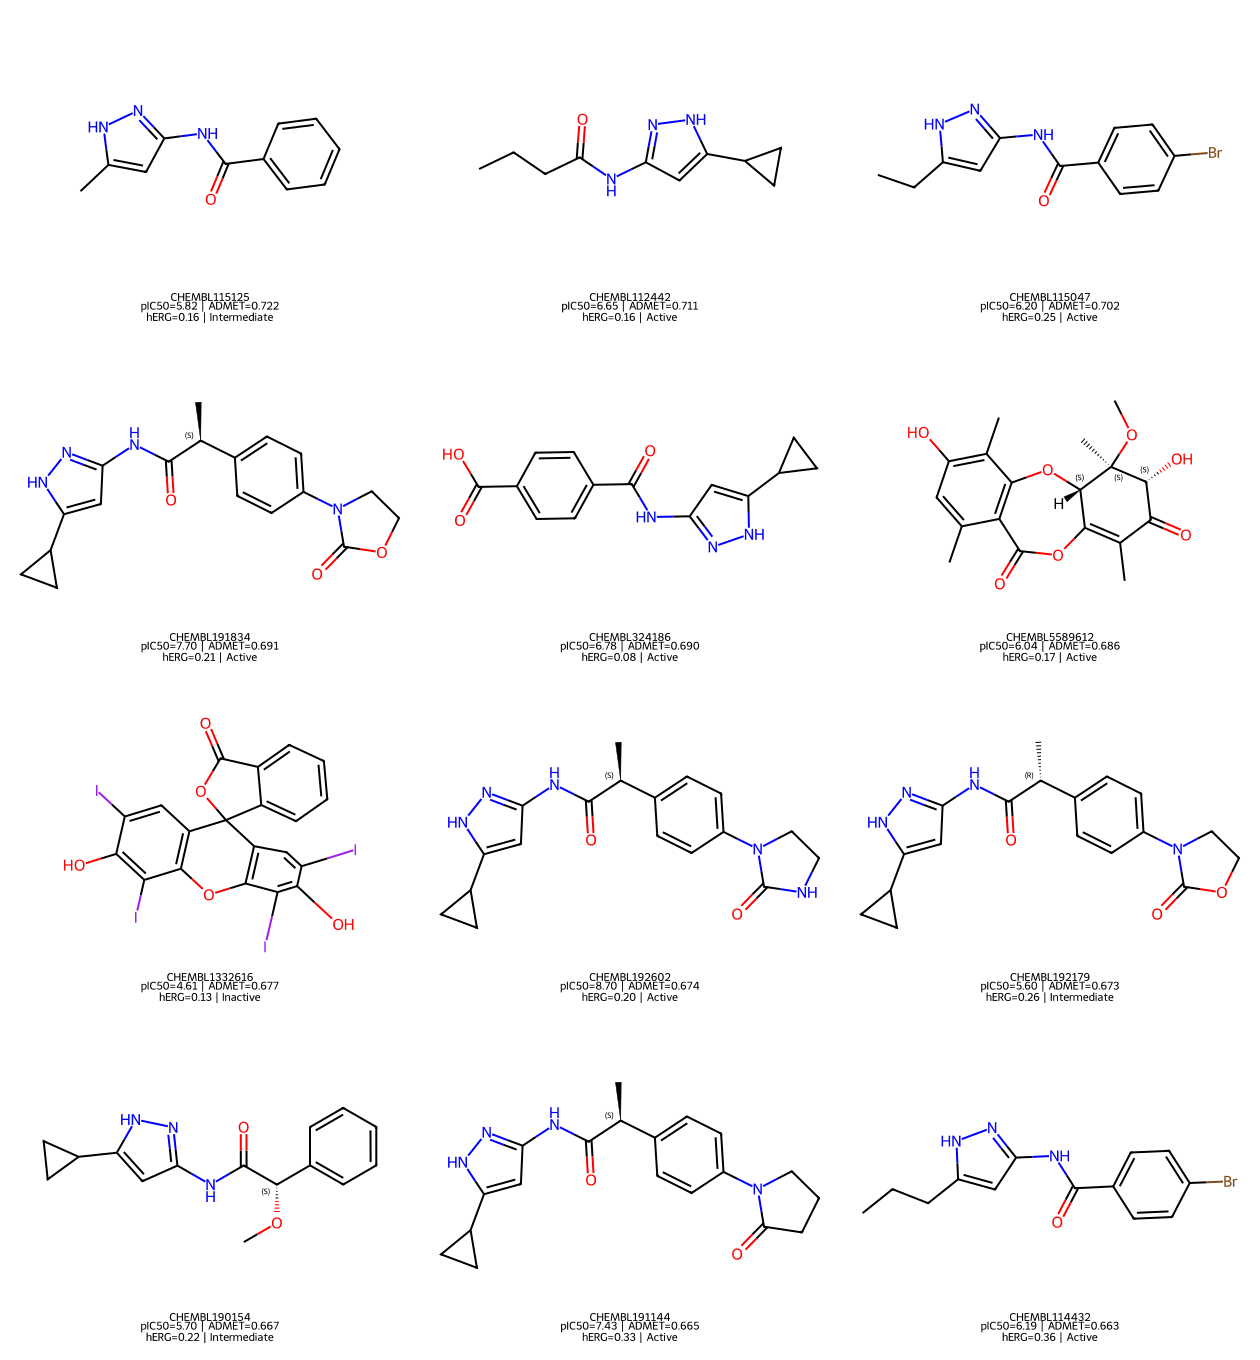

In [17]:
# ============================================================
# CELL 14 — 2D Structure Grid: Top Compounds by ADMET Score
# Renders top-scoring CDK2 inhibitors using RDKit's Cairo-free
# SVG renderer (MolDraw2DSVG) to ensure cross-platform compatibility.
# All imports already loaded in Cell 0.
# Reference: Landrum G & Riniker S (2024) J Chem Inf Model 64(5):1560-1567
# ============================================================

# ── Merge mol objects from df into df_admet ───────────────────────────────────
# mol objects (RDKit Mol) were created in Cell 1 and stored in df.
# df_admet was built from ADMET-AI predictions and may not have mol column.
# We merge using chembl_id as the key — safe even if df_admet already has mol.
if 'mol' not in df_admet.columns:
    mol_map = dict(zip(df['chembl_id'], df['mol']))
    df_admet['mol'] = df_admet['chembl_id'].map(mol_map)
    print(f'  [OK] mol column merged from Cell 1 df into df_admet')
else:
    print(f'  [OK] mol column already present in df_admet')

# ── Resolve hERG column name ──────────────────────────────────────────────────
_col_map_struct = {c.lower(): c for c in df_admet.columns}
herg_col_s = _col_map_struct.get('herg', None)
if herg_col_s is None:
    print('  [WARN] hERG column not found — hERG label will show N/A')

# ── Select top compounds by ADMET score ──────────────────────────────────────
# Filter to compounds with valid mol objects before selecting top N.
# If fewer than 12 valid mols exist the grid adjusts automatically.
N_DISPLAY = 12

top_compounds = (df_admet[df_admet['mol'].notna()]
                 .nlargest(N_DISPLAY, 'ADMET_score')
                 .copy()
                 .reset_index(drop=True))

n_actual = len(top_compounds)
print(f'  Compounds selected for structure grid: {n_actual}')
if n_actual < N_DISPLAY:
    print(f'  [NOTE] Fewer than {N_DISPLAY} valid mol objects — grid shows {n_actual} compounds.')

# ── Build annotation labels ───────────────────────────────────────────────────
# Each label shows: ChEMBL ID, pIC50, composite ADMET score, hERG probability, activity class.
# hERG label uses resolved column name — no hardcoded strings.
labels = []
for _, row in top_compounds.iterrows():
    if herg_col_s and not pd.isna(row.get(herg_col_s)):
        herg_str = f"{row[herg_col_s]:.2f}"
    else:
        herg_str = 'N/A'
    labels.append(
        f"{row['chembl_id']}\n"
        f"pIC50={row['pIC50']:.2f} | ADMET={row['ADMET_score']:.3f}\n"
        f"hERG={herg_str} | {row['activity']}"
    )

# ── Prepare mol objects for drawing ──────────────────────────────────────────
# PrepareMolForDrawing adds 2D coordinates and kekulises aromatic bonds.
# Wrapped in try/except — if preparation fails the original mol is used.
mols_draw = []
for mol in top_compounds['mol'].tolist():
    try:
        m = Chem.RWMol(mol)
        rdd.PrepareMolForDrawing(m)
        mols_draw.append(m)
    except Exception as e:
        print(f'  [WARN] PrepareMolForDrawing failed: {e} — using original mol')
        mols_draw.append(mol)

# ── Render SVG grid using Cairo-free MolDraw2DSVG ────────────────────────────
# MolDraw2DSVG avoids the RuntimeError from MolToImage/MolsToGridImage which
# require Cairo support compiled into RDKit. SVG rendering works on all platforms.
# Grid dimensions calculated dynamically from actual compound count.
n_cols = 3
n_rows = (n_actual + n_cols - 1) // n_cols
w, h   = 420, 340  # pixels per cell

canvas = rdd.MolDraw2DSVG(n_cols * w, n_rows * h, w, h)
canvas.drawOptions().addStereoAnnotation = True
canvas.DrawMolecules(mols_draw, legends=labels)
canvas.FinishDrawing()
svg_str = canvas.GetDrawingText()

# ── Save and display ──────────────────────────────────────────────────────────
svg_path = 'admet_top_structures.svg'
with open(svg_path, 'w', encoding='utf-8') as f:
    f.write(svg_str)

print(f'[SAVED] {n_actual} top ADMET structures → {svg_path}')
display(SVG(svg_str))

## Cell 15 — Integrated ADMET Report Export

This cell exports the complete ADMET profiling results as a single comprehensive CSV file
following FAIR data principles (Wilkinson et al. 2016). The report combines all 200 CDK2
inhibitors with their complete ADMET profiles across all endpoints, traffic light flags,
and composite scores.

### Report structure

The exported CSV (`cdk2_integrated_admet_report.csv`) contains the following column groups
in order:

| Column group | Source | n columns |
|---|---|---|
| Identifiers | ChEMBL 35 | chembl_id, smiles, IC50_nM, pIC50, activity |
| RDKit descriptors | RDKit (Cell 1) | MW, logP, HBD, HBA, TPSA, HAC, RotBonds, Fsp3 |
| ADMET-AI predictions | ADMET-AI 2.0.1 (Cell 2) | 52 raw endpoints |
| DrugBank percentiles | ADMET-AI 2.0.1 (Cell 2) | 52 percentile rankings |
| Traffic light flags | Cell 12 | green_count (0–13) |
| Composite score | Cell 13 | ADMET_score (0–1), ADMET_tier |

**Total: approximately 117 columns per compound.**

### Note on default values in the report

The composite score calculation in Cell 13 uses `.get()` with default values when a
predicted value is missing. The default is 0.5 for binary endpoints (representing
uncertainty at the midpoint of the probability scale) and −6.0 for Caco-2
(`Caco2_Wang`) specifically — because Caco-2 is a continuous endpoint measured in
log cm/s with expected range [−8, −4], and using 0.5 would be dimensionally incorrect
for a non-probability endpoint. If many cells in the report show these default values,
check that your admet-ai version matches environment.yml (==2.0.1).

### FAIR compliance

- **Findable:** GitHub repository with permanent Zenodo DOI
- **Accessible:** MIT license, no registration required, all data included
- **Interoperable:** Standard CSV format with ChEMBL IDs (cross-database identifier)
  and SMILES strings (universal molecular representation)
- **Reusable:** Pinned environment.yml ensures exact software reproduction;
  standalone `data/cdk2_inhibitors_200.csv` separates data from code;
  complete inline documentation throughout the notebook

**Reference:** Wilkinson MD et al. (2016) *Sci Data* 3:160018

In [18]:
# ============================================================
# CELL 15 — Integrated ADMET Report Export
# Exports a comprehensive CSV combining all ADMET-AI predictions,
# RDKit descriptors, traffic light flags, and composite scores.
# All imports already loaded in Cell 0.
# Reference: Wilkinson MD et al. (2016) Sci Data 3:160018
#            doi:10.1038/sdata.2016.18
# ============================================================

# ── Guard: tl_df must be defined by Cell 12 ──────────────────────────────────
if 'tl_df' not in dir():
    raise RuntimeError(
        "tl_df is not defined. Please run Cell 12 (Traffic Light Dashboard) "
        "before running Cell 15."
    )

# ── Guard: RAW_COLS and PCT_COLS must be defined by Cell 2 ───────────────────
if 'RAW_COLS' not in dir() or 'PCT_COLS' not in dir():
    raise RuntimeError(
        "RAW_COLS or PCT_COLS not defined. Please run Cell 2 "
        "(ADMET-AI Prediction Pipeline) before running Cell 15."
    )

# ── Merge RDKit descriptor columns from df into df_admet ─────────────────────
# MW, logP, HBD, HBA, TPSA, HAC, RotBonds, Fsp3 were computed in Cell 1
# and stored in df. They may not be in df_admet — merge using chembl_id.
rdkit_desc_cols = ['chembl_id', 'smiles', 'IC50_nM',
                   'MW', 'logP', 'HBD', 'HBA',
                   'TPSA', 'HAC', 'RotBonds', 'Fsp3']
rdkit_avail = [c for c in rdkit_desc_cols if c in df.columns]
rdkit_merge = df[rdkit_avail].drop_duplicates(subset='chembl_id')

# Drop any RDKit columns already in df_admet to avoid duplicate suffixes
cols_to_drop = [c for c in rdkit_avail if c != 'chembl_id' and c in df_admet.columns]
df_admet_clean = df_admet.drop(columns=cols_to_drop, errors='ignore')

# Merge RDKit descriptors
df_with_rdkit = df_admet_clean.merge(rdkit_merge, on='chembl_id', how='left')

# ── Merge traffic light green_count ──────────────────────────────────────────
# Drop existing green_count if present to avoid stale values from previous runs
df_with_rdkit = df_with_rdkit.drop(columns=['green_count'], errors='ignore')
tl_merge = tl_df[['chembl_id', 'green_count']].copy()
final = df_with_rdkit.merge(tl_merge, on='chembl_id', how='left')

# ── Select and order report columns ──────────────────────────────────────────
# Column order: identifiers → RDKit descriptors → ADMET predictions →
#               percentile rankings → traffic light → composite score
base_cols = [
    'chembl_id', 'smiles', 'IC50_nM', 'pIC50', 'activity',
    'MW', 'logP', 'HBD', 'HBA', 'TPSA', 'HAC', 'RotBonds', 'Fsp3'
]
score_cols = ['green_count', 'ADMET_score', 'ADMET_tier']
all_cols   = base_cols + RAW_COLS + PCT_COLS + score_cols

# Keep only columns that actually exist in final — warn about missing ones
avail = [c for c in all_cols if c in final.columns]
missing_report_cols = [c for c in base_cols + score_cols if c not in final.columns]
if missing_report_cols:
    print(f'  [WARN] Missing from report: {missing_report_cols}')

report = (final[avail]
          .drop_duplicates(subset='chembl_id')
          .sort_values('ADMET_score', ascending=False)
          .reset_index(drop=True))

# ── Export CSV ────────────────────────────────────────────────────────────────
# NOTE on default values: .get() with defaults was used in Cell 13 scoring.
# Default = 0.5 for binary endpoints (uncertain midpoint).
# Default = -6.0 for Caco2_Wang (midpoint of continuous range [-8, -4] log cm/s).
# Using 0.5 for Caco-2 would be dimensionally incorrect as it is not a probability.
# Compounds showing many default values in the report indicate missing ADMET-AI
# output columns — check admet-ai version against environment.yml (==2.0.1).
output_csv = 'cdk2_integrated_admet_report.csv'
report.to_csv(output_csv, index=False)
print(f'[SAVED] {output_csv}')

# ── Final summary ─────────────────────────────────────────────────────────────
print()
print('=' * 65)
print('  TUTORIAL 4: CDK2 ADMET PROFILING — Final Summary')
print('=' * 65)
print(f'  Target                     : CDK2 (CHEMBL301, Homo sapiens)')
print(f'  Compounds profiled         : {len(report)}')
print(f'  ADMET-AI version           : {admet_ai.__version__}')
print(f'  RDKit version              : {rdBase.rdkitVersion}')
print(f'  Endpoints predicted        : {len(RAW_COLS)} raw + {len(PCT_COLS)} percentile = {len(RAW_COLS)+len(PCT_COLS)}')
print(f'  Report columns total       : {len(avail)}')
print(f'  Active (pIC50 >= 6.0)      : {(report["pIC50"]>=6.0).sum()}')
print()
for tier in ['Excellent', 'Good', 'Moderate', 'Poor']:
    n = (report['ADMET_tier'] == tier).sum()
    print(f'  ADMET {tier:<12}: {n:>4} ({100*n/len(report):.1f}%)')
print()
print(f'  Mean ADMET score           : {report["ADMET_score"].mean():.4f}')
print(f'  Mean green flags           : {report["green_count"].mean():.1f}/13')
print()

# ── FAIR data statement ───────────────────────────────────────────────────────
# Zenodo DOI provides permanent, citable access to all outputs.
# Update the DOI below with the actual Zenodo record DOI before submission.
ZENODO_DOI = '10.5281/zenodo.20435115'  # UPDATE with actual DOI before submission
print('FAIR Data Compliance:')
print(f'  Findable    : GitHub repository + Zenodo DOI {ZENODO_DOI}')
print(f'  Accessible  : MIT license, open access, no registration required')
print(f'  Interoperable: CSV with ChEMBL IDs and SMILES (standard formats)')
print(f'  Reusable    : Pinned environment.yml, standalone CSV dataset,')
print(f'                complete inline documentation')
print()

# ── Output file manifest ──────────────────────────────────────────────────────
# All filenames must match exactly what was saved in earlier cells.
output_files = [
    ('cdk2_admet_raw_predictions.csv',      'Cell 2  — Raw ADMET-AI predictions'),
    ('admet_training_overlap_analysis.png', 'Cell 2B — Training data overlap'),
    ('admet_physicochemical_01.png',        'Cell 3  — Physicochemical profiles'),
    ('admet_structural_alerts.png',         'Cell 4  — Drug-likeness and alerts'),
    ('admet_absorption.png',                'Cell 5  — Absorption profiles'),
    ('admet_distribution.png',              'Cell 6  — Distribution profiles'),
    ('admet_cyp450_metabolism.png',         'Cell 7  — CYP450 metabolism'),
    ('admet_excretion.png',                 'Cell 8  — Excretion profiles'),
    ('admet_toxicity.png',                  'Cell 9  — Toxicity profiles'),
    ('admet_tox21.png',                     'Cell 10 — Tox21 pathway profiles'),
    ('admet_drugbank_percentiles.png',      'Cell 11 — DrugBank percentiles'),
    ('admet_traffic_light.png',             'Cell 12 — Traffic light dashboard'),
    ('admet_composite_score.png',           'Cell 13 — Composite ADMET scores'),
    ('admet_top_structures.svg',            'Cell 14 — Top compound structures'),
    ('cdk2_integrated_admet_report.csv',    'Cell 15 — Integrated report (this cell)'),
]

print('Output file manifest:')
import os
for fname, description in output_files:
    exists = '[FILE]  ' if os.path.exists(fname) else '[MISSING]'
    print(f'  {exists} {fname:<45} {description}')

print()
print('[DONE] Tutorial 4 complete.')
print('       All outputs are ready for upload to GitHub and Zenodo.')
print(f'       Cite as: Festus O. Ogungbemiro, Jane O. Anebi, Felix O. Okunlola, Love A. Onyekwere and Evna M. M. Pereira (2025)')
print(f'       Journal of Cheminformatics. doi:{ZENODO_DOI}')

[SAVED] cdk2_integrated_admet_report.csv

  TUTORIAL 4: CDK2 ADMET PROFILING — Final Summary
  Target                     : CDK2 (CHEMBL301, Homo sapiens)
  Compounds profiled         : 200
  ADMET-AI version           : 2.0.1
  RDKit version              : 2026.03.3
  Endpoints predicted        : 52 raw + 52 percentile = 104
  Report columns total       : 119
  Active (pIC50 >= 6.0)      : 140

  ADMET Excellent   :    0 (0.0%)
  ADMET Good        :   17 (8.5%)
  ADMET Moderate    :   54 (27.0%)
  ADMET Poor        :  129 (64.5%)

  Mean ADMET score           : 0.4604
  Mean green flags           : 9.5/13

FAIR Data Compliance:
  Findable    : GitHub repository + Zenodo DOI 10.5281/zenodo.20435115
  Accessible  : MIT license, open access, no registration required
  Interoperable: CSV with ChEMBL IDs and SMILES (standard formats)
  Reusable    : Pinned environment.yml, standalone CSV dataset,
                complete inline documentation

Output file manifest:
  [FILE]   cdk2_admet_raw